# SeQUeNCe Multi-Pair Quantum Route-Feasibility Dataset Generator

This notebook builds a reproducible simulation dataset for **quantum-network route-feasibility prediction** and **best-route selection** using classical machine learning and quantum machine learning.

The workflow uses an asymmetric eight-router quantum network, four source–destination endpoint pairs, four candidate routes per pair, controlled operating scenarios, and repeated stochastic simulations. It produces rollout-level telemetry, route-level labels, oracle best-route labels, and leakage-safe model-ready training and validation files.

## Research objective

For each candidate route, the simulation asks:

> Under the current optical, hardware, timing, degradation, and memory-pressure conditions, is this route likely to establish qualifying end-to-end entanglement?

The generated data support two downstream tasks:

- **Binary route-feasibility classification:** predict `feasible_label`.
- **Route ranking:** identify the best candidate route within each scenario and endpoint pair.

## Simulation design

| Component | Configuration |
|---|---|
| Simulator | SeQUeNCe 0.8.5 |
| Quantum formalism | Ket-vector |
| Entanglement generation | Barrett–Kok |
| BSM hardware | `SingleAtomBSM` |
| Quantum routers | 8 |
| Endpoint pairs | 4 |
| Candidate routes per pair | 4 |
| Training-topology scenarios | 75 |
| Rollouts per route | 5 |
| Total simulations | 6,000 |
| Route-level records | 1,200 |
| Feasibility threshold | 0.60 |

## Main outputs

The notebook saves the following research artifacts to Google Drive:

- topology and route configuration files;
- scenario and route manifests;
- 6,000 rollout-level simulation records;
- 1,200 aggregated route-level records;
- 300 scenario–endpoint-pair oracle labels;
- model-ready training and validation datasets;
- figures, quality audits, reproducibility metadata, and SHA-256 file hashes.

## Execution guidance

Run the notebook from top to bottom.

1. Execute the environment installation section in a fresh Colab runtime.
2. Restart the runtime when the installation section requests it.
3. Run the environment verification and configuration sections.
4. Complete the structural smoke test before starting the long simulation batch.
5. Keep checkpoint reset disabled once the batch begins.
6. Use the generated training and validation files for model development; reserve the separately generated unseen-topology dataset for final testing.

> **Computing note:** SeQUeNCe is primarily CPU-bound in this workflow. A GPU runtime is not required for dataset generation.


## Install the reproducible Colab environment

**Purpose:** install the exact package versions required by the simulation pipeline.

This section removes potentially incompatible preinstalled packages and installs pinned versions of NumPy, SciPy, pandas, Matplotlib, NetworkX, scikit-learn, SeQUeNCe, and related dependencies.

**Why it matters:** pinning the software stack reduces version-dependent simulation differences and makes the repository easier to reproduce.

**Action after execution:** restart the Colab runtime before continuing.


In [ ]:
!pip uninstall -y sequence qutip qutip-qip numpy scipy pandas matplotlib networkx scikit-learn >/dev/null 2>&1

!pip install -q --no-cache-dir \
    "numpy==2.0.2" \
    "scipy==1.14.1" \
    "pandas==2.2.2" \
    "matplotlib==3.9.2" \
    "networkx==3.3" \
    "scikit-learn==1.5.2"

!pip install -q --no-cache-dir \
    "qutip==5.0.4" \
    "qutip-qip==0.3.3"

!pip install -q --no-cache-dir sequence

print("Installation finished. Now restart runtime one more time before importing SeQUeNCe.")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.9/60.9 kB 4.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.8/60.8 kB 270.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.2/19.2 MB 267.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.8/40.8 MB 241.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.7/12.7 MB 254.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 206.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 319.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 209.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
hdbscan 0.8.44 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.
umap-learn 0.5.12 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is inc

## Mount persistent storage and verify the simulation stack

**Purpose:** connect Google Drive, import the required Python and SeQUeNCe modules, and confirm that the expected simulator version is available.

The checks verify:

- Python and operating-system information;
- the installed SeQUeNCe version and import location;
- access to the timeline, topology, routing, reservation, and entanglement-management modules;
- the availability of the quantum-state formalism used later in the notebook.

**Output:** an environment report confirming that the runtime is ready.


In [ ]:
from __future__ import annotations

import copy
import json
import platform
import sys
import traceback
from importlib.metadata import version
from itertools import combinations, islice
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

from google.colab import drive

from sequence.app.request_app import RequestApp
from sequence.constants import (
    BARRET_KOK,
    KET_STATE_FORMALISM,
    MILLISECOND,
    SECOND,
    SPEED_OF_LIGHT,
)
from sequence.entanglement_management.generation import (
    EntanglementGenerationA,
    EntanglementGenerationB,
)
from sequence.network_management.reservation import Reservation
from sequence.topology.router_net_topo import RouterNetTopo

drive.mount("/content/drive", force_remount=False)

SEQUENCE_VERSION = version("sequence")
assert SEQUENCE_VERSION == "0.8.5", (
    f"This notebook was prepared for SeQUeNCe 0.8.5, "
    f"but version {SEQUENCE_VERSION} is installed."
)

print("=" * 72)
print("ENVIRONMENT CHECK")
print("=" * 72)
print(f"Python      : {sys.version.split()[0]}")
print(f"Platform    : {platform.platform()}")
print(f"SeQUeNCe    : {SEQUENCE_VERSION}")
print(f"NetworkX    : {nx.__version__}")
print(f"Pandas      : {pd.__version__}")
print("=" * 72)


Mounted at /content/drive
ENVIRONMENT CHECK
Python      : 3.12.13
Platform    : Linux-6.6.122+-x86_64-with-glibc2.35
SeQUeNCe    : 0.8.5
NetworkX    : 3.6.1
Pandas      : 3.0.3


## Configure the experiment and output directory structure

**Purpose:** define all high-level controls for the training-topology experiment.

This section specifies:

- dataset name and version;
- Google Drive project directory;
- master random seed;
- four endpoint pairs;
- four candidate routes per endpoint pair;
- 75 network scenarios;
- five stochastic rollouts per route;
- the route-feasibility threshold;
- checkpoint, reset, and resume behavior;
- paths for raw, processed, manifest, figure, and audit files.

**Expected scale:** `75 × 4 × 4 × 5 = 6,000` simulations.

**Important:** use the reset option only for a deliberate clean restart. Disable it before launching or resuming the long batch.


In [ ]:
# ============================================================
# TOP-QUALITY TRAINING DATASET CONTROLS
# ============================================================

from pathlib import Path


# ------------------------------------------------------------
# 1. Experiment mode
# ------------------------------------------------------------

FAST_MODE = False

DATASET_NAME = (
    "sequence_8node_multi_pair_training"
)

DATASET_VERSION = "v2_top_quality"


# ------------------------------------------------------------
# 2. Keep the existing project path
# ------------------------------------------------------------

PROJECT_ROOT = Path(
    "/content/drive/MyDrive/quantum_route_dataset"
)


# ------------------------------------------------------------
# 3. Reproducibility
# ------------------------------------------------------------

MASTER_SEED = 42


# ------------------------------------------------------------
# 4. Source-destination endpoint pairs
# ------------------------------------------------------------
#
# The previous dataset used only:
#     R0 -> R7
#
# This improved dataset uses four endpoint pairs.
# Every pair will have four candidate routes.

ENDPOINT_PAIRS = [
    {
        "pair_id": "pair_01",
        "source": "R0",
        "destination": "R7",
    },
    {
        "pair_id": "pair_02",
        "source": "R0",
        "destination": "R6",
    },
    {
        "pair_id": "pair_03",
        "source": "R1",
        "destination": "R7",
    },
    {
        "pair_id": "pair_04",
        "source": "R2",
        "destination": "R7",
    },
]

N_ENDPOINT_PAIRS = len(
    ENDPOINT_PAIRS
)


# ------------------------------------------------------------
# 5. Backward-compatible default endpoint
# ------------------------------------------------------------
#
# Keep these variables temporarily because some older cells
# may still use SOURCE_ROUTER and DESTINATION_ROUTER.
#
# Updated multi-pair cells should use source and destination
# from each route_record instead.

SOURCE_ROUTER = "R0"
DESTINATION_ROUTER = "R7"


# ------------------------------------------------------------
# 6. Final experiment size
# ------------------------------------------------------------

N_CANDIDATE_ROUTES = 4

# Recommended top-quality workshop training dataset.
N_SCENARIOS = 75

ROLLOUTS_PER_ROUTE = 5

FEASIBILITY_THRESHOLD = 0.60


# ------------------------------------------------------------
# 7. Expected dataset volume
# ------------------------------------------------------------

EXPECTED_ROUTE_DEFINITIONS = (
    N_ENDPOINT_PAIRS
    * N_CANDIDATE_ROUTES
)

EXPECTED_SIMULATIONS = (
    N_SCENARIOS
    * N_ENDPOINT_PAIRS
    * N_CANDIDATE_ROUTES
    * ROLLOUTS_PER_ROUTE
)

EXPECTED_ROUTE_ROWS = (
    N_SCENARIOS
    * N_ENDPOINT_PAIRS
    * N_CANDIDATE_ROUTES
)

EXPECTED_BEST_ROUTE_ROWS = (
    N_SCENARIOS
    * N_ENDPOINT_PAIRS
)


# ------------------------------------------------------------
# 8. Checkpoint settings
# ------------------------------------------------------------
#
# Use False for the first clean execution.
#
# After the batch starts successfully, you may change this to
# True if Colab disconnects and you need to resume.

RESUME_FROM_CHECKPOINT = False

CHECKPOINT_EVERY = 100


# ------------------------------------------------------------
# 9. Clear old dataset outputs
# ------------------------------------------------------------
#
# You requested the same project path. Therefore, the old
# single-pair dataset files must be removed before generating
# the new multi-pair dataset.
#
# Keep this True for the first clean run only.

RESET_EXISTING_DATASET = True


# ------------------------------------------------------------
# 10. Project directories
# ------------------------------------------------------------

CONFIG_DIR = (
    PROJECT_ROOT
    / "configs"
)

MANIFEST_DIR = (
    PROJECT_ROOT
    / "data"
    / "manifests"
)

RAW_DIR = (
    PROJECT_ROOT
    / "data"
    / "raw"
)

PROCESSED_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
)

RESULTS_DIR = (
    PROJECT_ROOT
    / "results"
)

FIGURE_DIR = (
    RESULTS_DIR
    / "figures"
)


for directory in [
    PROJECT_ROOT,
    CONFIG_DIR,
    MANIFEST_DIR,
    RAW_DIR,
    PROCESSED_DIR,
    RESULTS_DIR,
    FIGURE_DIR,
]:
    directory.mkdir(
        parents=True,
        exist_ok=True,
    )


# ------------------------------------------------------------
# 11. Configuration and manifest files
# ------------------------------------------------------------

BASE_CONFIG_PATH = (
    CONFIG_DIR
    / "training_8node_mesh.json"
)

ROUTE_MANIFEST_PATH = (
    MANIFEST_DIR
    / "candidate_routes.json"
)

SCENARIO_MANIFEST_PATH = (
    MANIFEST_DIR
    / "training_scenarios.csv"
)

DATASET_MANIFEST_PATH = (
    MANIFEST_DIR
    / "dataset_manifest.json"
)


# ------------------------------------------------------------
# 12. Raw rollout files
# ------------------------------------------------------------

RAW_ROLLOUT_CSV = (
    RAW_DIR
    / "route_rollouts.csv"
)

RAW_ROLLOUT_PARQUET = (
    RAW_DIR
    / "route_rollouts.parquet"
)


# ------------------------------------------------------------
# 13. Processed dataset files
# ------------------------------------------------------------

ROUTE_DATASET_CSV = (
    PROCESSED_DIR
    / "route_level_dataset.csv"
)

ROUTE_DATASET_PARQUET = (
    PROCESSED_DIR
    / "route_level_dataset.parquet"
)

BEST_ROUTE_CSV = (
    PROCESSED_DIR
    / "best_route_per_scenario_pair.csv"
)


# ------------------------------------------------------------
# 14. Result files
# ------------------------------------------------------------

TOPOLOGY_FIGURE_PATH = (
    FIGURE_DIR
    / "training_8node_mesh.png"
)

TEMP_RUN_CONFIG_PATH = Path(
    "/content/sequence_current_run.json"
)


# ------------------------------------------------------------
# 15. Remove previous single-pair dataset outputs
# ------------------------------------------------------------

files_to_reset = [
    ROUTE_MANIFEST_PATH,
    SCENARIO_MANIFEST_PATH,
    DATASET_MANIFEST_PATH,
    RAW_ROLLOUT_CSV,
    RAW_ROLLOUT_PARQUET,
    ROUTE_DATASET_CSV,
    ROUTE_DATASET_PARQUET,
    BEST_ROUTE_CSV,

    # Remove the older best-route filename if it exists.
    PROCESSED_DIR
    / "best_route_per_scenario.csv",
]


if RESET_EXISTING_DATASET:

    removed_files = []

    for file_path in files_to_reset:

        if file_path.exists():

            file_path.unlink()

            removed_files.append(
                str(file_path)
            )

    print(
        f"Removed old dataset files: "
        f"{len(removed_files)}"
    )

else:

    print(
        "Existing dataset files were preserved."
    )


# ------------------------------------------------------------
# 16. Validate endpoint-pair definitions
# ------------------------------------------------------------

pair_ids = [
    pair["pair_id"]
    for pair in ENDPOINT_PAIRS
]

endpoint_tuples = [
    (
        pair["source"],
        pair["destination"],
    )
    for pair in ENDPOINT_PAIRS
]


assert len(pair_ids) == len(
    set(pair_ids)
), (
    "Endpoint pair IDs must be unique."
)


assert len(endpoint_tuples) == len(
    set(endpoint_tuples)
), (
    "Source-destination pairs must be unique."
)


for pair in ENDPOINT_PAIRS:

    assert (
        pair["source"]
        != pair["destination"]
    ), (
        "Source and destination cannot be identical."
    )


# ------------------------------------------------------------
# 17. Display the final experiment configuration
# ------------------------------------------------------------

print("\n" + "=" * 78)
print("TOP-QUALITY MULTI-PAIR TRAINING DATASET")
print("=" * 78)

print(
    f"Dataset name             : "
    f"{DATASET_NAME}"
)

print(
    f"Dataset version          : "
    f"{DATASET_VERSION}"
)

print(
    f"Project root             : "
    f"{PROJECT_ROOT}"
)

print(
    f"Master seed              : "
    f"{MASTER_SEED}"
)

print(
    f"Endpoint pairs           : "
    f"{N_ENDPOINT_PAIRS}"
)

print(
    f"Routes per endpoint pair : "
    f"{N_CANDIDATE_ROUTES}"
)

print(
    f"Total route definitions  : "
    f"{EXPECTED_ROUTE_DEFINITIONS}"
)

print(
    f"Network scenarios        : "
    f"{N_SCENARIOS}"
)

print(
    f"Rollouts per route       : "
    f"{ROLLOUTS_PER_ROUTE}"
)

print(
    f"Expected simulations     : "
    f"{EXPECTED_SIMULATIONS:,}"
)

print(
    f"Expected route rows      : "
    f"{EXPECTED_ROUTE_ROWS:,}"
)

print(
    f"Expected best-route rows : "
    f"{EXPECTED_BEST_ROUTE_ROWS:,}"
)

print(
    f"Feasibility threshold    : "
    f"{FEASIBILITY_THRESHOLD:.2f}"
)

print(
    f"Resume checkpoint        : "
    f"{RESUME_FROM_CHECKPOINT}"
)

print(
    f"Reset existing dataset   : "
    f"{RESET_EXISTING_DATASET}"
)


print("\nEndpoint pairs:")

for pair in ENDPOINT_PAIRS:

    print(
        f"  {pair['pair_id']}: "
        f"{pair['source']} "
        f"-> {pair['destination']}"
    )


print("\nExpected data products:")

print(
    f"  Raw rollout rows       : "
    f"{EXPECTED_SIMULATIONS:,}"
)

print(
    f"  Route-level ML rows    : "
    f"{EXPECTED_ROUTE_ROWS:,}"
)

print(
    f"  Best-route label rows  : "
    f"{EXPECTED_BEST_ROUTE_ROWS:,}"
)

print("=" * 78)


Removed old dataset files: 0

TOP-QUALITY MULTI-PAIR TRAINING DATASET
Dataset name             : sequence_8node_multi_pair_training
Dataset version          : v2_top_quality
Project root             : /content/drive/MyDrive/quantum_route_dataset
Master seed              : 42
Endpoint pairs           : 4
Routes per endpoint pair : 4
Total route definitions  : 16
Network scenarios        : 75
Rollouts per route       : 5
Expected simulations     : 6,000
Expected route rows      : 1,200
Expected best-route rows : 300
Feasibility threshold    : 0.60
Resume checkpoint        : False
Reset existing dataset   : True

Endpoint pairs:
  pair_01: R0 -> R7
  pair_02: R0 -> R6
  pair_03: R1 -> R7
  pair_04: R2 -> R7

Expected data products:
  Raw rollout rows       : 6,000
  Route-level ML rows    : 1,200
  Best-route label rows  : 300


## Construct the asymmetric eight-router quantum network

**Purpose:** define the physical and control-plane structure of the training topology.

The topology includes:

- eight quantum routers with equal memory capacity;
- twelve asymmetric quantum links;
- upper, lower, and central link groups with different distances and attenuation;
- meet-in-the-middle entanglement-generation connections;
- a complete classical control mesh whose delays follow shortest physical-path distances;
- fixed memory, detector, BSM, routing, and quantum-formalism settings.

**Output:** a SeQUeNCe-compatible JSON topology configuration stored in Google Drive.


In [ ]:
TOPOLOGY_ID = "train_mesh_8node_multipair_01"
MEMORIES_PER_ROUTER = 8

ROUTER_TEMPLATE_NAME = "router_baseline"
BSM_TEMPLATE_NAME = "bsm_baseline"

# Lower frequency keeps Colab runtime manageable.
MEMORY_FREQUENCY_HZ = 1e6

router_template = {
    "MemoryArray": {
        "fidelity": 0.95,
        "frequency": MEMORY_FREQUENCY_HZ,
        "efficiency": 0.90,
        "coherence_time": 1.0,
        "wavelength": 500,
        "cutoff_ratio": 1.0,
        "cutoff_flag": True,
    },
    "routing": "static",
}

detector_template = {
    "efficiency": 0.90,
    "dark_count": 0,
    "count_rate": 25e6,
    "time_resolution": 150,
}

bsm_template = {
    "encoding_type": "single_atom",
    "SingleAtomBSM": {
        "phase_error": 0.0,
        "detectors": [
            copy.deepcopy(detector_template),
            copy.deepcopy(detector_template),
        ],
    },
}

router_definitions = [
    {
        "name": f"R{i}",
        "type": "QuantumRouter",
        "seed": 1000 + i,
        "memo_size": MEMORIES_PER_ROUTER,
        "template": ROUTER_TEMPLATE_NAME,
    }
    for i in range(8)
]

link_specs = [
    {"node1": "R0", "node2": "R1", "distance": 12_000, "attenuation": 0.00032, "edge_group": "upper"},
    {"node1": "R1", "node2": "R3", "distance": 12_000, "attenuation": 0.00032, "edge_group": "upper"},
    {"node1": "R3", "node2": "R7", "distance": 14_000, "attenuation": 0.00030, "edge_group": "upper"},

    {"node1": "R0", "node2": "R2", "distance": 16_000, "attenuation": 0.00016, "edge_group": "lower"},
    {"node1": "R2", "node2": "R5", "distance": 14_000, "attenuation": 0.00015, "edge_group": "lower"},
    {"node1": "R5", "node2": "R6", "distance": 11_000, "attenuation": 0.00015, "edge_group": "lower"},
    {"node1": "R6", "node2": "R7", "distance": 13_000, "attenuation": 0.00017, "edge_group": "lower"},

    {"node1": "R1", "node2": "R4", "distance": 15_000, "attenuation": 0.00020, "edge_group": "central"},
    {"node1": "R2", "node2": "R4", "distance": 14_000, "attenuation": 0.00018, "edge_group": "central"},
    {"node1": "R3", "node2": "R4", "distance": 10_000, "attenuation": 0.00022, "edge_group": "central"},
    {"node1": "R4", "node2": "R5", "distance": 10_000, "attenuation": 0.00020, "edge_group": "central"},
    {"node1": "R4", "node2": "R6", "distance": 17_000, "attenuation": 0.00019, "edge_group": "central"},
]

quantum_connections = []

for index, link in enumerate(link_specs):
    quantum_connections.append(
        {
            "node1": link["node1"],
            "node2": link["node2"],
            "distance": link["distance"],
            "attenuation": link["attenuation"],
            "type": "meet_in_the_middle",
            "seed": 2000 + index,
            "template": BSM_TEMPLATE_NAME,
        }
    )

# IMPORTANT:
# SeQUeNCe protocol messages are sent through a direct
# destination-keyed classical-channel dictionary. Multi-hop
# swapping can send results from an intermediate router to
# non-neighbouring end routers. Therefore, create a complete
# classical control plane among all quantum routers.
#
# The delay of each logical classical connection is based on
# the shortest physical path distance in the quantum graph.

classical_distance_graph = nx.Graph()

for link in link_specs:
    classical_distance_graph.add_edge(
        link["node1"],
        link["node2"],
        distance=float(link["distance"]),
    )

router_names = [
    router["name"]
    for router in router_definitions
]

classical_connections = []

for node1, node2 in combinations(router_names, 2):
    shortest_distance_m = nx.shortest_path_length(
        classical_distance_graph,
        source=node1,
        target=node2,
        weight="distance",
    )

    classical_connections.append(
        {
            "node1": node1,
            "node2": node2,
            "distance": float(shortest_distance_m),
        }
    )

assert len(classical_connections) == 28, (
    f"Expected 28 all-pairs router classical connections, "
    f"found {len(classical_connections)}."
)

base_configuration = {
    "topology_id": TOPOLOGY_ID,
    "templates": {
        ROUTER_TEMPLATE_NAME: router_template,
        BSM_TEMPLATE_NAME: bsm_template,
    },
    "nodes": router_definitions,
    "qconnections": quantum_connections,
    "cconnections": classical_connections,
    "stop_time": int(0.25 * SECOND),
    "formalism": KET_STATE_FORMALISM,
    "truncation": 1,
    "experiment_manifest": {
        "generation_protocol": BARRET_KOK,
        "bsm": "SingleAtomBSM",
        "purpose": "route-feasibility telemetry dataset",
    },
}

with BASE_CONFIG_PATH.open("w", encoding="utf-8") as file:
    json.dump(base_configuration, file, indent=2)

print(f"Base topology saved to: {BASE_CONFIG_PATH}")


Base topology saved to: /content/drive/MyDrive/quantum_route_dataset/configs/training_8node_mesh.json


## Generate candidate routes and visualize the topology

**Purpose:** convert the topology into a NetworkX graph and construct the route catalogue used throughout the experiment.

For every endpoint pair, this section:

- finds four loop-free distance-ranked candidate paths;
- assigns globally unique route identifiers;
- calculates static route features such as hop count, swap count, distance, optical loss, link-loss statistics, and branch composition;
- validates route uniqueness and physical-link consistency;
- saves JSON and CSV route manifests;
- draws and saves the topology figure.

**Output:** 16 route definitions, representing four routes for each of four endpoint pairs.


MULTI-PAIR CANDIDATE-ROUTE CATALOGUE


,pair_id,source,destination,route_id,path_string,hop_count,swap_count,total_distance_km,total_fibre_loss_db
0,pair_01,R0,R7,pair_01_route_01,R0 -> R1 -> R3 -> R7,3,2,38.0,11.88
1,pair_01,R0,R7,pair_01_route_02,R0 -> R1 -> R4 -> R3 -> R7,4,3,51.0,13.24
2,pair_01,R0,R7,pair_01_route_03,R0 -> R2 -> R5 -> R6 -> R7,4,3,54.0,8.52
3,pair_01,R0,R7,pair_01_route_04,R0 -> R2 -> R4 -> R3 -> R7,4,3,54.0,11.48
4,pair_02,R0,R6,pair_02_route_01,R0 -> R2 -> R5 -> R6,3,2,41.0,6.31
5,pair_02,R0,R6,pair_02_route_02,R0 -> R1 -> R4 -> R6,3,2,44.0,10.07
6,pair_02,R0,R6,pair_02_route_03,R0 -> R2 -> R4 -> R6,3,2,47.0,8.31
7,pair_02,R0,R6,pair_02_route_04,R0 -> R1 -> R4 -> R5 -> R6,4,3,48.0,10.49
8,pair_03,R1,R7,pair_03_route_01,R1 -> R3 -> R7,2,1,26.0,8.04
9,pair_03,R1,R7,pair_03_route_02,R1 -> R4 -> R3 -> R7,3,2,39.0,9.40



Routes per endpoint pair:
pair_id
pair_01    4
pair_02    4
pair_03    4
pair_04    4


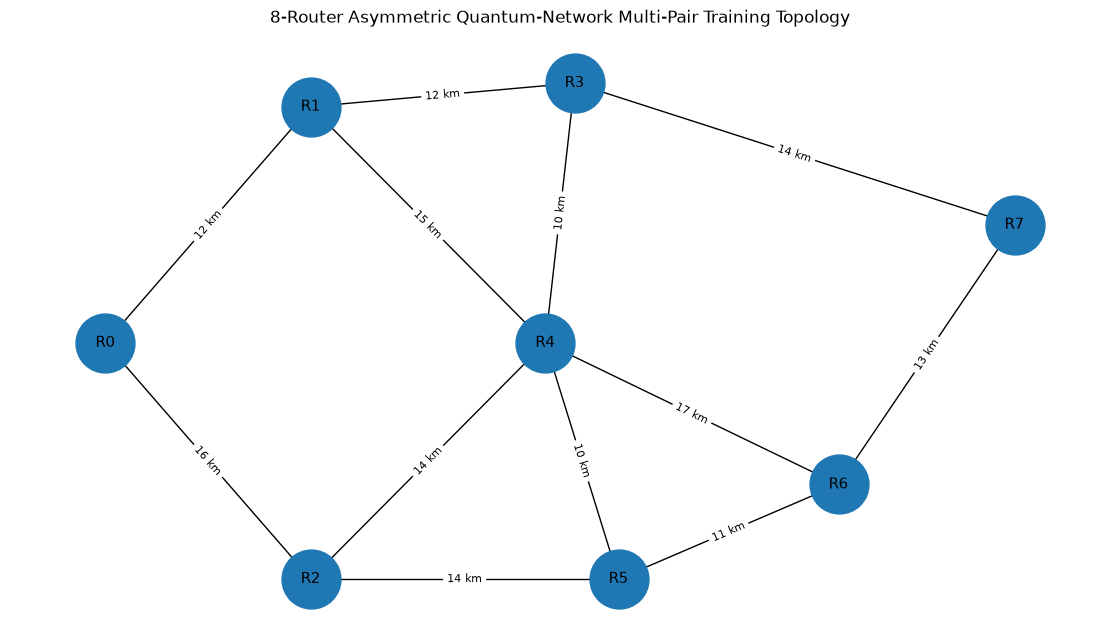


CELL 5 — MULTI-PAIR ROUTE GENERATION COMPLETE
Endpoint pairs          : 4
Routes per pair         : 4
Total route definitions : 16
Expected definitions    : 16

JSON manifest:
/content/drive/MyDrive/quantum_route_dataset/data/manifests/candidate_routes.json

CSV manifest:
/content/drive/MyDrive/quantum_route_dataset/data/manifests/candidate_routes.csv

Topology figure:
/content/drive/MyDrive/quantum_route_dataset/results/figures/training_8node_mesh.png

✓ Four candidate routes generated for every pair
✓ All paths are loop-free
✓ All route IDs are globally unique
✓ Route static features calculated
✓ Multi-pair route catalogue saved


In [ ]:
# ============================================================
# MULTI-PAIR CANDIDATE-ROUTE CATALOGUE
#
# Creates:
#   4 endpoint pairs
#   × 4 candidate routes per pair
#   = 16 route definitions
# ============================================================

from itertools import islice


# ------------------------------------------------------------
# 1. Reconstruct the physical quantum-router graph
# ------------------------------------------------------------

physical_graph = nx.Graph()

edge_group_lookup = {}

for link in link_specs:

    node1 = link["node1"]
    node2 = link["node2"]

    physical_graph.add_edge(
        node1,
        node2,
        distance=float(
            link["distance"]
        ),
        attenuation=float(
            link["attenuation"]
        ),
        edge_group=str(
            link["edge_group"]
        ),
    )

    edge_group_lookup[
        frozenset(
            (
                node1,
                node2,
            )
        )
    ] = str(
        link["edge_group"]
    )


# ------------------------------------------------------------
# 2. Validate the topology graph
# ------------------------------------------------------------

assert (
    physical_graph.number_of_nodes()
    == 8
), (
    "Expected eight quantum routers."
)

assert (
    physical_graph.number_of_edges()
    == 12
), (
    "Expected twelve physical quantum links."
)

assert nx.is_connected(
    physical_graph
), (
    "The physical topology is disconnected."
)

expected_router_names = {
    f"R{index}"
    for index in range(8)
}

assert (
    set(physical_graph.nodes)
    == expected_router_names
), (
    "The physical graph does not contain "
    "the expected R0–R7 routers."
)


# ------------------------------------------------------------
# 3. Calculate static route properties
# ------------------------------------------------------------

def calculate_route_static_features(
    path: list[str],
    graph: nx.Graph,
) -> dict[str, Any]:
    """
    Calculate route properties that do not depend on the
    dynamic simulation scenario.
    """

    if len(path) < 2:
        raise ValueError(
            f"Route is too short: {path}"
        )

    route_edges = list(
        zip(
            path[:-1],
            path[1:],
        )
    )

    distances = [
        float(
            graph[node1][node2][
                "distance"
            ]
        )
        for node1, node2
        in route_edges
    ]

    attenuations = [
        float(
            graph[node1][node2][
                "attenuation"
            ]
        )
        for node1, node2
        in route_edges
    ]

    link_losses_db = [
        distance
        * attenuation
        for distance, attenuation
        in zip(
            distances,
            attenuations,
        )
    ]

    edge_groups = [
        str(
            graph[node1][node2][
                "edge_group"
            ]
        )
        for node1, node2
        in route_edges
    ]

    hop_count = len(
        route_edges
    )

    swap_count = max(
        0,
        hop_count - 1,
    )

    total_distance_m = float(
        sum(distances)
    )

    total_fibre_loss_db = float(
        sum(link_losses_db)
    )

    return {
        "path": list(path),

        "path_string": (
            " -> ".join(path)
        ),

        "hop_count": int(
            hop_count
        ),

        "swap_count": int(
            swap_count
        ),

        "total_distance_m": (
            total_distance_m
        ),

        "total_distance_km": float(
            total_distance_m
            / 1000
        ),

        "total_fibre_loss_db": (
            total_fibre_loss_db
        ),

        "maximum_link_loss_db": float(
            max(link_losses_db)
        ),

        "minimum_link_loss_db": float(
            min(link_losses_db)
        ),

        "mean_link_loss_db": float(
            np.mean(
                link_losses_db
            )
        ),

        "maximum_attenuation_db_per_km": float(
            max(attenuations)
            * 1000
        ),

        "mean_attenuation_db_per_km": float(
            np.mean(
                attenuations
            )
            * 1000
        ),

        "upper_edge_count": int(
            edge_groups.count(
                "upper"
            )
        ),

        "lower_edge_count": int(
            edge_groups.count(
                "lower"
            )
        ),

        "central_edge_count": int(
            edge_groups.count(
                "central"
            )
        ),
    }


# ------------------------------------------------------------
# 4. Generate four candidate routes for every endpoint pair
# ------------------------------------------------------------

candidate_route_records = []

candidate_paths_by_pair = {}


for endpoint_pair in ENDPOINT_PAIRS:

    pair_id = str(
        endpoint_pair["pair_id"]
    )

    source_router = str(
        endpoint_pair["source"]
    )

    destination_router = str(
        endpoint_pair["destination"]
    )

    # --------------------------------------------------------
    # Validate endpoint names
    # --------------------------------------------------------

    if (
        source_router
        not in physical_graph
    ):
        raise KeyError(
            f"Unknown source router "
            f"{source_router} for {pair_id}."
        )

    if (
        destination_router
        not in physical_graph
    ):
        raise KeyError(
            f"Unknown destination router "
            f"{destination_router} "
            f"for {pair_id}."
        )

    if (
        source_router
        == destination_router
    ):
        raise ValueError(
            f"{pair_id} uses the same source "
            "and destination."
        )

    if not nx.has_path(
        physical_graph,
        source_router,
        destination_router,
    ):
        raise RuntimeError(
            f"No physical path exists for "
            f"{pair_id}: "
            f"{source_router} -> "
            f"{destination_router}."
        )

    # --------------------------------------------------------
    # K shortest loop-free paths by physical distance
    # --------------------------------------------------------

    path_generator = (
        nx.shortest_simple_paths(
            physical_graph,
            source=source_router,
            target=destination_router,
            weight="distance",
        )
    )

    candidate_paths = list(
        islice(
            path_generator,
            N_CANDIDATE_ROUTES,
        )
    )

    if (
        len(candidate_paths)
        != N_CANDIDATE_ROUTES
    ):
        raise RuntimeError(
            f"{pair_id} produced only "
            f"{len(candidate_paths)} paths; "
            f"{N_CANDIDATE_ROUTES} are required."
        )

    unique_paths = {
        tuple(path)
        for path in candidate_paths
    }

    if (
        len(unique_paths)
        != N_CANDIDATE_ROUTES
    ):
        raise RuntimeError(
            f"{pair_id} contains duplicate "
            "candidate paths."
        )

    candidate_paths_by_pair[
        pair_id
    ] = candidate_paths

    # --------------------------------------------------------
    # Create one route record for every candidate
    # --------------------------------------------------------

    for route_number, path in enumerate(
        candidate_paths,
        start=1,
    ):

        route_features = (
            calculate_route_static_features(
                path=path,
                graph=physical_graph,
            )
        )

        local_route_id = (
            f"route_{route_number:02d}"
        )

        # Globally unique across all endpoint pairs.
        global_route_id = (
            f"{pair_id}_"
            f"{local_route_id}"
        )

        route_record = {
            "topology_id": (
                TOPOLOGY_ID
            ),

            "pair_id": (
                pair_id
            ),

            "source": (
                source_router
            ),

            "destination": (
                destination_router
            ),

            # Use route_id as the globally unique ID in all
            # later checkpoint and aggregation cells.
            "route_id": (
                global_route_id
            ),

            # Keep the local number for within-pair analysis.
            "local_route_id": (
                local_route_id
            ),

            "route_number": int(
                route_number
            ),
        }

        route_record.update(
            route_features
        )

        candidate_route_records.append(
            route_record
        )


# ------------------------------------------------------------
# 5. Validate the complete route catalogue
# ------------------------------------------------------------

assert len(
    candidate_route_records
) == EXPECTED_ROUTE_DEFINITIONS, (
    f"Expected "
    f"{EXPECTED_ROUTE_DEFINITIONS} route definitions, "
    f"but found "
    f"{len(candidate_route_records)}."
)


# Route IDs must be globally unique.
route_ids = [
    record["route_id"]
    for record
    in candidate_route_records
]

assert len(
    route_ids
) == len(
    set(route_ids)
), (
    "Global route IDs are not unique."
)


# Every endpoint pair must contain exactly four paths.
route_counts_by_pair = (
    pd.DataFrame(
        candidate_route_records
    )
    .groupby(
        "pair_id"
    )[
        "route_id"
    ]
    .nunique()
)

assert route_counts_by_pair.eq(
    N_CANDIDATE_ROUTES
).all(), (
    "At least one endpoint pair does not "
    f"contain {N_CANDIDATE_ROUTES} routes."
)


# All routes must be loop-free and correctly terminated.
for route_record in (
    candidate_route_records
):

    path = route_record["path"]

    assert (
        path[0]
        == route_record["source"]
    )

    assert (
        path[-1]
        == route_record["destination"]
    )

    assert (
        len(path)
        == len(set(path))
    ), (
        f"Loop found in "
        f"{route_record['route_id']}."
    )


# ------------------------------------------------------------
# 6. Save the complete JSON route manifest
# ------------------------------------------------------------

with ROUTE_MANIFEST_PATH.open(
    "w",
    encoding="utf-8",
) as file:

    json.dump(
        candidate_route_records,
        file,
        indent=2,
    )


# ------------------------------------------------------------
# 7. Create and save a flat CSV route manifest
# ------------------------------------------------------------

route_manifest_df = pd.DataFrame(
    [
        {
            key: value
            for key, value
            in route_record.items()
            if key != "path"
        }
        for route_record
        in candidate_route_records
    ]
)

ROUTE_MANIFEST_CSV_PATH = (
    ROUTE_MANIFEST_PATH
    .with_suffix(".csv")
)

route_manifest_df.to_csv(
    ROUTE_MANIFEST_CSV_PATH,
    index=False,
)


# ------------------------------------------------------------
# 8. Display the multi-pair route catalogue
# ------------------------------------------------------------

route_display_columns = [
    "pair_id",
    "source",
    "destination",
    "route_id",
    "path_string",
    "hop_count",
    "swap_count",
    "total_distance_km",
    "total_fibre_loss_db",
]

print("=" * 120)
print("MULTI-PAIR CANDIDATE-ROUTE CATALOGUE")
print("=" * 120)

display(
    route_manifest_df[
        route_display_columns
    ]
)

print(
    "\nRoutes per endpoint pair:"
)

print(
    route_counts_by_pair
    .to_string()
)


# ------------------------------------------------------------
# 9. Draw the physical topology
# ------------------------------------------------------------

node_positions = {
    "R0": (0.0, 1.0),
    "R1": (1.4, 2.0),
    "R2": (1.4, 0.0),
    "R3": (3.2, 2.1),
    "R4": (3.0, 1.0),
    "R5": (3.5, 0.0),
    "R6": (5.0, 0.4),
    "R7": (6.2, 1.5),
}

plt.figure(
    figsize=(11, 6)
)

nx.draw(
    physical_graph,
    pos=node_positions,
    with_labels=True,
    node_size=1800,
    font_size=11,
)

distance_labels = {
    (
        node1,
        node2,
    ): (
        f"{attributes['distance'] / 1000:.0f} km"
    )
    for (
        node1,
        node2,
        attributes,
    )
    in physical_graph.edges(
        data=True
    )
}

nx.draw_networkx_edge_labels(
    physical_graph,
    pos=node_positions,
    edge_labels=distance_labels,
    font_size=8,
)

plt.title(
    "8-Router Asymmetric Quantum-Network "
    "Multi-Pair Training Topology"
)

plt.axis("off")

# bbox_inches handles the final spacing more reliably
# than tight_layout for NetworkX edge labels.
plt.savefig(
    TOPOLOGY_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight",
)

plt.show()


# ------------------------------------------------------------
# 10. Final the preceding section report
# ------------------------------------------------------------

print("\n" + "=" * 78)
print("CELL 5 — MULTI-PAIR ROUTE GENERATION COMPLETE")
print("=" * 78)

print(
    f"Endpoint pairs          : "
    f"{N_ENDPOINT_PAIRS}"
)

print(
    f"Routes per pair         : "
    f"{N_CANDIDATE_ROUTES}"
)

print(
    f"Total route definitions : "
    f"{len(candidate_route_records)}"
)

print(
    f"Expected definitions    : "
    f"{EXPECTED_ROUTE_DEFINITIONS}"
)

print(
    f"\nJSON manifest:\n"
    f"{ROUTE_MANIFEST_PATH}"
)

print(
    f"\nCSV manifest:\n"
    f"{ROUTE_MANIFEST_CSV_PATH}"
)

print(
    f"\nTopology figure:\n"
    f"{TOPOLOGY_FIGURE_PATH}"
)

print("\n✓ Four candidate routes generated for every pair")
print("✓ All paths are loop-free")
print("✓ All route IDs are globally unique")
print("✓ Route static features calculated")
print("✓ Multi-pair route catalogue saved")

print("=" * 78)


## Validate protocol compatibility and network construction

**Purpose:** confirm that the configured SeQUeNCe stack can perform the required native multi-hop operations.

The validation covers:

- ket-vector quantum-state formalism;
- Barrett–Kok endpoint and BSM protocol compatibility;
- `SingleAtomBSM` hardware creation;
- expected router, BSM-node, memory, quantum-channel, and classical-channel counts;
- complete classical communication reachability;
- topology initialization and routing-table availability.

**Why it matters:** this section detects configuration incompatibilities before expensive simulations begin.


In [ ]:
# ============================================================
# MULTI-PAIR PROTOCOL AND TOPOLOGY VALIDATION
#
# Validates:
#   1. Native multi-hop protocol stack
#   2. Eight quantum routers
#   3. Twelve BSM nodes
#   4. Router memory hardware
#   5. Complete classical control mesh
#   6. Four endpoint pairs
#   7. Sixteen valid candidate routes
# ============================================================


# ------------------------------------------------------------
# 1. Select the native compatible generation stack
# ------------------------------------------------------------

def configure_native_generation_stack() -> None:
    """
    Select Barrett-Kok generation for both:

        A-side protocols at quantum routers
        B-side protocols at BSM nodes

    This function must be called before every fresh
    RouterNetTopo construction.
    """

    EntanglementGenerationA.set_global_type(
        BARRET_KOK
    )

    EntanglementGenerationB.set_global_type(
        BARRET_KOK
    )

    assert (
        EntanglementGenerationA.get_global_type()
        == BARRET_KOK
    ), (
        "Endpoint-side generation protocol "
        "is not Barrett-Kok."
    )

    assert (
        EntanglementGenerationB.get_global_type()
        == BARRET_KOK
    ), (
        "BSM-side generation protocol "
        "is not Barrett-Kok."
    )


# ------------------------------------------------------------
# 2. Activate protocols before loading the topology
# ------------------------------------------------------------

configure_native_generation_stack()


# ------------------------------------------------------------
# 3. Confirm the required configuration exists
# ------------------------------------------------------------

if not BASE_CONFIG_PATH.exists():
    raise FileNotFoundError(
        "The base topology configuration was not found:\n"
        f"{BASE_CONFIG_PATH}\n\n"
        "Run the preceding section before the preceding section."
    )


# ------------------------------------------------------------
# 4. Construct a temporary validation topology
# ------------------------------------------------------------

stack_check_topology = RouterNetTopo(
    str(BASE_CONFIG_PATH)
)

stack_check_timeline = (
    stack_check_topology.get_timeline()
)

stack_check_timeline.init()


# ------------------------------------------------------------
# 5. Validate the active quantum-state formalism
# ------------------------------------------------------------

active_formalism = (
    stack_check_timeline
    .quantum_manager
    .get_active_formalism()
)

assert (
    active_formalism
    == KET_STATE_FORMALISM
), (
    "Native circuit-based swapping requires "
    f"{KET_STATE_FORMALISM}, but found "
    f"{active_formalism}."
)


# ------------------------------------------------------------
# 6. Retrieve SeQUeNCe entities
# ------------------------------------------------------------

stack_check_routers = (
    stack_check_topology.get_nodes_by_type(
        "QuantumRouter"
    )
)

stack_check_bsms = (
    stack_check_topology.get_nodes_by_type(
        "BSMNode"
    )
)

stack_check_quantum_channels = (
    stack_check_topology.get_qchannels()
)

stack_check_classical_channels = (
    stack_check_topology.get_cchannels()
)

routers_by_name_check = {
    router.name: router
    for router in stack_check_routers
}


# ------------------------------------------------------------
# 7. Validate the router set
# ------------------------------------------------------------

expected_router_names = {
    f"R{router_index}"
    for router_index in range(8)
}

actual_router_names = set(
    routers_by_name_check
)

assert (
    actual_router_names
    == expected_router_names
), (
    "Router-name mismatch.\n"
    f"Expected: {sorted(expected_router_names)}\n"
    f"Found   : {sorted(actual_router_names)}"
)

assert len(
    stack_check_routers
) == 8, (
    f"Expected 8 quantum routers, "
    f"found {len(stack_check_routers)}."
)


# ------------------------------------------------------------
# 8. Validate every router's memory hardware and routing
# ------------------------------------------------------------

for router in stack_check_routers:

    memory_array = router.components[
        router.memo_arr_name
    ]

    assert len(
        memory_array
    ) == MEMORIES_PER_ROUTER, (
        f"{router.name} has "
        f"{len(memory_array)} memories; "
        f"expected {MEMORIES_PER_ROUTER}."
    )

    representative_memory = (
        memory_array[0]
    )

    assert abs(
        representative_memory.raw_fidelity
        - 0.95
    ) < 1e-12, (
        f"{router.name} has unexpected "
        "memory fidelity."
    )

    assert abs(
        representative_memory.frequency
        - MEMORY_FREQUENCY_HZ
    ) < 1e-12, (
        f"{router.name} has unexpected "
        "memory frequency."
    )

    routing_protocol = (
        router
        .network_manager
        .get_routing_protocol()
    )

    assert (
        type(routing_protocol).__name__
        == "StaticRoutingProtocol"
    ), (
        f"{router.name} does not use "
        "StaticRoutingProtocol."
    )


# ------------------------------------------------------------
# 9. Validate BSM nodes and generation protocols
# ------------------------------------------------------------

expected_bsm_count = len(
    link_specs
)

assert len(
    stack_check_bsms
) == expected_bsm_count, (
    f"Expected {expected_bsm_count} BSM nodes, "
    f"found {len(stack_check_bsms)}."
)

for bsm_node in stack_check_bsms:

    bsm_component = (
        bsm_node.components[
            bsm_node.first_component_name
        ]
    )

    assert (
        bsm_node.encoding_type
        == "single_atom"
    ), (
        f"{bsm_node.name} uses encoding "
        f"{bsm_node.encoding_type}."
    )

    assert (
        type(bsm_component).__name__
        == "SingleAtomBSM"
    ), (
        f"{bsm_node.name} contains "
        f"{type(bsm_component).__name__}."
    )

    assert (
        bsm_node.eg.protocol_type
        == BARRET_KOK
    ), (
        f"{bsm_node.name} uses generation protocol "
        f"{bsm_node.eg.protocol_type}."
    )

    assert len(
        bsm_component.detectors
    ) == 2, (
        f"{bsm_node.name} must contain two detectors."
    )


# ------------------------------------------------------------
# 10. Validate quantum-channel count
# ------------------------------------------------------------
#
# Each meet-in-the-middle quantum connection creates:
#
#   router 1 -> BSM
#   router 2 -> BSM
#
# Therefore:
#
#   12 logical quantum links × 2 = 24 channels

expected_quantum_channel_count = (
    2 * len(link_specs)
)

assert len(
    stack_check_quantum_channels
) == expected_quantum_channel_count, (
    f"Expected {expected_quantum_channel_count} "
    f"quantum channels, found "
    f"{len(stack_check_quantum_channels)}."
)


# ------------------------------------------------------------
# 11. Validate the complete router classical control mesh
# ------------------------------------------------------------
#
# Each router must have a direct classical channel to every
# other quantum router because swapping-control messages may
# be sent directly to remote endpoint routers.

for router in stack_check_routers:

    expected_destinations = (
        expected_router_names
        - {router.name}
    )

    actual_router_destinations = (
        set(router.cchannels.keys())
        & expected_router_names
    )

    missing_destinations = (
        expected_destinations
        - actual_router_destinations
    )

    assert not missing_destinations, (
        f"{router.name} is missing direct classical "
        f"channels to "
        f"{sorted(missing_destinations)}."
    )

    assert len(
        actual_router_destinations
    ) == 7, (
        f"{router.name} has direct classical channels "
        f"to {len(actual_router_destinations)} routers; "
        "expected 7."
    )


# ------------------------------------------------------------
# 12. Validate endpoint-pair definitions from the preceding section
# ------------------------------------------------------------

assert len(
    ENDPOINT_PAIRS
) == N_ENDPOINT_PAIRS, (
    "ENDPOINT_PAIRS and N_ENDPOINT_PAIRS disagree."
)

assert (
    N_ENDPOINT_PAIRS
    == 4
), (
    f"Expected 4 endpoint pairs, "
    f"found {N_ENDPOINT_PAIRS}."
)

pair_ids = [
    str(pair["pair_id"])
    for pair in ENDPOINT_PAIRS
]

endpoint_tuples = [
    (
        str(pair["source"]),
        str(pair["destination"]),
    )
    for pair in ENDPOINT_PAIRS
]

assert len(
    pair_ids
) == len(
    set(pair_ids)
), (
    "Endpoint pair IDs are not unique."
)

assert len(
    endpoint_tuples
) == len(
    set(endpoint_tuples)
), (
    "Source-destination endpoint pairs "
    "are not unique."
)

for endpoint_pair in ENDPOINT_PAIRS:

    pair_id = str(
        endpoint_pair["pair_id"]
    )

    source_router_name = str(
        endpoint_pair["source"]
    )

    destination_router_name = str(
        endpoint_pair["destination"]
    )

    assert (
        source_router_name
        in expected_router_names
    ), (
        f"{pair_id} uses unknown source router "
        f"{source_router_name}."
    )

    assert (
        destination_router_name
        in expected_router_names
    ), (
        f"{pair_id} uses unknown destination router "
        f"{destination_router_name}."
    )

    assert (
        source_router_name
        != destination_router_name
    ), (
        f"{pair_id} has identical source "
        "and destination."
    )

    assert nx.has_path(
        physical_graph,
        source_router_name,
        destination_router_name,
    ), (
        f"No physical path exists for "
        f"{pair_id}: "
        f"{source_router_name} -> "
        f"{destination_router_name}."
    )


# ------------------------------------------------------------
# 13. Validate the multi-pair route catalogue from the preceding section
# ------------------------------------------------------------

if (
    "candidate_route_records"
    not in globals()
):
    raise NameError(
        "candidate_route_records is unavailable. "
        "Run the preceding section before the preceding section."
    )

assert len(
    candidate_route_records
) == EXPECTED_ROUTE_DEFINITIONS, (
    f"Expected {EXPECTED_ROUTE_DEFINITIONS} "
    f"route definitions, but found "
    f"{len(candidate_route_records)}."
)

route_ids = [
    str(route_record["route_id"])
    for route_record
    in candidate_route_records
]

assert len(
    route_ids
) == len(
    set(route_ids)
), (
    "The route catalogue contains duplicate "
    "global route IDs."
)


# ------------------------------------------------------------
# 14. Validate routes separately for every endpoint pair
# ------------------------------------------------------------

route_catalogue_check_df = pd.DataFrame(
    candidate_route_records
)

routes_per_pair = (
    route_catalogue_check_df
    .groupby(
        "pair_id"
    )[
        "route_id"
    ]
    .nunique()
)

assert routes_per_pair.eq(
    N_CANDIDATE_ROUTES
).all(), (
    "At least one endpoint pair does not contain "
    f"{N_CANDIDATE_ROUTES} candidate routes."
)

assert set(
    route_catalogue_check_df[
        "pair_id"
    ].unique()
) == set(
    pair_ids
), (
    "The route catalogue does not cover all "
    "endpoint pairs."
)


# ------------------------------------------------------------
# 15. Validate every candidate route physically
# ------------------------------------------------------------

for route_record in candidate_route_records:

    pair_id = str(
        route_record["pair_id"]
    )

    source_router_name = str(
        route_record["source"]
    )

    destination_router_name = str(
        route_record["destination"]
    )

    candidate_path = list(
        route_record["path"]
    )

    assert (
        candidate_path[0]
        == source_router_name
    ), (
        f"{route_record['route_id']} does not start "
        f"at {source_router_name}."
    )

    assert (
        candidate_path[-1]
        == destination_router_name
    ), (
        f"{route_record['route_id']} does not end "
        f"at {destination_router_name}."
    )

    assert len(
        candidate_path
    ) == len(
        set(candidate_path)
    ), (
        f"{route_record['route_id']} contains a loop."
    )

    for current_router, next_router in zip(
        candidate_path[:-1],
        candidate_path[1:],
    ):

        assert physical_graph.has_edge(
            current_router,
            next_router,
        ), (
            f"{route_record['route_id']} uses a "
            f"nonexistent quantum link: "
            f"{current_router} -> {next_router}."
        )


# ------------------------------------------------------------
# 16. Validate route-feature fields
# ------------------------------------------------------------

required_route_fields = {
    "topology_id",
    "pair_id",
    "source",
    "destination",
    "route_id",
    "local_route_id",
    "path",
    "path_string",
    "hop_count",
    "swap_count",
    "total_distance_km",
    "total_fibre_loss_db",
    "maximum_link_loss_db",
}

for route_record in candidate_route_records:

    missing_fields = (
        required_route_fields
        - set(route_record)
    )

    assert not missing_fields, (
        f"{route_record.get('route_id', 'UNKNOWN')} "
        f"is missing fields: "
        f"{sorted(missing_fields)}."
    )

    assert (
        route_record["hop_count"]
        == len(route_record["path"]) - 1
    )

    assert (
        route_record["swap_count"]
        == max(
            0,
            route_record["hop_count"] - 1,
        )
    )


# ------------------------------------------------------------
# 17. Print final protocol and multi-pair validation report
# ------------------------------------------------------------

print("=" * 84)
print("CELL 6 — MULTI-PAIR PROTOCOL STACK VALIDATED")
print("=" * 84)

print(
    f"Quantum formalism       : "
    f"{active_formalism}"
)

print(
    f"Generation protocol     : "
    f"{BARRET_KOK}"
)

print(
    "BSM component           : "
    "SingleAtomBSM"
)

print(
    f"Quantum routers         : "
    f"{len(stack_check_routers)}"
)

print(
    f"Logical quantum links   : "
    f"{len(link_specs)}"
)

print(
    f"BSM nodes               : "
    f"{len(stack_check_bsms)}"
)

print(
    f"Quantum channels        : "
    f"{len(stack_check_quantum_channels)}"
)

print(
    "Router classical mesh   : "
    "complete (7 router peers each)"
)

print(
    f"Memories per router     : "
    f"{MEMORIES_PER_ROUTER}"
)

print(
    f"Endpoint pairs          : "
    f"{N_ENDPOINT_PAIRS}"
)

print(
    f"Routes per pair         : "
    f"{N_CANDIDATE_ROUTES}"
)

print(
    f"Total route definitions : "
    f"{len(candidate_route_records)}"
)

print("\nRoutes per endpoint pair:")

print(
    routes_per_pair.to_string()
)

print("\n✓ Native circuit-based swapping stack is active")
print("✓ Complete classical router mesh is available")
print("✓ All endpoint pairs are valid")
print("✓ All candidate routes are loop-free")
print("✓ Every route uses existing quantum links")
print("✓ Route IDs are globally unique")
print("✓ Multi-pair route catalogue is ready")

print("=" * 84)


CELL 6 — MULTI-PAIR PROTOCOL STACK VALIDATED
Quantum formalism       : ket_vector
Generation protocol     : barret_kok
BSM component           : SingleAtomBSM
Quantum routers         : 8
Logical quantum links   : 12
BSM nodes               : 12
Quantum channels        : 24
Router classical mesh   : complete (7 router peers each)
Memories per router     : 8
Endpoint pairs          : 4
Routes per pair         : 4
Total route definitions : 16

Routes per endpoint pair:
pair_id
pair_01    4
pair_02    4
pair_03    4
pair_04    4

✓ Native circuit-based swapping stack is active
✓ Complete classical router mesh is available
✓ All endpoint pairs are valid
✓ All candidate routes are loop-free
✓ Every route uses existing quantum links
✓ Route IDs are globally unique
✓ Multi-pair route catalogue is ready


## Define telemetry-aware request handling

**Purpose:** extend SeQUeNCe's request application so each simulation records detailed reservation and entanglement-delivery telemetry.

The custom application captures:

- reservation approval or rejection;
- reservation-decision timing;
- requested responder, fidelity, and memory allocation;
- qualifying entangled-memory events;
- delivery time, remote endpoint, and final fidelity;
- below-target and wrong-destination events;
- consistency between custom telemetry and native SeQUeNCe counters.

**Output:** a reusable application class used by every rollout.


In [ ]:
# ============================================================
# ENHANCED MULTI-PAIR TELEMETRY APPLICATION
#
# Records:
#   - reservation approval/rejection
#   - reservation-decision time
#   - requested endpoint and fidelity
#   - every qualifying end-to-end delivery
#   - final fidelity
#   - successful memory index
#   - wrong-endpoint events
#   - below-target-fidelity events
#
# This class is generic:
# it works for every source-destination pair.
# ============================================================


class TelemetryRequestApp(RequestApp):
    """
    Extended RequestApp used at the source router.

    The class does not assume a fixed destination such as R7.
    It dynamically reads the responder from each reservation,
    making it suitable for the multi-endpoint dataset.
    """

    def __init__(self, node):
        super().__init__(node)

        # ----------------------------------------------------
        # Reservation-decision telemetry
        # ----------------------------------------------------

        self.reservation_decision_time_ps: int | None = None
        self.reservation_approved: bool | None = None

        self.reservation_identity: int | None = None
        self.reservation_initiator: str | None = None
        self.reservation_responder: str | None = None

        self.reservation_start_time_ps: int | None = None
        self.reservation_end_time_ps: int | None = None

        self.reservation_target_fidelity: float | None = None
        self.reservation_memory_size: int | None = None

        # ----------------------------------------------------
        # Successful end-to-end delivery telemetry
        # ----------------------------------------------------

        self.success_times_ps: list[int] = []

        self.final_fidelities: list[float] = []

        self.final_remote_nodes: list[str] = []

        self.successful_memory_indices: list[int] = []

        self.delivery_event_records: list[dict] = []

        # ----------------------------------------------------
        # Additional diagnostic counters
        # ----------------------------------------------------

        # Number of all ENTANGLED memory notifications seen
        # by this source-side application.
        self.entangled_memory_event_count: int = 0

        # ENTANGLED memory events that were not associated
        # with an active reservation known by this app.
        self.unmapped_entangled_event_count: int = 0

        # Entanglement reached a node other than the requested
        # reservation responder.
        self.wrong_remote_node_event_count: int = 0

        # End-to-end entanglement was present, but its fidelity
        # was lower than the requested threshold.
        self.below_target_fidelity_event_count: int = 0


    # --------------------------------------------------------
    # Reservation decision callback
    # --------------------------------------------------------

    def get_reservation_result(
        self,
        reservation,
        result: bool,
    ) -> None:
        """
        Record whether the reservation was accepted and when
        the decision arrived at the source application.
        """

        self.reservation_decision_time_ps = int(
            self.node.timeline.now()
        )

        self.reservation_approved = bool(
            result
        )

        # Different SeQUeNCe objects may expose the identifier
        # as id or identity. Read either safely.
        self.reservation_identity = getattr(
            reservation,
            "identity",
            getattr(
                reservation,
                "id",
                None,
            ),
        )

        self.reservation_initiator = str(
            getattr(
                reservation,
                "initiator",
                "",
            )
        )

        self.reservation_responder = str(
            getattr(
                reservation,
                "responder",
                "",
            )
        )

        self.reservation_start_time_ps = int(
            getattr(
                reservation,
                "start_time",
                0,
            )
        )

        self.reservation_end_time_ps = int(
            getattr(
                reservation,
                "end_time",
                0,
            )
        )

        self.reservation_target_fidelity = float(
            getattr(
                reservation,
                "fidelity",
                0.0,
            )
        )

        self.reservation_memory_size = int(
            getattr(
                reservation,
                "memory_size",
                0,
            )
        )

        # Preserve the original RequestApp behaviour.
        super().get_reservation_result(
            reservation,
            result,
        )


    # --------------------------------------------------------
    # Memory-delivery callback
    # --------------------------------------------------------

    def get_memory(
        self,
        info,
    ) -> None:
        """
        Inspect each memory notification before RequestApp
        resets or reuses the memory.

        A delivery is qualifying only when:

            memory is ENTANGLED
            + memory belongs to an active reservation
            + remote node equals reservation responder
            + fidelity meets the requested threshold
        """

        memory_state = getattr(
            info,
            "state",
            None,
        )

        memory_index = getattr(
            info,
            "index",
            None,
        )

        if memory_state == "ENTANGLED":

            self.entangled_memory_event_count += 1

            if (
                memory_index
                not in self.memo_to_reservation
            ):

                self.unmapped_entangled_event_count += 1

            else:

                reservation = (
                    self.memo_to_reservation[
                        memory_index
                    ]
                )

                expected_remote_node = str(
                    reservation.responder
                )

                actual_remote_node = str(
                    getattr(
                        info,
                        "remote_node",
                        "",
                    )
                )

                actual_fidelity = float(
                    getattr(
                        info,
                        "fidelity",
                        0.0,
                    )
                )

                required_fidelity = float(
                    reservation.fidelity
                )

                event_time_ps = int(
                    self.node.timeline.now()
                )

                # --------------------------------------------
                # Wrong remote endpoint
                # --------------------------------------------

                if (
                    actual_remote_node
                    != expected_remote_node
                ):

                    self.wrong_remote_node_event_count += 1

                # --------------------------------------------
                # Fidelity below request requirement
                # --------------------------------------------

                elif (
                    actual_fidelity
                    < required_fidelity
                ):

                    self.below_target_fidelity_event_count += 1

                # --------------------------------------------
                # Qualifying end-to-end entanglement
                # --------------------------------------------

                else:

                    self.success_times_ps.append(
                        event_time_ps
                    )

                    self.final_fidelities.append(
                        actual_fidelity
                    )

                    self.final_remote_nodes.append(
                        actual_remote_node
                    )

                    self.successful_memory_indices.append(
                        int(memory_index)
                    )

                    self.delivery_event_records.append(
                        {
                            "event_time_ps": (
                                event_time_ps
                            ),

                            "memory_index": int(
                                memory_index
                            ),

                            "remote_node": (
                                actual_remote_node
                            ),

                            "fidelity": (
                                actual_fidelity
                            ),

                            "required_fidelity": (
                                required_fidelity
                            ),

                            "reservation_identity": getattr(
                                reservation,
                                "identity",
                                getattr(
                                    reservation,
                                    "id",
                                    None,
                                ),
                            ),

                            "reservation_initiator": str(
                                reservation.initiator
                            ),

                            "reservation_responder": str(
                                reservation.responder
                            ),
                        }
                    )

        # Preserve RequestApp's original memory handling,
        # counter updates, memory reset, and protocol behavior.
        super().get_memory(
            info
        )


    # --------------------------------------------------------
    # Convenient derived telemetry
    # --------------------------------------------------------

    @property
    def first_success_time_ps(
        self,
    ) -> int | None:
        """
        Return the first qualifying delivery time.
        """

        if not self.success_times_ps:
            return None

        return min(
            self.success_times_ps
        )


    @property
    def last_success_time_ps(
        self,
    ) -> int | None:
        """
        Return the final qualifying delivery time.
        """

        if not self.success_times_ps:
            return None

        return max(
            self.success_times_ps
        )


    @property
    def maximum_final_fidelity(
        self,
    ) -> float | None:
        """
        Return the highest qualifying delivered fidelity.
        """

        if not self.final_fidelities:
            return None

        return max(
            self.final_fidelities
        )


    @property
    def mean_final_fidelity(
        self,
    ) -> float | None:
        """
        Return the mean fidelity across qualifying deliveries.
        """

        if not self.final_fidelities:
            return None

        return float(
            sum(
                self.final_fidelities
            )
            / len(
                self.final_fidelities
            )
        )


    def get_telemetry_summary(
        self,
    ) -> dict:
        """
        Return a JSON-serializable summary for optional use in
        the rollout dataset.
        """

        return {
            "reservation_approved_app": (
                self.reservation_approved
            ),

            "reservation_decision_time_ps": (
                self.reservation_decision_time_ps
            ),

            "reservation_identity": (
                self.reservation_identity
            ),

            "reservation_initiator": (
                self.reservation_initiator
            ),

            "reservation_responder": (
                self.reservation_responder
            ),

            "reservation_start_time_ps": (
                self.reservation_start_time_ps
            ),

            "reservation_end_time_ps": (
                self.reservation_end_time_ps
            ),

            "reservation_target_fidelity": (
                self.reservation_target_fidelity
            ),

            "reservation_memory_size": (
                self.reservation_memory_size
            ),

            "qualifying_delivery_count": len(
                self.success_times_ps
            ),

            "first_success_time_ps": (
                self.first_success_time_ps
            ),

            "last_success_time_ps": (
                self.last_success_time_ps
            ),

            "maximum_final_fidelity": (
                self.maximum_final_fidelity
            ),

            "mean_final_fidelity": (
                self.mean_final_fidelity
            ),

            "entangled_memory_event_count": (
                self.entangled_memory_event_count
            ),

            "unmapped_entangled_event_count": (
                self.unmapped_entangled_event_count
            ),

            "wrong_remote_node_event_count": (
                self.wrong_remote_node_event_count
            ),

            "below_target_fidelity_event_count": (
                self.below_target_fidelity_event_count
            ),
        }


print("=" * 80)
print("CELL 7 — ENHANCED TELEMETRY APPLICATION LOADED")
print("=" * 80)

print(
    "✓ Multi-endpoint reservation telemetry enabled"
)

print(
    "✓ Reservation approval and decision time recorded"
)

print(
    "✓ Successful delivery fidelity and latency recorded"
)

print(
    "✓ Wrong-endpoint events recorded"
)

print(
    "✓ Below-target-fidelity events recorded"
)

print(
    "✓ Original RequestApp behaviour preserved"
)

print("=" * 80)


CELL 7 — ENHANCED TELEMETRY APPLICATION LOADED
✓ Multi-endpoint reservation telemetry enabled
✓ Reservation approval and decision time recorded
✓ Successful delivery fidelity and latency recorded
✓ Wrong-endpoint events recorded
✓ Below-target-fidelity events recorded
✓ Original RequestApp behaviour preserved


## Generate controlled operating scenarios

**Purpose:** create diverse network conditions for training and validation.

The scenario generator uses Latin Hypercube Sampling and balanced categorical assignment to vary:

- target fidelity;
- request deadline;
- memory and detector efficiency;
- memory coherence time;
- attenuation degradation;
- congestion hotspot location;
- pre-existing memory reservation pressure;
- easy, moderate, and hard operating regimes.

Scenarios are assigned at the scenario level so all routes from the same network state remain in the same dataset split.

**Output:** a reproducible scenario manifest with 75 unique operating conditions.


In [ ]:
# ============================================================
# TOP-QUALITY MULTI-PAIR SCENARIO MANIFEST
#
# Design:
#   - 20% easy scenarios
#   - 60% moderate/borderline scenarios
#   - 20% hard scenarios
#   - Latin Hypercube Sampling for continuous parameters
#   - congestion hotspots across all eight routers
#   - balanced degradation-group coverage
#   - scenario-level stratified train/validation split
#
# For N_SCENARIOS = 75:
#   Easy      = 15
#   Moderate  = 45
#   Hard      = 15
#
# Every scenario is reused across all endpoint pairs and all
# candidate routes, providing fair counterfactual comparison.
# ============================================================

from scipy.stats import qmc


SCENARIO_GENERATION_VERSION = (
    "multipair_lhs_v1"
)


# ------------------------------------------------------------
# 1. Retrieve all valid quantum-router names
# ------------------------------------------------------------

scenario_router_names = sorted(
    [
        str(router["name"])
        for router in router_definitions
    ]
)

expected_scenario_routers = {
    f"R{router_index}"
    for router_index in range(8)
}

assert set(
    scenario_router_names
) == expected_scenario_routers, (
    "Scenario generator expected routers R0–R7, "
    f"but found {scenario_router_names}."
)


# ------------------------------------------------------------
# 2. Generate approximately balanced categorical values
# ------------------------------------------------------------

def create_balanced_categorical_values(
    value_pool: list[str],
    count: int,
    rng: np.random.Generator,
) -> list[str]:
    """
    Repeat, shuffle, and truncate a categorical pool.

    Duplicate entries in value_pool act as weights.

    Example:
        ["none", "none", "upper", "lower", "central"]

    gives 'none' approximately twice the frequency of each
    individual degradation group.
    """

    if count <= 0:
        return []

    if not value_pool:
        raise ValueError(
            "value_pool cannot be empty."
        )

    repetition_count = (
        count
        + len(value_pool)
        - 1
    ) // len(value_pool)

    values = (
        list(value_pool)
        * repetition_count
    )

    rng.shuffle(values)

    return values[:count]


# ------------------------------------------------------------
# 3. Build one difficulty-specific scenario block
# ------------------------------------------------------------

def generate_difficulty_block(
    difficulty: str,
    count: int,
    seed: int,
    router_names: list[str],
) -> list[dict]:
    """
    Generate one scenario block using Latin Hypercube Sampling.

    Six continuous dimensions are sampled:

        1. target fidelity
        2. request window
        3. memory efficiency
        4. detector efficiency
        5. coherence time
        6. attenuation multiplier
    """

    if count <= 0:
        return []

    difficulty = str(
        difficulty
    ).lower()

    # --------------------------------------------------------
    # Parameter ranges
    # --------------------------------------------------------

    if difficulty == "easy":

        lower_bounds = [
            0.55,   # target fidelity
            10.0,   # request window ms
            0.88,   # memory efficiency
            0.88,   # detector efficiency
            0.50,   # coherence time s
            1.00,   # attenuation factor
        ]

        upper_bounds = [
            0.64,
            25.0,
            0.96,
            0.96,
            1.00,
            1.20,
        ]

        blocked_fraction_choices = [
            0.000,
            0.125,
            0.250,
        ]

        # More uncongested easy cases.
        hotspot_pool = (
            ["none", "none", "none"]
            + router_names
        )

        # More non-degraded cases.
        degradation_pool = [
            "none",
            "none",
            "upper",
            "lower",
            "central",
        ]

    elif difficulty == "moderate":

        lower_bounds = [
            0.61,
            3.0,
            0.78,
            0.78,
            0.08,
            1.10,
        ]

        upper_bounds = [
            0.71,
            10.0,
            0.92,
            0.92,
            0.50,
            1.80,
        ]

        blocked_fraction_choices = [
            0.250,
            0.375,
            0.500,
            0.625,
        ]

        # Most moderate scenarios contain a real hotspot.
        hotspot_pool = (
            ["none"]
            + router_names
        )

        degradation_pool = [
            "none",
            "upper",
            "upper",
            "lower",
            "lower",
            "central",
            "central",
        ]

    elif difficulty == "hard":

        lower_bounds = [
            0.67,
            1.0,
            0.68,
            0.68,
            0.03,
            1.60,
        ]

        upper_bounds = [
            0.74,
            4.5,
            0.82,
            0.82,
            0.15,
            2.60,
        ]

        blocked_fraction_choices = [
            0.500,
            0.625,
            0.750,
            0.875,
        ]

        # Hard scenarios usually contain resource pressure.
        hotspot_pool = (
            router_names
            + ["none"]
        )

        # Hard scenarios usually degrade a link family.
        degradation_pool = [
            "upper",
            "upper",
            "lower",
            "lower",
            "central",
            "central",
            "none",
        ]

    else:

        raise ValueError(
            f"Unknown difficulty: {difficulty}"
        )

    # --------------------------------------------------------
    # Latin Hypercube Sampling
    # --------------------------------------------------------

    lhs_sampler = qmc.LatinHypercube(
        d=6,
        seed=seed,
    )

    unit_samples = (
        lhs_sampler.random(
            n=count
        )
    )

    parameter_samples = qmc.scale(
        sample=unit_samples,
        l_bounds=lower_bounds,
        u_bounds=upper_bounds,
    )

    # Separate RNG for discrete variables.
    discrete_rng = np.random.default_rng(
        seed + 50_000
    )

    hotspot_values = (
        create_balanced_categorical_values(
            value_pool=hotspot_pool,
            count=count,
            rng=discrete_rng,
        )
    )

    degradation_values = (
        create_balanced_categorical_values(
            value_pool=degradation_pool,
            count=count,
            rng=discrete_rng,
        )
    )

    blocked_fraction_values = (
        discrete_rng.choice(
            blocked_fraction_choices,
            size=count,
            replace=True,
        )
    )

    block_records = []

    # --------------------------------------------------------
    # Convert samples into scenario records
    # --------------------------------------------------------

    for local_index in range(count):

        (
            target_fidelity,
            request_window_ms,
            memory_efficiency,
            detector_efficiency,
            coherence_time_s,
            attenuation_factor,
        ) = parameter_samples[
            local_index
        ]

        hotspot_node = str(
            hotspot_values[
                local_index
            ]
        )

        degraded_group = str(
            degradation_values[
                local_index
            ]
        )

        blocked_fraction = float(
            blocked_fraction_values[
                local_index
            ]
        )

        # No hotspot means no occupied memories.
        if hotspot_node == "none":
            blocked_fraction = 0.0

        # No degraded group means no attenuation multiplier.
        if degraded_group == "none":
            attenuation_factor = 1.0

        block_records.append(
            {
                "difficulty": (
                    difficulty
                ),

                "target_fidelity": float(
                    target_fidelity
                ),

                "request_window_ms": float(
                    request_window_ms
                ),

                "memory_size": 1,

                "memory_efficiency": float(
                    memory_efficiency
                ),

                "detector_efficiency": float(
                    detector_efficiency
                ),

                "coherence_time_s": float(
                    coherence_time_s
                ),

                "degraded_group": (
                    degraded_group
                ),

                "attenuation_factor": float(
                    attenuation_factor
                ),

                "hotspot_node": (
                    hotspot_node
                ),

                "blocked_fraction": float(
                    blocked_fraction
                ),

                "sampling_method": (
                    "latin_hypercube"
                ),

                "scenario_generation_version": (
                    SCENARIO_GENERATION_VERSION
                ),
            }
        )

    return block_records


# ------------------------------------------------------------
# 4. Generate the complete scenario manifest
# ------------------------------------------------------------

def generate_scenario_manifest(
    n_scenarios: int,
    seed: int,
) -> pd.DataFrame:
    """
    Generate the complete scenario manifest.

    Difficulty distribution:

        20% easy
        60% moderate/borderline
        20% hard

    The train/validation assignment is performed at the
    scenario level and stratified by difficulty.
    """

    if n_scenarios < 5:
        raise ValueError(
            "At least five scenarios are required."
        )

    master_rng = np.random.default_rng(
        seed
    )

    # --------------------------------------------------------
    # Difficulty counts
    # --------------------------------------------------------

    easy_count = max(
        1,
        int(
            round(
                0.20 * n_scenarios
            )
        ),
    )

    hard_count = max(
        1,
        int(
            round(
                0.20 * n_scenarios
            )
        ),
    )

    moderate_count = (
        n_scenarios
        - easy_count
        - hard_count
    )

    if moderate_count < 1:
        raise ValueError(
            "Not enough scenarios remain for "
            "the moderate difficulty group."
        )

    # --------------------------------------------------------
    # Generate difficulty blocks
    # --------------------------------------------------------

    records = []

    records.extend(
        generate_difficulty_block(
            difficulty="easy",
            count=easy_count,
            seed=seed + 101,
            router_names=scenario_router_names,
        )
    )

    records.extend(
        generate_difficulty_block(
            difficulty="moderate",
            count=moderate_count,
            seed=seed + 202,
            router_names=scenario_router_names,
        )
    )

    records.extend(
        generate_difficulty_block(
            difficulty="hard",
            count=hard_count,
            seed=seed + 303,
            router_names=scenario_router_names,
        )
    )

    assert len(records) == n_scenarios

    # --------------------------------------------------------
    # Shuffle scenario order reproducibly
    # --------------------------------------------------------

    shuffled_indices = (
        master_rng.permutation(
            len(records)
        )
    )

    records = [
        records[index]
        for index in shuffled_indices
    ]

    # --------------------------------------------------------
    # Assign scenario identifiers and rollout base seeds
    # --------------------------------------------------------

    for scenario_index, record in enumerate(
        records,
        start=1,
    ):

        record["scenario_id"] = (
            f"scenario_{scenario_index:03d}"
        )

        record["scenario_index"] = (
            scenario_index
        )

        record["base_seed"] = int(
            seed
            + scenario_index
            * 10_000
        )

    scenario_df = pd.DataFrame(
        records
    )

    # --------------------------------------------------------
    # Stratified scenario-level train/validation split
    # --------------------------------------------------------

    scenario_df["split"] = "train"

    split_rng = np.random.default_rng(
        seed + 90_000
    )

    validation_ids = set()

    for difficulty_name, difficulty_group in (
        scenario_df.groupby(
            "difficulty"
        )
    ):

        group_size = len(
            difficulty_group
        )

        if group_size >= 5:

            validation_count = max(
                1,
                int(
                    round(
                        0.20 * group_size
                    )
                ),
            )

        elif group_size >= 2:

            validation_count = 1

        else:

            validation_count = 0

        if validation_count > 0:

            selected_ids = (
                split_rng.choice(
                    difficulty_group[
                        "scenario_id"
                    ].to_numpy(),
                    size=validation_count,
                    replace=False,
                )
            )

            validation_ids.update(
                selected_ids.tolist()
            )

    scenario_df.loc[
        scenario_df[
            "scenario_id"
        ].isin(validation_ids),
        "split",
    ] = "validation"

    # --------------------------------------------------------
    # Arrange columns
    # --------------------------------------------------------

    column_order = [
        "scenario_id",
        "scenario_index",
        "difficulty",
        "target_fidelity",
        "request_window_ms",
        "memory_size",
        "memory_efficiency",
        "detector_efficiency",
        "coherence_time_s",
        "degraded_group",
        "attenuation_factor",
        "hotspot_node",
        "blocked_fraction",
        "base_seed",
        "split",
        "sampling_method",
        "scenario_generation_version",
    ]

    scenario_df = scenario_df[
        column_order
    ]

    # --------------------------------------------------------
    # Manifest integrity checks
    # --------------------------------------------------------

    assert len(
        scenario_df
    ) == n_scenarios

    assert (
        scenario_df[
            "scenario_id"
        ].nunique()
        == n_scenarios
    ), (
        "Scenario IDs are not unique."
    )

    assert (
        scenario_df[
            "base_seed"
        ].nunique()
        == n_scenarios
    ), (
        "Scenario base seeds are not unique."
    )

    assert not (
        scenario_df[
            "degraded_group"
        ].eq("none")
        & ~np.isclose(
            scenario_df[
                "attenuation_factor"
            ],
            1.0,
        )
    ).any(), (
        "A non-degraded scenario has an "
        "attenuation factor other than 1."
    )

    assert not (
        scenario_df[
            "hotspot_node"
        ].eq("none")
        & ~np.isclose(
            scenario_df[
                "blocked_fraction"
            ],
            0.0,
        )
    ).any(), (
        "A no-hotspot scenario has blocked memories."
    )

    assert set(
        scenario_df[
            "degraded_group"
        ].unique()
    ) == {
        "none",
        "upper",
        "lower",
        "central",
    }, (
        "Not all degradation groups are represented."
    )

    represented_hotspots = set(
        scenario_df[
            "hotspot_node"
        ].unique()
    )

    assert set(
        scenario_router_names
    ).issubset(
        represented_hotspots
    ), (
        "Not every quantum router appears as "
        "a congestion hotspot."
    )

    return scenario_df


# ------------------------------------------------------------
# 5. Generate and save the scenario manifest
# ------------------------------------------------------------

scenario_df = generate_scenario_manifest(
    n_scenarios=N_SCENARIOS,
    seed=MASTER_SEED,
)

scenario_df.to_csv(
    SCENARIO_MANIFEST_PATH,
    index=False,
)


# ------------------------------------------------------------
# 6. Scenario-manifest summary
# ------------------------------------------------------------

difficulty_summary = (
    scenario_df[
        "difficulty"
    ]
    .value_counts()
    .reindex(
        [
            "easy",
            "moderate",
            "hard",
        ]
    )
)

split_summary = (
    scenario_df[
        "split"
    ]
    .value_counts()
)

difficulty_split_summary = (
    pd.crosstab(
        scenario_df[
            "difficulty"
        ],
        scenario_df[
            "split"
        ],
    )
    .reindex(
        [
            "easy",
            "moderate",
            "hard",
        ]
    )
)

degradation_summary = (
    scenario_df[
        "degraded_group"
    ]
    .value_counts()
)

hotspot_summary = (
    scenario_df[
        "hotspot_node"
    ]
    .value_counts()
    .sort_index()
)


print("=" * 88)
print("CELL 8 — TOP-QUALITY SCENARIO MANIFEST GENERATED")
print("=" * 88)

print(
    f"Total scenarios          : "
    f"{len(scenario_df)}"
)

print(
    f"Sampling method          : "
    f"Latin Hypercube"
)

print(
    f"Generation version       : "
    f"{SCENARIO_GENERATION_VERSION}"
)

print("\nDifficulty distribution:")

print(
    difficulty_summary.to_string()
)

print("\nTrain/validation distribution:")

print(
    split_summary.to_string()
)

print("\nDifficulty by split:")

print(
    difficulty_split_summary.to_string()
)

print("\nDegradation-group distribution:")

print(
    degradation_summary.to_string()
)

print("\nHotspot distribution:")

print(
    hotspot_summary.to_string()
)

print(
    f"\nScenario manifest saved to:\n"
    f"{SCENARIO_MANIFEST_PATH}"
)

print("=" * 88)


# Display the first twenty scenarios.
display(
    scenario_df.head(20)
)


CELL 8 — TOP-QUALITY SCENARIO MANIFEST GENERATED
Total scenarios          : 75
Sampling method          : Latin Hypercube
Generation version       : multipair_lhs_v1

Difficulty distribution:
difficulty
easy        15
moderate    45
hard        15

Train/validation distribution:
split
train         60
validation    15

Difficulty by split:
split       train  validation
difficulty                   
easy           12           3
moderate       36           9
hard           12           3

Degradation-group distribution:
degraded_group
upper      20
lower      20
central    20
none       15

Hotspot distribution:
hotspot_node
R0       8
R1       8
R2       8
R3       8
R4       9
R5       7
R6       8
R7       8
none    11

Scenario manifest saved to:
/content/drive/MyDrive/quantum_route_dataset/data/manifests/training_scenarios.csv


,scenario_id,scenario_index,difficulty,target_fidelity,request_window_ms,memory_size,memory_efficiency,detector_efficiency,coherence_time_s,degraded_group,attenuation_factor,hotspot_node,blocked_fraction,base_seed,split,sampling_method,scenario_generation_version
0,scenario_001,1,hard,0.698334,2.134763,1,0.769406,0.699939,0.139739,upper,2.217047,R2,0.625,10042,train,latin_hypercube,multipair_lhs_v1
1,scenario_002,2,moderate,0.655833,9.244256,1,0.890698,0.819300,0.081857,lower,1.178222,R3,0.500,20042,train,latin_hypercube,multipair_lhs_v1
2,scenario_003,3,moderate,0.616347,3.682150,1,0.806804,0.890056,0.461628,upper,1.785797,R2,0.500,30042,train,latin_hypercube,multipair_lhs_v1
3,scenario_004,4,moderate,0.640816,5.706943,1,0.917848,0.795430,0.172265,none,1.000000,none,0.000,40042,train,latin_hypercube,multipair_lhs_v1
4,scenario_005,5,moderate,0.676518,9.711472,1,0.859010,0.865749,0.236080,upper,1.215208,R1,0.625,50042,train,latin_hypercube,multipair_lhs_v1
5,scenario_006,6,moderate,0.626240,4.909304,1,0.829596,0.885348,0.277955,central,1.428706,none,0.000,60042,train,latin_hypercube,multipair_lhs_v1
6,scenario_007,7,easy,0.595520,20.023208,1,0.957303,0.897844,0.809741,central,1.081573,R4,0.000,70042,train,latin_hypercube,multipair_lhs_v1
7,scenario_008,8,moderate,0.689440,6.016191,1,0.885743,0.852967,0.184162,lower,1.308374,none,0.000,80042,train,latin_hypercube,multipair_lhs_v1
8,scenario_009,9,hard,0.725870,1.766425,1,0.814065,0.801999,0.120057,lower,1.865677,none,0.000,90042,train,latin_hypercube,multipair_lhs_v1
9,scenario_010,10,moderate,0.674210,8.635022,1,0.896731,0.901257,0.228415,upper,1.514290,R0,0.375,100042,train,latin_hypercube,multipair_lhs_v1


## Build scenario mutations, forced routing, and pre-routing features

**Purpose:** prepare each independent simulation run without modifying the original topology definition.

This section provides helper functions that:

- validate scenario records and candidate paths;
- create a fresh run-specific configuration;
- modify link attenuation, memory efficiency, detector efficiency, and coherence time;
- inject synthetic reservation pressure into router memory timecards;
- install forwarding rules that force the selected candidate path;
- collect resource-availability telemetry before the request starts;
- calculate analytical route estimates and requirement margins.

**Why it matters:** these functions create the input features available to a routing model before the actual outcome is known.


In [ ]:
# ============================================================
# MULTI-PAIR SCENARIO CONFIGURATION,
# ROUTE FORCING, RESERVATION PRESSURE,
# AND PRE-ROUTING TELEMETRY
#
# Compatible with:
#   - 4 endpoint pairs
#   - 16 candidate-route definitions
#   - 75 scenarios
#   - paired stochastic rollouts
# ============================================================


# ------------------------------------------------------------
# 1. Store base physical-link information
# ------------------------------------------------------------

BASE_EDGE_GROUPS = {
    frozenset(
        (
            link["node1"],
            link["node2"],
        )
    ): str(
        link["edge_group"]
    )
    for link in link_specs
}

BASE_ATTENUATIONS = {
    frozenset(
        (
            link["node1"],
            link["node2"],
        )
    ): float(
        link["attenuation"]
    )
    for link in link_specs
}

BASE_DISTANCES = {
    frozenset(
        (
            link["node1"],
            link["node2"],
        )
    ): float(
        link["distance"]
    )
    for link in link_specs
}


assert len(BASE_EDGE_GROUPS) == len(
    link_specs
)

assert len(BASE_ATTENUATIONS) == len(
    link_specs
)

assert len(BASE_DISTANCES) == len(
    link_specs
)


# ------------------------------------------------------------
# 2. Required scenario fields
# ------------------------------------------------------------

REQUIRED_SCENARIO_FIELDS = {
    "scenario_id",
    "scenario_index",
    "difficulty",
    "target_fidelity",
    "request_window_ms",
    "memory_size",
    "memory_efficiency",
    "detector_efficiency",
    "coherence_time_s",
    "degraded_group",
    "attenuation_factor",
    "hotspot_node",
    "blocked_fraction",
    "base_seed",
    "split",
}

VALID_DEGRADATION_GROUPS = {
    "none",
    "upper",
    "lower",
    "central",
}


# ------------------------------------------------------------
# 3. Validate one scenario record
# ------------------------------------------------------------

def validate_scenario_record(
    scenario: dict[str, Any],
) -> None:
    """
    Validate scenario parameters before constructing a
    SeQUeNCe topology.
    """

    missing_fields = (
        REQUIRED_SCENARIO_FIELDS
        - set(scenario)
    )

    if missing_fields:
        raise KeyError(
            "Scenario is missing required fields: "
            f"{sorted(missing_fields)}"
        )

    target_fidelity = float(
        scenario["target_fidelity"]
    )

    request_window_ms = float(
        scenario["request_window_ms"]
    )

    memory_size = int(
        scenario["memory_size"]
    )

    memory_efficiency = float(
        scenario["memory_efficiency"]
    )

    detector_efficiency = float(
        scenario["detector_efficiency"]
    )

    coherence_time_s = float(
        scenario["coherence_time_s"]
    )

    blocked_fraction = float(
        scenario["blocked_fraction"]
    )

    attenuation_factor = float(
        scenario["attenuation_factor"]
    )

    degraded_group = str(
        scenario["degraded_group"]
    )

    hotspot_node = str(
        scenario["hotspot_node"]
    )

    if not (
        0 < target_fidelity <= 1
    ):
        raise ValueError(
            "target_fidelity must be in (0, 1]."
        )

    if request_window_ms <= 0:
        raise ValueError(
            "request_window_ms must be positive."
        )

    if memory_size < 1:
        raise ValueError(
            "memory_size must be at least 1."
        )

    if not (
        0 < memory_efficiency <= 1
    ):
        raise ValueError(
            "memory_efficiency must be in (0, 1]."
        )

    if not (
        0 < detector_efficiency <= 1
    ):
        raise ValueError(
            "detector_efficiency must be in (0, 1]."
        )

    if coherence_time_s <= 0:
        raise ValueError(
            "coherence_time_s must be positive."
        )

    if not (
        0 <= blocked_fraction < 1
    ):
        raise ValueError(
            "blocked_fraction must be in [0, 1)."
        )

    if attenuation_factor <= 0:
        raise ValueError(
            "attenuation_factor must be positive."
        )

    if (
        degraded_group
        not in VALID_DEGRADATION_GROUPS
    ):
        raise ValueError(
            "Unknown degradation group: "
            f"{degraded_group}"
        )

    valid_hotspots = (
        set(physical_graph.nodes)
        | {"none"}
    )

    if hotspot_node not in valid_hotspots:
        raise ValueError(
            f"Unknown hotspot node: {hotspot_node}"
        )

    if (
        degraded_group == "none"
        and not np.isclose(
            attenuation_factor,
            1.0,
        )
    ):
        raise ValueError(
            "attenuation_factor must equal 1.0 "
            "when degraded_group is none."
        )

    if (
        hotspot_node == "none"
        and not np.isclose(
            blocked_fraction,
            0.0,
        )
    ):
        raise ValueError(
            "blocked_fraction must equal 0.0 "
            "when hotspot_node is none."
        )


# ------------------------------------------------------------
# 4. Build a scenario-specific configuration
# ------------------------------------------------------------

def build_run_configuration(
    base_config: dict[str, Any],
    scenario: dict[str, Any],
    rollout_id: int,
    route_record: dict[str, Any] | None = None,
) -> dict[str, Any]:
    """
    Build one fresh scenario-specific configuration.

    The same scenario and rollout seed are reused for all
    candidate routes. This creates paired counterfactual
    comparisons between routes under equivalent stochastic
    conditions.

    The route ID is deliberately NOT added to the random seed.
    """

    validate_scenario_record(
        scenario
    )

    if rollout_id < 1:
        raise ValueError(
            "rollout_id must be at least 1."
        )

    config = copy.deepcopy(
        base_config
    )

    # Request begins after topology initialization.
    request_start_ms = 5.0

    request_end_ms = (
        request_start_ms
        + float(
            scenario[
                "request_window_ms"
            ]
        )
    )

    stop_time_ms = (
        request_end_ms
        + 2.0
    )

    config["stop_time"] = int(
        stop_time_ms
        * MILLISECOND
    )

    config["formalism"] = (
        KET_STATE_FORMALISM
    )

    # --------------------------------------------------------
    # Memory hardware
    # --------------------------------------------------------

    memory_template = (
        config["templates"]
        [ROUTER_TEMPLATE_NAME]
        ["MemoryArray"]
    )

    memory_template["fidelity"] = 0.95

    memory_template["frequency"] = float(
        MEMORY_FREQUENCY_HZ
    )

    memory_template["efficiency"] = float(
        scenario[
            "memory_efficiency"
        ]
    )

    memory_template["coherence_time"] = float(
        scenario[
            "coherence_time_s"
        ]
    )

    memory_template["cutoff_ratio"] = 1.0
    memory_template["cutoff_flag"] = True

    memory_template.pop(
        "decoherence_errors",
        None,
    )

    # --------------------------------------------------------
    # BSM detector hardware
    # --------------------------------------------------------

    detector_efficiency = float(
        scenario[
            "detector_efficiency"
        ]
    )

    detectors = (
        config["templates"]
        [BSM_TEMPLATE_NAME]
        ["SingleAtomBSM"]
        ["detectors"]
    )

    for detector in detectors:
        detector["efficiency"] = (
            detector_efficiency
        )

    # --------------------------------------------------------
    # Paired rollout seed
    # --------------------------------------------------------
    #
    # All routes evaluated for the same scenario and rollout
    # use the same underlying seed family.

    run_seed = (
        int(
            scenario["base_seed"]
        )
        + int(rollout_id)
    )

    for node_index, node in enumerate(
        config["nodes"]
    ):
        node["seed"] = (
            run_seed
            + node_index
        )

    # --------------------------------------------------------
    # Scenario-specific link attenuation
    # --------------------------------------------------------

    degraded_group = str(
        scenario[
            "degraded_group"
        ]
    )

    scenario_attenuation_factor = float(
        scenario[
            "attenuation_factor"
        ]
    )

    degraded_link_count = 0

    for link_index, connection in enumerate(
        config["qconnections"]
    ):

        edge_key = frozenset(
            (
                connection["node1"],
                connection["node2"],
            )
        )

        if edge_key not in BASE_EDGE_GROUPS:
            raise KeyError(
                "Unknown quantum connection: "
                f"{connection['node1']} "
                f"<-> {connection['node2']}"
            )

        edge_group = (
            BASE_EDGE_GROUPS[
                edge_key
            ]
        )

        should_degrade = (
            degraded_group != "none"
            and edge_group
            == degraded_group
        )

        effective_factor = (
            scenario_attenuation_factor
            if should_degrade
            else 1.0
        )

        if should_degrade:
            degraded_link_count += 1

        connection["attenuation"] = float(
            BASE_ATTENUATIONS[
                edge_key
            ]
            * effective_factor
        )

        connection["seed"] = (
            run_seed
            + 100
            + link_index
        )

    # --------------------------------------------------------
    # Run manifest
    # --------------------------------------------------------

    run_manifest = {
        "scenario_id": str(
            scenario[
                "scenario_id"
            ]
        ),

        "scenario_index": int(
            scenario[
                "scenario_index"
            ]
        ),

        "rollout_id": int(
            rollout_id
        ),

        "run_seed": int(
            run_seed
        ),

        "request_start_ms": float(
            request_start_ms
        ),

        "request_end_ms": float(
            request_end_ms
        ),

        "request_window_ms": float(
            scenario[
                "request_window_ms"
            ]
        ),

        "stop_time_ms": float(
            stop_time_ms
        ),

        "degraded_group": (
            degraded_group
        ),

        "degraded_link_count": int(
            degraded_link_count
        ),

        "paired_randomness": True,
    }

    if route_record is not None:

        run_manifest.update(
            {
                "pair_id": str(
                    route_record[
                        "pair_id"
                    ]
                ),

                "source": str(
                    route_record[
                        "source"
                    ]
                ),

                "destination": str(
                    route_record[
                        "destination"
                    ]
                ),

                "route_id": str(
                    route_record[
                        "route_id"
                    ]
                ),

                "path": list(
                    route_record[
                        "path"
                    ]
                ),
            }
        )

    config["run_manifest"] = (
        run_manifest
    )

    return config


# ------------------------------------------------------------
# 5. Validate a multi-pair candidate path
# ------------------------------------------------------------

def validate_candidate_path(
    path: list[str],
    source_router_name: str,
    destination_router_name: str,
) -> None:
    """
    Validate one candidate route for any endpoint pair.
    """

    source_router_name = str(
        source_router_name
    )

    destination_router_name = str(
        destination_router_name
    )

    if not path:
        raise ValueError(
            "Candidate path is empty."
        )

    if len(path) < 2:
        raise ValueError(
            f"Candidate path is too short: {path}"
        )

    if (
        source_router_name
        not in physical_graph
    ):
        raise KeyError(
            f"Unknown source router: "
            f"{source_router_name}"
        )

    if (
        destination_router_name
        not in physical_graph
    ):
        raise KeyError(
            f"Unknown destination router: "
            f"{destination_router_name}"
        )

    if (
        source_router_name
        == destination_router_name
    ):
        raise ValueError(
            "Source and destination cannot "
            "be identical."
        )

    if path[0] != source_router_name:
        raise ValueError(
            f"Path must start at "
            f"{source_router_name}: {path}"
        )

    if path[-1] != destination_router_name:
        raise ValueError(
            f"Path must end at "
            f"{destination_router_name}: {path}"
        )

    if len(path) != len(set(path)):
        raise ValueError(
            f"Candidate path contains a loop: "
            f"{path}"
        )

    for router_name in path:

        if router_name not in physical_graph:
            raise KeyError(
                f"Unknown router in candidate path: "
                f"{router_name}"
            )

    for current_router, next_router in zip(
        path[:-1],
        path[1:],
    ):

        if not physical_graph.has_edge(
            current_router,
            next_router,
        ):
            raise ValueError(
                "Candidate path contains a "
                "nonexistent quantum link: "
                f"{current_router} -> "
                f"{next_router}"
            )


# ------------------------------------------------------------
# 6. Force one candidate route for any destination
# ------------------------------------------------------------

def force_candidate_route(
    routers_by_name: dict[str, Any],
    path: list[str],
    source_router_name: str,
    destination_router_name: str,
) -> list[dict[str, str | None]]:
    """
    Install static forwarding entries for one candidate route.

    Example:

        source      = R0
        destination = R6
        path        = R0 -> R2 -> R5 -> R6

    Rules:

        R0 destination R6 -> R2
        R2 destination R6 -> R5
        R5 destination R6 -> R6
    """

    validate_candidate_path(
        path=path,
        source_router_name=(
            source_router_name
        ),
        destination_router_name=(
            destination_router_name
        ),
    )

    missing_routers = (
        set(path)
        - set(routers_by_name)
    )

    if missing_routers:
        raise KeyError(
            "Candidate path contains routers "
            "missing from the current topology: "
            f"{sorted(missing_routers)}"
        )

    installed_rules = []

    for current_router, next_router in zip(
        path[:-1],
        path[1:],
    ):

        router = (
            routers_by_name[
                current_router
            ]
        )

        routing_protocol = (
            router
            .network_manager
            .get_routing_protocol()
        )

        forwarding_table = (
            router
            .network_manager
            .get_forwarding_table()
        )

        previous_next_hop = (
            forwarding_table.get(
                destination_router_name
            )
        )

        if (
            destination_router_name
            in forwarding_table
        ):

            routing_protocol.update_forwarding_rule(
                destination_router_name,
                next_router,
            )

        else:

            routing_protocol.add_forwarding_rule(
                destination_router_name,
                next_router,
            )

        actual_next_hop = (
            forwarding_table.get(
                destination_router_name
            )
        )

        if actual_next_hop != next_router:
            raise RuntimeError(
                f"Could not force "
                f"{current_router}: "
                f"{destination_router_name} "
                f"-> {next_router}. "
                f"Actual next hop was "
                f"{actual_next_hop}."
            )

        installed_rules.append(
            {
                "router": str(
                    current_router
                ),

                "destination": str(
                    destination_router_name
                ),

                "previous_next_hop": (
                    previous_next_hop
                ),

                "forced_next_hop": str(
                    actual_next_hop
                ),
            }
        )

    return installed_rules


# ------------------------------------------------------------
# 7. Inject pre-existing reservation pressure
# ------------------------------------------------------------

def inject_preexisting_reservation_pressure(
    routers_by_name: dict[str, Any],
    scenario: dict[str, Any],
    request_start_ps: int,
    request_end_ps: int,
) -> dict[str, int]:
    """
    Occupy a fraction of memory timecards at one hotspot.

    This represents pre-existing demand before the target
    request is submitted.
    """

    validate_scenario_record(
        scenario
    )

    blocked_by_node = {
        router_name: 0
        for router_name
        in routers_by_name
    }

    hotspot_node = str(
        scenario[
            "hotspot_node"
        ]
    )

    blocked_fraction = float(
        scenario[
            "blocked_fraction"
        ]
    )

    if (
        hotspot_node == "none"
        or blocked_fraction <= 0
    ):
        return blocked_by_node

    if hotspot_node not in routers_by_name:
        raise KeyError(
            f"Unknown hotspot router: "
            f"{hotspot_node}"
        )

    if request_end_ps <= request_start_ps:
        raise ValueError(
            "Reservation-pressure end time must "
            "be later than its start time."
        )

    hotspot_router = (
        routers_by_name[
            hotspot_node
        ]
    )

    timecards = (
        hotspot_router
        .network_manager
        .get_timecards()
    )

    total_timecards = len(
        timecards
    )

    blocked_count = min(
        total_timecards,
        int(
            round(
                total_timecards
                * blocked_fraction
            )
        ),
    )

    if blocked_count <= 0:
        return blocked_by_node

    background_reservation = Reservation(
        initiator=(
            f"BG_{hotspot_node}"
        ),

        responder=(
            f"BG_DST_{hotspot_node}"
        ),

        start_time=int(
            request_start_ps
        ),

        end_time=int(
            request_end_ps
        ),

        memory_size=1,

        fidelity=0.5,

        identity=(
            900_000
            + int(
                scenario[
                    "scenario_index"
                ]
            )
        ),
    )

    successfully_blocked = 0

    for timecard in timecards[
        :blocked_count
    ]:

        inserted = timecard.add(
            background_reservation
        )

        if not inserted:
            raise RuntimeError(
                "Could not block memory "
                f"timecard "
                f"{timecard.memory_index} "
                f"at {hotspot_node}."
            )

        successfully_blocked += 1

    blocked_by_node[
        hotspot_node
    ] = successfully_blocked

    return blocked_by_node


# ------------------------------------------------------------
# 8. Collect route-level pre-routing memory telemetry
# ------------------------------------------------------------

def get_route_dynamic_telemetry(
    path: list[str],
    routers_by_name: dict[str, Any],
    blocked_by_node: dict[str, int],
    memory_size: int,
) -> dict[str, float | int]:
    """
    Collect memory telemetry available before route execution.
    """

    if memory_size < 1:
        raise ValueError(
            "memory_size must be at least 1."
        )

    free_counts = []
    occupancy_ratios = []
    required_margins = []

    endpoint_free_counts = []
    intermediate_free_counts = []

    endpoint_blocked_count = 0
    intermediate_blocked_count = 0

    nodes_with_pressure_count = 0

    for path_index, router_name in enumerate(
        path
    ):

        if router_name not in routers_by_name:
            raise KeyError(
                f"Router {router_name} is missing "
                "from the current topology."
            )

        router = (
            routers_by_name[
                router_name
            ]
        )

        total_memories = len(
            router
            .network_manager
            .get_timecards()
        )

        blocked_memories = int(
            blocked_by_node.get(
                router_name,
                0,
            )
        )

        free_memories = (
            total_memories
            - blocked_memories
        )

        is_endpoint = (
            path_index == 0
            or path_index
            == len(path) - 1
        )

        required_memories = (
            memory_size
            if is_endpoint
            else 2 * memory_size
        )

        free_counts.append(
            free_memories
        )

        occupancy_ratio = (
            blocked_memories
            / total_memories
            if total_memories
            else 1.0
        )

        occupancy_ratios.append(
            occupancy_ratio
        )

        required_margins.append(
            free_memories
            - required_memories
        )

        if blocked_memories > 0:
            nodes_with_pressure_count += 1

        if is_endpoint:

            endpoint_free_counts.append(
                free_memories
            )

            endpoint_blocked_count += (
                blocked_memories
            )

        else:

            intermediate_free_counts.append(
                free_memories
            )

            intermediate_blocked_count += (
                blocked_memories
            )

    minimum_intermediate_free = (
        min(
            intermediate_free_counts
        )
        if intermediate_free_counts
        else min(
            endpoint_free_counts
        )
    )

    return {
        "min_free_memories_pre": int(
            min(free_counts)
        ),

        "mean_free_memories_pre": float(
            np.mean(
                free_counts
            )
        ),

        "min_endpoint_free_memories_pre": int(
            min(
                endpoint_free_counts
            )
        ),

        "min_intermediate_free_memories_pre": int(
            minimum_intermediate_free
        ),

        "max_reservation_occupancy_pre": float(
            max(
                occupancy_ratios
            )
        ),

        "mean_reservation_occupancy_pre": float(
            np.mean(
                occupancy_ratios
            )
        ),

        "min_memory_requirement_margin": int(
            min(
                required_margins
            )
        ),

        "route_blocked_memories_total": int(
            sum(
                blocked_by_node.get(
                    router_name,
                    0,
                )
                for router_name in path
            )
        ),

        "endpoint_blocked_memories_total": int(
            endpoint_blocked_count
        ),

        "intermediate_blocked_memories_total": int(
            intermediate_blocked_count
        ),

        "route_nodes_with_pressure_count": int(
            nodes_with_pressure_count
        ),
    }


# ------------------------------------------------------------
# 9. Calculate scenario-specific pre-routing route features
# ------------------------------------------------------------

def calculate_scenario_route_features(
    path: list[str],
    run_config: dict[str, Any],
    scenario: dict[str, Any],
) -> dict[str, float | int]:
    """
    Calculate route features available before execution.

    These features contain no post-simulation outcomes.
    """

    validate_scenario_record(
        scenario
    )

    if len(path) < 2:
        raise ValueError(
            "Candidate path must contain at least "
            "two routers."
        )

    connection_map = {
        frozenset(
            (
                connection["node1"],
                connection["node2"],
            )
        ): connection
        for connection
        in run_config[
            "qconnections"
        ]
    }

    distances = []
    attenuations = []
    link_losses = []
    edge_groups = []

    link_transmission_probabilities = []
    link_success_probability_estimates = []
    expected_link_times_ms = []

    memory_efficiency = float(
        scenario[
            "memory_efficiency"
        ]
    )

    detector_efficiency = float(
        scenario[
            "detector_efficiency"
        ]
    )

    effective_efficiency = (
        memory_efficiency
        * detector_efficiency
    )

    for current_router, next_router in zip(
        path[:-1],
        path[1:],
    ):

        edge_key = frozenset(
            (
                current_router,
                next_router,
            )
        )

        if edge_key not in connection_map:
            raise KeyError(
                "No quantum connection found "
                f"for {current_router} "
                f"<-> {next_router}."
            )

        connection = (
            connection_map[
                edge_key
            ]
        )

        distance = float(
            connection[
                "distance"
            ]
        )

        attenuation = float(
            connection[
                "attenuation"
            ]
        )

        link_loss_db = (
            distance
            * attenuation
        )

        edge_group = str(
            BASE_EDGE_GROUPS[
                edge_key
            ]
        )

        transmission_probability = float(
            10 ** (
                -link_loss_db
                / 10
            )
        )

        approximate_success_probability = float(
            0.5
            * memory_efficiency**2
            * detector_efficiency**2
            * transmission_probability
        )

        approximate_success_probability = max(
            approximate_success_probability,
            1e-9,
        )

        attempt_period_ms = (
            1000.0
            / MEMORY_FREQUENCY_HZ
        )

        classical_round_trip_ms = (
            2.0
            * distance
            / SPEED_OF_LIGHT
            / MILLISECOND
        )

        expected_link_time_ms = (
            attempt_period_ms
            / approximate_success_probability
            + classical_round_trip_ms
        )

        distances.append(
            distance
        )

        attenuations.append(
            attenuation
        )

        link_losses.append(
            link_loss_db
        )

        edge_groups.append(
            edge_group
        )

        link_transmission_probabilities.append(
            transmission_probability
        )

        link_success_probability_estimates.append(
            approximate_success_probability
        )

        expected_link_times_ms.append(
            expected_link_time_ms
        )

    hop_count = (
        len(path) - 1
    )

    swap_count = max(
        0,
        hop_count - 1,
    )

    # --------------------------------------------------------
    # Estimated final route fidelity
    # --------------------------------------------------------

    raw_fidelity = float(
        run_config["templates"]
        [ROUTER_TEMPLATE_NAME]
        ["MemoryArray"]
        ["fidelity"]
    )

    swap_degradation = 0.95

    estimated_final_fidelity = float(
        raw_fidelity**hop_count
        * swap_degradation**swap_count
    )

    fidelity_margin_estimate = float(
        estimated_final_fidelity
        - float(
            scenario[
                "target_fidelity"
            ]
        )
    )

    # --------------------------------------------------------
    # Estimated route setup latency
    # --------------------------------------------------------

    estimated_latency_ms = float(
        max(
            expected_link_times_ms
        )
    )

    maximum_link_round_trip_ms = float(
        max(
            (
                2.0
                * distance
                / SPEED_OF_LIGHT
                / MILLISECOND
            )
            for distance
            in distances
        )
    )

    estimated_latency_ms += float(
        swap_count
        * maximum_link_round_trip_ms
    )

    request_window_ms = float(
        scenario[
            "request_window_ms"
        ]
    )

    deadline_margin_ms = float(
        request_window_ms
        - estimated_latency_ms
    )

    # --------------------------------------------------------
    # Route exposure to degraded links
    # --------------------------------------------------------

    degraded_group = str(
        scenario[
            "degraded_group"
        ]
    )

    if degraded_group == "none":

        degraded_link_count = 0

    else:

        degraded_link_count = int(
            sum(
                edge_group
                == degraded_group
                for edge_group
                in edge_groups
            )
        )

    degraded_link_fraction = float(
        degraded_link_count
        / hop_count
    )

    # --------------------------------------------------------
    # Route exposure to the congestion hotspot
    # --------------------------------------------------------

    hotspot_node = str(
        scenario[
            "hotspot_node"
        ]
    )

    route_contains_hotspot = int(
        hotspot_node != "none"
        and hotspot_node in path
    )

    hotspot_is_source = int(
        hotspot_node != "none"
        and hotspot_node
        == path[0]
    )

    hotspot_is_destination = int(
        hotspot_node != "none"
        and hotspot_node
        == path[-1]
    )

    hotspot_is_intermediate = int(
        hotspot_node != "none"
        and hotspot_node
        in path[1:-1]
    )

    # --------------------------------------------------------
    # Return pre-routing feature record
    # --------------------------------------------------------

    return {
        "hop_count": int(
            hop_count
        ),

        "swap_count": int(
            swap_count
        ),

        "total_distance_km": float(
            sum(distances)
            / 1000
        ),

        "maximum_link_distance_km": float(
            max(distances)
            / 1000
        ),

        "mean_link_distance_km": float(
            np.mean(
                distances
            )
            / 1000
        ),

        "total_fibre_loss_db": float(
            sum(
                link_losses
            )
        ),

        "maximum_link_loss_db": float(
            max(
                link_losses
            )
        ),

        "minimum_link_loss_db": float(
            min(
                link_losses
            )
        ),

        "mean_link_loss_db": float(
            np.mean(
                link_losses
            )
        ),

        "maximum_attenuation_db_per_km": float(
            max(
                attenuations
            )
            * 1000
        ),

        "mean_attenuation_db_per_km": float(
            np.mean(
                attenuations
            )
            * 1000
        ),

        "minimum_link_transmission_probability": float(
            min(
                link_transmission_probabilities
            )
        ),

        "mean_link_transmission_probability": float(
            np.mean(
                link_transmission_probabilities
            )
        ),

        "bottleneck_link_success_estimate": float(
            min(
                link_success_probability_estimates
            )
        ),

        "mean_link_success_estimate": float(
            np.mean(
                link_success_probability_estimates
            )
        ),

        "effective_efficiency": float(
            effective_efficiency
        ),

        "estimated_final_fidelity": float(
            estimated_final_fidelity
        ),

        "fidelity_margin_estimate": float(
            fidelity_margin_estimate
        ),

        "estimated_latency_ms": float(
            estimated_latency_ms
        ),

        "deadline_margin_ms": float(
            deadline_margin_ms
        ),

        "route_degraded_link_count": int(
            degraded_link_count
        ),

        "route_degraded_link_fraction": float(
            degraded_link_fraction
        ),

        "route_contains_hotspot": int(
            route_contains_hotspot
        ),

        "hotspot_is_source": int(
            hotspot_is_source
        ),

        "hotspot_is_destination": int(
            hotspot_is_destination
        ),

        "hotspot_is_intermediate": int(
            hotspot_is_intermediate
        ),

        "upper_edge_count": int(
            edge_groups.count(
                "upper"
            )
        ),

        "lower_edge_count": int(
            edge_groups.count(
                "lower"
            )
        ),

        "central_edge_count": int(
            edge_groups.count(
                "central"
            )
        ),
    }


# ------------------------------------------------------------
# 10. Final the preceding section validation report
# ------------------------------------------------------------

print("=" * 88)
print("CELL 9 — MULTI-PAIR FUNCTIONS LOADED")
print("=" * 88)

print(
    f"Known quantum links        : "
    f"{len(BASE_ATTENUATIONS)}"
)

print(
    f"Known edge groups          : "
    f"{sorted(set(BASE_EDGE_GROUPS.values()))}"
)

print(
    f"Valid degradation groups   : "
    f"{sorted(VALID_DEGRADATION_GROUPS)}"
)

print(
    "✓ Scenario validator loaded"
)

print(
    "✓ Paired scenario configuration builder loaded"
)

print(
    "✓ Multi-pair candidate-path validator loaded"
)

print(
    "✓ Destination-specific route forcing loaded"
)

print(
    "✓ Reservation-pressure injector loaded"
)

print(
    "✓ Multi-pair memory telemetry collector loaded"
)

print(
    "✓ Extended pre-routing feature calculator loaded"
)

print("=" * 88)


CELL 9 — MULTI-PAIR FUNCTIONS LOADED
Known quantum links        : 12
Known edge groups          : ['central', 'lower', 'upper']
Valid degradation groups   : ['central', 'lower', 'none', 'upper']
✓ Scenario validator loaded
✓ Paired scenario configuration builder loaded
✓ Multi-pair candidate-path validator loaded
✓ Destination-specific route forcing loaded
✓ Reservation-pressure injector loaded
✓ Multi-pair memory telemetry collector loaded
✓ Extended pre-routing feature calculator loaded


## Execute one complete scenario–route rollout

**Purpose:** define the atomic simulation unit used by the smoke test and full batch.

One rollout:

1. combines one scenario with one endpoint pair and one candidate route;
2. creates a fresh SeQUeNCe topology and timeline;
3. applies hardware, degradation, and congestion conditions;
4. installs the forced route;
5. submits the entanglement reservation request;
6. runs the discrete-event simulation;
7. extracts reservation, path, fidelity, latency, delivery, and integrity results;
8. assigns a failure reason and binary feasibility outcome.

**Output:** one structured dictionary representing a single stochastic simulation record.


In [ ]:
# ============================================================
# MULTI-PAIR SCENARIO-ROUTE-ROLLOUT SIMULATION
#
# One returned row represents:
#
#   one scenario
#   + one endpoint pair
#   + one candidate route
#   + one stochastic rollout
#
# Compatible with:
#   - 4 endpoint pairs
#   - 16 globally unique route definitions
#   - paired randomness across candidate routes
#   - enhanced TelemetryRequestApp from the preceding section
# ============================================================

import traceback


# ------------------------------------------------------------
# 1. Required route-record fields
# ------------------------------------------------------------

REQUIRED_ROLLOUT_ROUTE_FIELDS = {
    "topology_id",
    "pair_id",
    "source",
    "destination",
    "route_id",
    "local_route_id",
    "route_number",
    "path",
    "path_string",
}


# ------------------------------------------------------------
# 2. Run one fresh scenario-route-rollout simulation
# ------------------------------------------------------------

def run_one_rollout(
    scenario: dict[str, Any],
    route_record: dict[str, Any],
    rollout_id: int,
    verbose: bool = False,
) -> dict[str, Any]:
    """
    Evaluate one candidate route in one fresh SeQUeNCe
    simulation.

    Randomness is paired across candidate routes:

        same scenario
        + same rollout_id
        = same seed family

    The route identifier is not added to the seed. Therefore,
    competing routes are evaluated under equivalent stochastic
    conditions.
    """

    # --------------------------------------------------------
    # 3. Validate the route-record schema
    # --------------------------------------------------------

    missing_route_fields = (
        REQUIRED_ROLLOUT_ROUTE_FIELDS
        - set(route_record)
    )

    if missing_route_fields:
        raise KeyError(
            "Route record is missing required fields: "
            f"{sorted(missing_route_fields)}"
        )

    if rollout_id < 1:
        raise ValueError(
            "rollout_id must be at least 1."
        )

    # --------------------------------------------------------
    # 4. Read endpoint-pair and route information
    # --------------------------------------------------------

    pair_id = str(
        route_record["pair_id"]
    )

    source_router_name = str(
        route_record["source"]
    )

    destination_router_name = str(
        route_record["destination"]
    )

    global_route_id = str(
        route_record["route_id"]
    )

    local_route_id = str(
        route_record["local_route_id"]
    )

    route_number = int(
        route_record["route_number"]
    )

    requested_path = list(
        route_record["path"]
    )

    requested_path_string = str(
        route_record["path_string"]
    )

    # --------------------------------------------------------
    # 5. Validate the multi-pair candidate path
    # --------------------------------------------------------

    validate_candidate_path(
        path=requested_path,
        source_router_name=source_router_name,
        destination_router_name=destination_router_name,
    )

    validate_scenario_record(
        scenario
    )

    # --------------------------------------------------------
    # 6. Build the fresh scenario-specific configuration
    # --------------------------------------------------------

    run_config = build_run_configuration(
        base_config=base_configuration,
        scenario=scenario,
        rollout_id=rollout_id,
        route_record=route_record,
    )

    # Save only on the temporary Colab filesystem.
    # Each simulation reloads this fresh configuration.
    with TEMP_RUN_CONFIG_PATH.open(
        "w",
        encoding="utf-8",
    ) as file:

        json.dump(
            run_config,
            file,
            indent=2,
        )

    # --------------------------------------------------------
    # 7. Read simulation timing and seed information
    # --------------------------------------------------------

    run_manifest = (
        run_config["run_manifest"]
    )

    request_start_ms = float(
        run_manifest["request_start_ms"]
    )

    request_end_ms = float(
        run_manifest["request_end_ms"]
    )

    request_window_ms = float(
        run_manifest["request_window_ms"]
    )

    stop_time_ms = float(
        run_manifest["stop_time_ms"]
    )

    run_seed = int(
        run_manifest["run_seed"]
    )

    request_start_ps = int(
        request_start_ms
        * MILLISECOND
    )

    request_end_ps = int(
        request_end_ms
        * MILLISECOND
    )

    # --------------------------------------------------------
    # 8. Create the basic rollout record
    # --------------------------------------------------------

    base_result = {
        # Dataset identity
        "topology_id": str(
            TOPOLOGY_ID
        ),

        "pair_id": pair_id,

        "source": source_router_name,

        "destination": destination_router_name,

        "endpoint_pair_string": (
            f"{source_router_name}"
            f" -> "
            f"{destination_router_name}"
        ),

        # Route identity
        "route_id": global_route_id,

        "local_route_id": local_route_id,

        "route_number": route_number,

        "path_string": (
            requested_path_string
        ),

        # Scenario identity
        "scenario_id": str(
            scenario["scenario_id"]
        ),

        "scenario_index": int(
            scenario["scenario_index"]
        ),

        "split": str(
            scenario["split"]
        ),

        "difficulty": str(
            scenario["difficulty"]
        ),

        "sampling_method": str(
            scenario.get(
                "sampling_method",
                "",
            )
        ),

        "scenario_generation_version": str(
            scenario.get(
                "scenario_generation_version",
                "",
            )
        ),

        # Rollout identity
        "rollout_id": int(
            rollout_id
        ),

        "rollout_seed": int(
            run_seed
        ),

        "paired_randomness": int(
            bool(
                run_manifest.get(
                    "paired_randomness",
                    True,
                )
            )
        ),

        # Request parameters
        "target_fidelity": float(
            scenario["target_fidelity"]
        ),

        "request_start_ms": float(
            request_start_ms
        ),

        "request_end_ms": float(
            request_end_ms
        ),

        "request_window_ms": float(
            request_window_ms
        ),

        "configured_stop_time_ms": float(
            stop_time_ms
        ),

        "memory_size": int(
            scenario["memory_size"]
        ),

        # Hardware conditions
        "memory_efficiency": float(
            scenario[
                "memory_efficiency"
            ]
        ),

        "detector_efficiency": float(
            scenario[
                "detector_efficiency"
            ]
        ),

        "coherence_time_s": float(
            scenario[
                "coherence_time_s"
            ]
        ),

        # Degradation conditions
        "degraded_group": str(
            scenario["degraded_group"]
        ),

        "attenuation_factor": float(
            scenario[
                "attenuation_factor"
            ]
        ),

        "degraded_link_count_network": int(
            run_manifest[
                "degraded_link_count"
            ]
        ),

        # Reservation-pressure conditions
        "hotspot_node": str(
            scenario["hotspot_node"]
        ),

        "blocked_fraction": float(
            scenario[
                "blocked_fraction"
            ]
        ),
    }

    try:
        # ----------------------------------------------------
        # 9. Calculate pre-routing route features
        # ----------------------------------------------------

        route_features = (
            calculate_scenario_route_features(
                path=requested_path,
                run_config=run_config,
                scenario=scenario,
            )
        )

        base_result.update(
            route_features
        )

        # ----------------------------------------------------
        # 10. Select the compatible protocol stack
        # ----------------------------------------------------

        configure_native_generation_stack()

        # ----------------------------------------------------
        # 11. Construct a fresh SeQUeNCe topology
        # ----------------------------------------------------

        topology = RouterNetTopo(
            str(TEMP_RUN_CONFIG_PATH)
        )

        timeline = (
            topology.get_timeline()
        )

        routers = (
            topology.get_nodes_by_type(
                "QuantumRouter"
            )
        )

        routers_by_name = {
            router.name: router
            for router in routers
        }

        expected_router_names = {
            f"R{router_index}"
            for router_index in range(8)
        }

        actual_router_names = set(
            routers_by_name
        )

        if (
            actual_router_names
            != expected_router_names
        ):
            raise RuntimeError(
                "Topology router mismatch. "
                f"Expected "
                f"{sorted(expected_router_names)}, "
                f"found "
                f"{sorted(actual_router_names)}."
            )

        if (
            source_router_name
            not in routers_by_name
        ):
            raise KeyError(
                "Source router is missing from "
                f"the topology: {source_router_name}"
            )

        if (
            destination_router_name
            not in routers_by_name
        ):
            raise KeyError(
                "Destination router is missing from "
                f"the topology: "
                f"{destination_router_name}"
            )

        source_router = (
            routers_by_name[
                source_router_name
            ]
        )

        destination_router = (
            routers_by_name[
                destination_router_name
            ]
        )

        # ----------------------------------------------------
        # 12. Attach endpoint applications
        # ----------------------------------------------------

        source_app = (
            TelemetryRequestApp(
                source_router
            )
        )

        # The destination also requires an application to
        # receive and manage the destination-side reservation.
        destination_app = (
            RequestApp(
                destination_router
            )
        )

        # Retain the reference explicitly.
        _ = destination_app

        # ----------------------------------------------------
        # 13. Initialize the simulation
        # ----------------------------------------------------

        timeline.init()

        active_formalism = (
            timeline
            .quantum_manager
            .get_active_formalism()
        )

        if (
            active_formalism
            != KET_STATE_FORMALISM
        ):
            raise RuntimeError(
                "Unexpected quantum formalism: "
                f"{active_formalism}"
            )

        # Keep purification policy constant for every route.
        for router in routers:

            (
                router
                .network_manager
                .rsvp
                .set_purification_mode(
                    "once"
                )
            )

        # ----------------------------------------------------
        # 14. Inject pre-existing reservation pressure
        # ----------------------------------------------------

        blocked_by_node = (
            inject_preexisting_reservation_pressure(
                routers_by_name=(
                    routers_by_name
                ),
                scenario=scenario,
                request_start_ps=(
                    request_start_ps
                ),
                request_end_ps=(
                    request_end_ps
                ),
            )
        )

        # ----------------------------------------------------
        # 15. Collect pre-routing memory telemetry
        # ----------------------------------------------------

        dynamic_telemetry = (
            get_route_dynamic_telemetry(
                path=requested_path,
                routers_by_name=(
                    routers_by_name
                ),
                blocked_by_node=(
                    blocked_by_node
                ),
                memory_size=int(
                    scenario[
                        "memory_size"
                    ]
                ),
            )
        )

        base_result.update(
            dynamic_telemetry
        )

        # ----------------------------------------------------
        # 16. Force the selected destination-specific route
        # ----------------------------------------------------

        forced_rules = (
            force_candidate_route(
                routers_by_name=(
                    routers_by_name
                ),
                path=requested_path,
                source_router_name=(
                    source_router_name
                ),
                destination_router_name=(
                    destination_router_name
                ),
            )
        )

        if (
            len(forced_rules)
            != len(requested_path) - 1
        ):
            raise RuntimeError(
                "The number of installed forwarding rules "
                "does not match the route hop count."
            )

        # Verify every installed forwarding entry.
        for rule in forced_rules:

            router_name = str(
                rule["router"]
            )

            expected_next_hop = str(
                rule[
                    "forced_next_hop"
                ]
            )

            actual_next_hop = (
                routers_by_name[
                    router_name
                ]
                .network_manager
                .get_forwarding_table()
                .get(
                    destination_router_name
                )
            )

            if (
                actual_next_hop
                != expected_next_hop
            ):
                raise RuntimeError(
                    "Forced route verification failed at "
                    f"{router_name}. Expected "
                    f"{destination_router_name} -> "
                    f"{expected_next_hop}, found "
                    f"{actual_next_hop}."
                )

        # ----------------------------------------------------
        # 17. Submit the multi-pair entanglement request
        # ----------------------------------------------------

        source_app.start(
            responder=(
                destination_router_name
            ),
            start_t=(
                request_start_ps
            ),
            end_t=(
                request_end_ps
            ),
            memo_size=int(
                scenario["memory_size"]
            ),
            fidelity=float(
                scenario[
                    "target_fidelity"
                ]
            ),
        )

        # ----------------------------------------------------
        # 18. Run the discrete-event simulation
        # ----------------------------------------------------

        timeline.run()

        # ----------------------------------------------------
        # 19. Read reservation and approved-path outcomes
        # ----------------------------------------------------

        approved_path = (
            list(source_app.path)
            if source_app.path
            else []
        )

        approved_path_string = (
            " -> ".join(
                approved_path
            )
            if approved_path
            else ""
        )

        reservation_approved = bool(
            source_app.reservation_result
        )

        # Rejected reservations legitimately have no path.
        path_match = bool(
            reservation_approved
            and approved_path
            == requested_path
        )

        end_to_end_pairs = int(
            source_app.memory_counter
        )

        # ----------------------------------------------------
        # 20. Read enhanced source-application telemetry
        # ----------------------------------------------------

        telemetry_summary = (
            source_app
            .get_telemetry_summary()
        )

        qualifying_delivery_count = int(
            telemetry_summary[
                "qualifying_delivery_count"
            ]
        )

        # Both counters should describe the same qualifying
        # deliveries.
        delivery_counter_consistent = bool(
            qualifying_delivery_count
            == end_to_end_pairs
        )

        if not delivery_counter_consistent:
            raise RuntimeError(
                "Telemetry delivery count does not match "
                "RequestApp.memory_counter. "
                f"Telemetry={qualifying_delivery_count}, "
                f"RequestApp={end_to_end_pairs}."
            )

        reservation_result_consistent = bool(
            (
                telemetry_summary[
                    "reservation_approved_app"
                ]
                is None
            )
            or (
                bool(
                    telemetry_summary[
                        "reservation_approved_app"
                    ]
                )
                == reservation_approved
            )
        )

        if not reservation_result_consistent:
            raise RuntimeError(
                "Telemetry reservation result does not "
                "match RequestApp.reservation_result."
            )

        first_success_time_ps = (
            source_app
            .first_success_time_ps
        )

        last_success_time_ps = (
            source_app
            .last_success_time_ps
        )

        maximum_final_fidelity = (
            source_app
            .maximum_final_fidelity
        )

        mean_final_fidelity_value = (
            source_app
            .mean_final_fidelity
        )

        # ----------------------------------------------------
        # 21. Convert successful-delivery timing
        # ----------------------------------------------------

        first_success_time_ms = (
            first_success_time_ps
            / MILLISECOND
            if first_success_time_ps
            is not None
            else np.nan
        )

        last_success_time_ms = (
            last_success_time_ps
            / MILLISECOND
            if last_success_time_ps
            is not None
            else np.nan
        )

        setup_latency_ms = (
            (
                first_success_time_ps
                - request_start_ps
            )
            / MILLISECOND
            if first_success_time_ps
            is not None
            else np.nan
        )

        delivery_span_ms = (
            (
                last_success_time_ps
                - first_success_time_ps
            )
            / MILLISECOND
            if (
                first_success_time_ps
                is not None
                and last_success_time_ps
                is not None
            )
            else np.nan
        )

        final_fidelity = (
            float(
                maximum_final_fidelity
            )
            if maximum_final_fidelity
            is not None
            else np.nan
        )

        mean_final_fidelity = (
            float(
                mean_final_fidelity_value
            )
            if mean_final_fidelity_value
            is not None
            else np.nan
        )

        # ----------------------------------------------------
        # 22. Read reservation-decision timing
        # ----------------------------------------------------

        reservation_decision_time_ps = (
            source_app
            .reservation_decision_time_ps
        )

        reservation_decision_time_ms = (
            reservation_decision_time_ps
            / MILLISECOND
            if reservation_decision_time_ps
            is not None
            else np.nan
        )

        # The reservation request is submitted at simulation
        # time zero, so the absolute decision time equals the
        # decision delay from submission.
        reservation_decision_latency_ms = (
            reservation_decision_time_ms
        )

        # ----------------------------------------------------
        # 23. Calculate delivered-pair rate
        # ----------------------------------------------------

        request_window_seconds = (
            request_window_ms
            / 1000.0
        )

        delivered_pair_rate_hz = (
            end_to_end_pairs
            / request_window_seconds
            if request_window_seconds > 0
            else np.nan
        )

        # ----------------------------------------------------
        # 24. Evaluate strict rollout feasibility
        # ----------------------------------------------------

        fidelity_requirement_met = bool(
            not np.isnan(
                final_fidelity
            )
            and final_fidelity
            >= float(
                scenario[
                    "target_fidelity"
                ]
            )
        )

        deadline_requirement_met = bool(
            not np.isnan(
                setup_latency_ms
            )
            and setup_latency_ms
            <= request_window_ms
        )

        destination_requirement_met = bool(
            qualifying_delivery_count > 0
            and all(
                remote_node
                == destination_router_name
                for remote_node
                in source_app.final_remote_nodes
            )
        )

        feasible_rollout = int(
            reservation_approved
            and path_match
            and end_to_end_pairs > 0
            and fidelity_requirement_met
            and deadline_requirement_met
            and destination_requirement_met
        )

        # ----------------------------------------------------
        # 25. Determine the primary failure reason
        # ----------------------------------------------------

        wrong_remote_events = int(
            telemetry_summary[
                "wrong_remote_node_event_count"
            ]
        )

        below_target_events = int(
            telemetry_summary[
                "below_target_fidelity_event_count"
            ]
        )

        unmapped_entangled_events = int(
            telemetry_summary[
                "unmapped_entangled_event_count"
            ]
        )

        if not reservation_approved:

            failure_reason = (
                "reservation_rejected"
            )

        elif not path_match:

            failure_reason = (
                "path_mismatch"
            )

        elif wrong_remote_events > 0:

            failure_reason = (
                "wrong_remote_node_observed"
            )

        elif end_to_end_pairs <= 0:

            if below_target_events > 0:

                failure_reason = (
                    "fidelity_not_met"
                )

            else:

                failure_reason = (
                    "no_end_to_end_entanglement"
                )

        elif not destination_requirement_met:

            failure_reason = (
                "destination_not_met"
            )

        elif not fidelity_requirement_met:

            failure_reason = (
                "fidelity_not_met"
            )

        elif not deadline_requirement_met:

            failure_reason = (
                "deadline_exceeded"
            )

        else:

            failure_reason = "success"

        # ----------------------------------------------------
        # 26. Save rollout outcomes and diagnostics
        # ----------------------------------------------------

        base_result.update(
            {
                # Forced-route information
                "forced_rule_count": int(
                    len(forced_rules)
                ),

                "approved_path_string": (
                    approved_path_string
                ),

                "reservation_approved": int(
                    reservation_approved
                ),

                "path_match": int(
                    path_match
                ),

                # Delivery outcomes
                "end_to_end_pairs_created": int(
                    end_to_end_pairs
                ),

                "qualifying_delivery_count": int(
                    qualifying_delivery_count
                ),

                "delivery_counter_consistent": int(
                    delivery_counter_consistent
                ),

                "reservation_result_consistent": int(
                    reservation_result_consistent
                ),

                "end_to_end_success": int(
                    end_to_end_pairs > 0
                ),

                "destination_requirement_met": int(
                    destination_requirement_met
                ),

                # Delivery timing
                "first_success_time_ms": float(
                    first_success_time_ms
                ),

                "last_success_time_ms": float(
                    last_success_time_ms
                ),

                "setup_latency_ms": float(
                    setup_latency_ms
                ),

                "delivery_span_ms": float(
                    delivery_span_ms
                ),

                "delivered_pair_rate_hz": float(
                    delivered_pair_rate_hz
                ),

                # Fidelity outcomes
                "final_fidelity": float(
                    final_fidelity
                ),

                "mean_final_fidelity": float(
                    mean_final_fidelity
                ),

                "fidelity_requirement_met": int(
                    fidelity_requirement_met
                ),

                "deadline_requirement_met": int(
                    deadline_requirement_met
                ),

                # Reservation timing
                "reservation_decision_time_ms": float(
                    reservation_decision_time_ms
                ),

                "reservation_decision_latency_ms": float(
                    reservation_decision_latency_ms
                ),

                # Enhanced telemetry diagnostics
                "entangled_memory_event_count": int(
                    telemetry_summary[
                        "entangled_memory_event_count"
                    ]
                ),

                "unmapped_entangled_event_count": int(
                    unmapped_entangled_events
                ),

                "wrong_remote_node_event_count": int(
                    wrong_remote_events
                ),

                "below_target_fidelity_event_count": int(
                    below_target_events
                ),

                "final_remote_nodes_string": (
                    "|".join(
                        sorted(
                            set(
                                source_app
                                .final_remote_nodes
                            )
                        )
                    )
                ),

                "successful_memory_indices_string": (
                    "|".join(
                        str(memory_index)
                        for memory_index
                        in source_app
                        .successful_memory_indices
                    )
                ),

                # Final label
                "feasible_rollout": int(
                    feasible_rollout
                ),

                "failure_reason": str(
                    failure_reason
                ),

                # Simulation state
                "simulation_final_time_ms": float(
                    timeline.now()
                    / MILLISECOND
                ),

                "simulation_error": 0,

                "error_type": "",

                "error_message": "",

                "error_traceback": "",
            }
        )

        # ----------------------------------------------------
        # 27. Optional console output
        # ----------------------------------------------------

        if verbose:

            fidelity_text = (
                f"{final_fidelity:.6f}"
                if not np.isnan(
                    final_fidelity
                )
                else "NaN"
            )

            latency_text = (
                f"{setup_latency_ms:.6f}"
                if not np.isnan(
                    setup_latency_ms
                )
                else "NaN"
            )

            print(
                f"{scenario['scenario_id']} | "
                f"{pair_id} | "
                f"{global_route_id} | "
                f"{source_router_name}"
                f"->{destination_router_name} | "
                f"rollout={rollout_id} | "
                f"approved="
                f"{reservation_approved} | "
                f"path_match="
                f"{path_match} | "
                f"pairs="
                f"{end_to_end_pairs} | "
                f"fidelity="
                f"{fidelity_text} | "
                f"latency_ms="
                f"{latency_text} | "
                f"feasible="
                f"{feasible_rollout} | "
                f"reason="
                f"{failure_reason}"
            )

    except Exception as exc:
        # ----------------------------------------------------
        # 28. Record implementation or simulator errors
        # ----------------------------------------------------

        base_result.update(
            {
                "forced_rule_count": 0,

                "approved_path_string": "",

                "reservation_approved": 0,

                "path_match": 0,

                "end_to_end_pairs_created": 0,

                "qualifying_delivery_count": 0,

                "delivery_counter_consistent": 0,

                "reservation_result_consistent": 0,

                "end_to_end_success": 0,

                "destination_requirement_met": 0,

                "first_success_time_ms": (
                    np.nan
                ),

                "last_success_time_ms": (
                    np.nan
                ),

                "setup_latency_ms": (
                    np.nan
                ),

                "delivery_span_ms": (
                    np.nan
                ),

                "delivered_pair_rate_hz": (
                    np.nan
                ),

                "final_fidelity": (
                    np.nan
                ),

                "mean_final_fidelity": (
                    np.nan
                ),

                "fidelity_requirement_met": 0,

                "deadline_requirement_met": 0,

                "reservation_decision_time_ms": (
                    np.nan
                ),

                "reservation_decision_latency_ms": (
                    np.nan
                ),

                "entangled_memory_event_count": 0,

                "unmapped_entangled_event_count": 0,

                "wrong_remote_node_event_count": 0,

                "below_target_fidelity_event_count": 0,

                "final_remote_nodes_string": "",

                "successful_memory_indices_string": "",

                "feasible_rollout": 0,

                "failure_reason": (
                    "simulation_error"
                ),

                "simulation_final_time_ms": (
                    np.nan
                ),

                "simulation_error": 1,

                "error_type": (
                    type(exc).__name__
                ),

                "error_message": (
                    str(exc)[:500]
                ),

                "error_traceback": (
                    traceback
                    .format_exc()[:5000]
                ),
            }
        )

        if verbose:

            print(
                f"ERROR: "
                f"{scenario['scenario_id']} | "
                f"{pair_id} | "
                f"{global_route_id} | "
                f"rollout={rollout_id}: "
                f"{type(exc).__name__}: "
                f"{exc}"
            )

            print(
                traceback.format_exc()
            )

    return base_result


# ------------------------------------------------------------
# 29. Final the preceding section report
# ------------------------------------------------------------

print("=" * 88)
print("CELL 10 — MULTI-PAIR ROLLOUT FUNCTION LOADED")
print("=" * 88)

print(
    "✓ Endpoint pair read from each route record"
)

print(
    "✓ Source and destination are no longer hard-coded"
)

print(
    "✓ Paired randomness is preserved across routes"
)

print(
    "✓ Destination-specific route forcing is enabled"
)

print(
    "✓ Enhanced application telemetry is recorded"
)

print(
    "✓ Strict route feasibility label is calculated"
)

print(
    "✓ Detailed failure reasons are recorded"
)

print(
    "✓ Simulator exceptions are captured"
)

print("=" * 88)


CELL 10 — MULTI-PAIR ROLLOUT FUNCTION LOADED
✓ Endpoint pair read from each route record
✓ Source and destination are no longer hard-coded
✓ Paired randomness is preserved across routes
✓ Destination-specific route forcing is enabled
✓ Enhanced application telemetry is recorded
✓ Strict route feasibility label is calculated
✓ Detailed failure reasons are recorded
✓ Simulator exceptions are captured


## Run the structural smoke test

**Purpose:** verify the complete end-to-end pipeline before launching thousands of simulations.

The test executes one easy scenario across all 16 candidate-route definitions and checks:

- all endpoint pairs and routes are covered;
- no simulator exceptions occur;
- approved requests follow their forced routes;
- successful deliveries reach the correct endpoint;
- telemetry counters agree with native simulator counters;
- route and rollout identifiers remain unique.

**Decision rule:** continue to the full batch only when simulator errors, path mismatches, and wrong-destination events are all zero.


In [ ]:
# ============================================================
# MULTI-PAIR STRUCTURAL SMOKE TEST
#
# Executes:
#   1 easy scenario
#   × 4 endpoint pairs
#   × 4 candidate routes
#   × 1 rollout
#   = 16 smoke-test simulations
#
# Purpose:
#   - verify every endpoint pair
#   - verify every candidate route
#   - verify destination-specific route forcing
#   - verify enhanced telemetry consistency
#   - detect simulator exceptions
#
# This is a structural test, not the final dataset run.
# ============================================================

import warnings


# ------------------------------------------------------------
# 1. Confirm required objects exist
# ------------------------------------------------------------

required_objects = [
    "scenario_df",
    "candidate_route_records",
    "run_one_rollout",
    "ENDPOINT_PAIRS",
]

missing_objects = [
    object_name
    for object_name in required_objects
    if object_name not in globals()
]

if missing_objects:
    raise NameError(
        "Required objects are unavailable: "
        f"{missing_objects}. "
        "Run Cells 3–10 before the preceding section."
    )


# ------------------------------------------------------------
# 2. Select one easy scenario
# ------------------------------------------------------------

easy_scenarios = (
    scenario_df.loc[
        scenario_df[
            "difficulty"
        ].eq("easy")
    ]
    .sort_values(
        "scenario_index"
    )
)

if easy_scenarios.empty:
    raise RuntimeError(
        "No easy scenario exists in scenario_df."
    )

easy_scenario = (
    easy_scenarios
    .iloc[0]
    .to_dict()
)

SMOKE_ROLLOUT_ID = 1


# ------------------------------------------------------------
# 3. Confirm the complete route catalogue
# ------------------------------------------------------------

expected_smoke_rows = (
    N_ENDPOINT_PAIRS
    * N_CANDIDATE_ROUTES
)

assert expected_smoke_rows == (
    EXPECTED_ROUTE_DEFINITIONS
), (
    "Expected route-definition counts disagree."
)

assert len(
    candidate_route_records
) == expected_smoke_rows, (
    f"Expected {expected_smoke_rows} route definitions, "
    f"but found {len(candidate_route_records)}."
)


# ------------------------------------------------------------
# 4. Execute all candidate routes
# ------------------------------------------------------------

print("=" * 100)
print("MULTI-PAIR SMOKE TEST")
print("=" * 100)

print(
    f"Scenario ID          : "
    f"{easy_scenario['scenario_id']}"
)

print(
    f"Difficulty           : "
    f"{easy_scenario['difficulty']}"
)

print(
    f"Endpoint pairs       : "
    f"{N_ENDPOINT_PAIRS}"
)

print(
    f"Routes per pair      : "
    f"{N_CANDIDATE_ROUTES}"
)

print(
    f"Expected simulations : "
    f"{expected_smoke_rows}"
)

print("=" * 100)


smoke_results = []


for route_record in candidate_route_records:

    result = run_one_rollout(
        scenario=easy_scenario,
        route_record=route_record,
        rollout_id=SMOKE_ROLLOUT_ID,
        verbose=True,
    )

    smoke_results.append(
        result
    )


smoke_df = pd.DataFrame(
    smoke_results
)


# ------------------------------------------------------------
# 5. Confirm smoke-test row count and uniqueness
# ------------------------------------------------------------

assert len(
    smoke_df
) == expected_smoke_rows, (
    f"Expected {expected_smoke_rows} smoke-test rows, "
    f"but found {len(smoke_df)}."
)


duplicate_smoke_rows = (
    smoke_df.duplicated(
        subset=[
            "scenario_id",
            "pair_id",
            "route_id",
            "rollout_id",
        ],
        keep=False,
    )
)

assert not duplicate_smoke_rows.any(), (
    "Duplicate smoke-test records were found."
)


assert (
    smoke_df[
        "route_id"
    ].nunique()
    == expected_smoke_rows
), (
    "Smoke-test route IDs are not globally unique."
)


# ------------------------------------------------------------
# 6. Confirm endpoint-pair coverage
# ------------------------------------------------------------

expected_pair_ids = {
    str(
        endpoint_pair["pair_id"]
    )
    for endpoint_pair
    in ENDPOINT_PAIRS
}

actual_pair_ids = set(
    smoke_df[
        "pair_id"
    ].astype(str)
)

assert actual_pair_ids == expected_pair_ids, (
    "Smoke test does not cover all endpoint pairs.\n"
    f"Expected: {sorted(expected_pair_ids)}\n"
    f"Found   : {sorted(actual_pair_ids)}"
)


routes_per_pair = (
    smoke_df
    .groupby(
        "pair_id"
    )[
        "route_id"
    ]
    .nunique()
)

assert routes_per_pair.eq(
    N_CANDIDATE_ROUTES
).all(), (
    "At least one endpoint pair was not tested "
    f"on all {N_CANDIDATE_ROUTES} routes."
)


# ------------------------------------------------------------
# 7. Confirm source and destination consistency
# ------------------------------------------------------------

endpoint_reference_df = pd.DataFrame(
    ENDPOINT_PAIRS
)[
    [
        "pair_id",
        "source",
        "destination",
    ]
]

endpoint_check_df = (
    smoke_df[
        [
            "pair_id",
            "source",
            "destination",
        ]
    ]
    .drop_duplicates()
    .merge(
        endpoint_reference_df,
        on="pair_id",
        how="outer",
        suffixes=(
            "_observed",
            "_expected",
        ),
        indicator=True,
    )
)


invalid_endpoint_rows = (
    endpoint_check_df.loc[
        endpoint_check_df[
            "_merge"
        ].ne("both")
        |
        endpoint_check_df[
            "source_observed"
        ].ne(
            endpoint_check_df[
                "source_expected"
            ]
        )
        |
        endpoint_check_df[
            "destination_observed"
        ].ne(
            endpoint_check_df[
                "destination_expected"
            ]
        )
    ]
)

assert invalid_endpoint_rows.empty, (
    "Endpoint-pair source or destination values "
    "are inconsistent."
)


# ------------------------------------------------------------
# 8. Check simulator exceptions
# ------------------------------------------------------------

simulation_errors = (
    smoke_df.loc[
        smoke_df[
            "simulation_error"
        ].eq(1)
    ]
    .copy()
)

if not simulation_errors.empty:

    display(
        simulation_errors[
            [
                "scenario_id",
                "pair_id",
                "route_id",
                "source",
                "destination",
                "error_type",
                "error_message",
                "error_traceback",
            ]
        ]
    )

assert simulation_errors.empty, (
    f"The smoke test produced "
    f"{len(simulation_errors)} simulator errors."
)


# ------------------------------------------------------------
# 9. Validate installed forwarding rules
# ------------------------------------------------------------

invalid_rule_counts = (
    smoke_df.loc[
        smoke_df[
            "forced_rule_count"
        ].ne(
            smoke_df[
                "hop_count"
            ]
        )
    ]
)

assert invalid_rule_counts.empty, (
    "At least one candidate route did not install "
    "one forwarding rule per hop."
)


# ------------------------------------------------------------
# 10. Check path matching only among approved reservations
# ------------------------------------------------------------
#
# Rejected reservations legitimately have no approved path.

approved_smoke = (
    smoke_df.loc[
        smoke_df[
            "reservation_approved"
        ].eq(1)
    ]
    .copy()
)


approved_path_mismatches = (
    approved_smoke.loc[
        ~approved_smoke[
            "path_match"
        ].eq(1)
    ]
    .copy()
)


if not approved_path_mismatches.empty:

    display(
        approved_path_mismatches[
            [
                "pair_id",
                "route_id",
                "source",
                "destination",
                "path_string",
                "approved_path_string",
                "reservation_approved",
                "path_match",
            ]
        ]
    )


assert approved_path_mismatches.empty, (
    "At least one approved reservation did not "
    "follow its forced candidate route."
)


approved_path_string_mismatches = (
    approved_smoke.loc[
        approved_smoke[
            "approved_path_string"
        ].ne(
            approved_smoke[
                "path_string"
            ]
        )
    ]
)

assert approved_path_string_mismatches.empty, (
    "An approved path string differs from the "
    "requested candidate path."
)


# ------------------------------------------------------------
# 11. Validate enhanced telemetry consistency
# ------------------------------------------------------------

delivery_counter_failures = (
    smoke_df.loc[
        ~smoke_df[
            "delivery_counter_consistent"
        ].eq(1)
    ]
)

assert delivery_counter_failures.empty, (
    "Telemetry delivery counts disagree with "
    "RequestApp.memory_counter."
)


reservation_result_failures = (
    smoke_df.loc[
        ~smoke_df[
            "reservation_result_consistent"
        ].eq(1)
    ]
)

assert reservation_result_failures.empty, (
    "Telemetry reservation results disagree with "
    "RequestApp.reservation_result."
)


wrong_remote_events = (
    smoke_df.loc[
        smoke_df[
            "wrong_remote_node_event_count"
        ].gt(0)
    ]
)

assert wrong_remote_events.empty, (
    "At least one delivery reached the wrong "
    "remote endpoint."
)


# ------------------------------------------------------------
# 12. Validate successful-delivery destinations
# ------------------------------------------------------------

successful_smoke = (
    smoke_df.loc[
        smoke_df[
            "end_to_end_pairs_created"
        ].gt(0)
    ]
    .copy()
)


invalid_success_destinations = (
    successful_smoke.loc[
        ~successful_smoke[
            "destination_requirement_met"
        ].eq(1)
    ]
)

assert invalid_success_destinations.empty, (
    "At least one successful delivery did not reach "
    "the requested destination."
)


# ------------------------------------------------------------
# 13. Validate positive feasibility labels
# ------------------------------------------------------------

feasible_smoke = (
    smoke_df.loc[
        smoke_df[
            "feasible_rollout"
        ].eq(1)
    ]
    .copy()
)


if not feasible_smoke.empty:

    assert feasible_smoke[
        "reservation_approved"
    ].eq(1).all()

    assert feasible_smoke[
        "path_match"
    ].eq(1).all()

    assert feasible_smoke[
        "end_to_end_pairs_created"
    ].gt(0).all()

    assert feasible_smoke[
        "fidelity_requirement_met"
    ].eq(1).all()

    assert feasible_smoke[
        "deadline_requirement_met"
    ].eq(1).all()

    assert feasible_smoke[
        "destination_requirement_met"
    ].eq(1).all()


# ------------------------------------------------------------
# 14. Pair-level smoke-test summaries
# ------------------------------------------------------------

pair_smoke_summary = (
    smoke_df
    .groupby(
        [
            "pair_id",
            "source",
            "destination",
        ],
        as_index=False,
    )
    .agg(
        routes_tested=(
            "route_id",
            "nunique",
        ),

        approved_routes=(
            "reservation_approved",
            "sum",
        ),

        routes_with_pairs=(
            "end_to_end_success",
            "sum",
        ),

        feasible_routes=(
            "feasible_rollout",
            "sum",
        ),

        simulator_errors=(
            "simulation_error",
            "sum",
        ),

        approved_path_matches=(
            "path_match",
            "sum",
        ),
    )
)


# ------------------------------------------------------------
# 15. Warn if an endpoint pair has no approved route
# ------------------------------------------------------------

pairs_without_approval = (
    pair_smoke_summary.loc[
        pair_smoke_summary[
            "approved_routes"
        ].eq(0)
    ]
)

if not pairs_without_approval.empty:

    warnings.warn(
        "At least one endpoint pair had no approved "
        "route in this single stochastic smoke test. "
        "This is not automatically a code error, but "
        "inspect the pair summary before the full run.",
        RuntimeWarning,
    )


pairs_without_delivery = (
    pair_smoke_summary.loc[
        pair_smoke_summary[
            "routes_with_pairs"
        ].eq(0)
    ]
)

if not pairs_without_delivery.empty:

    warnings.warn(
        "At least one endpoint pair produced no "
        "end-to-end pair in this one-rollout smoke test. "
        "This may be stochastic and does not by itself "
        "indicate a simulator error.",
        RuntimeWarning,
    )


# ------------------------------------------------------------
# 16. Display detailed smoke-test results
# ------------------------------------------------------------

smoke_display_columns = [
    "scenario_id",
    "pair_id",
    "source",
    "destination",
    "route_id",
    "path_string",
    "reservation_approved",
    "path_match",
    "end_to_end_pairs_created",
    "final_fidelity",
    "setup_latency_ms",
    "fidelity_requirement_met",
    "deadline_requirement_met",
    "destination_requirement_met",
    "feasible_rollout",
    "failure_reason",
    "simulation_error",
    "error_type",
    "error_message",
]


print("\nDetailed route results:")

display(
    smoke_df[
        smoke_display_columns
    ]
)


print("\nEndpoint-pair summary:")

display(
    pair_smoke_summary
)


# ------------------------------------------------------------
# 17. Failure-reason summary
# ------------------------------------------------------------

failure_reason_summary = (
    smoke_df[
        "failure_reason"
    ]
    .value_counts(
        dropna=False
    )
)


# ------------------------------------------------------------
# 18. Save the smoke-test audit file
# ------------------------------------------------------------

SMOKE_TEST_CSV_PATH = (
    RESULTS_DIR
    / "multipair_smoke_test.csv"
)

smoke_df.to_csv(
    SMOKE_TEST_CSV_PATH,
    index=False,
)


# ------------------------------------------------------------
# 19. Final smoke-test report
# ------------------------------------------------------------

print("\n" + "=" * 100)
print("MULTI-PAIR SMOKE TEST PASSED")
print("=" * 100)

print(
    f"Smoke simulations             : "
    f"{len(smoke_df)}"
)

print(
    f"Endpoint pairs tested         : "
    f"{smoke_df['pair_id'].nunique()}"
)

print(
    f"Unique candidate routes tested: "
    f"{smoke_df['route_id'].nunique()}"
)

print(
    f"Approved reservations         : "
    f"{len(approved_smoke)}"
)

print(
    f"Rejected reservations         : "
    f"{int(smoke_df['reservation_approved'].eq(0).sum())}"
)

print(
    f"Approved path mismatches      : "
    f"{len(approved_path_mismatches)}"
)

print(
    f"Routes producing pairs        : "
    f"{len(successful_smoke)}"
)

print(
    f"Feasible route rollouts       : "
    f"{len(feasible_smoke)}"
)

print(
    f"Wrong-remote-node events      : "
    f"{int(smoke_df['wrong_remote_node_event_count'].sum())}"
)

print(
    f"Simulator errors              : "
    f"{len(simulation_errors)}"
)

print("\nFailure reasons:")

print(
    failure_reason_summary.to_string()
)

print(
    f"\nSmoke-test CSV:\n"
    f"{SMOKE_TEST_CSV_PATH}"
)

print("\n✓ All 16 candidate-route definitions were tested")
print("✓ All four endpoint pairs were covered")
print("✓ All approved reservations followed their forced paths")
print("✓ Enhanced telemetry counters were consistent")
print("✓ No delivery reached an incorrect destination")
print("✓ No simulator exceptions occurred")

print("=" * 100)


MULTI-PAIR SMOKE TEST
Scenario ID          : scenario_007
Difficulty           : easy
Endpoint pairs       : 4
Routes per pair      : 4
Expected simulations : 16
scenario_007 | pair_01 | pair_01_route_01 | R0->R7 | rollout=1 | approved=True | path_match=True | pairs=6 | fidelity=0.773781 | latency_ms=2.150063 | feasible=1 | reason=success
scenario_007 | pair_01 | pair_01_route_02 | R0->R7 | rollout=1 | approved=True | path_match=True | pairs=3 | fidelity=0.698337 | latency_ms=6.450225 | feasible=1 | reason=success
scenario_007 | pair_01 | pair_01_route_03 | R0->R7 | rollout=1 | approved=True | path_match=True | pairs=4 | fidelity=0.698337 | latency_ms=7.640250 | feasible=1 | reason=success
scenario_007 | pair_01 | pair_01_route_04 | R0->R7 | rollout=1 | approved=True | path_match=True | pairs=4 | fidelity=0.698337 | latency_ms=7.595250 | feasible=1 | reason=success
scenario_007 | pair_02 | pair_02_route_01 | R0->R6 | rollout=1 | approved=True | path_match=True | pairs=4 | fidelity=0.77

,scenario_id,pair_id,source,destination,route_id,path_string,reservation_approved,path_match,end_to_end_pairs_created,final_fidelity,setup_latency_ms,fidelity_requirement_met,deadline_requirement_met,destination_requirement_met,feasible_rollout,failure_reason,simulation_error,error_type,error_message
0,scenario_007,pair_01,R0,R7,pair_01_route_01,R0 -> R1 -> R3 -> R7,1,1,6,0.773781,2.150063,1,1,1,1,success,0,,
1,scenario_007,pair_01,R0,R7,pair_01_route_02,R0 -> R1 -> R4 -> R3 -> R7,1,1,3,0.698337,6.450225,1,1,1,1,success,0,,
2,scenario_007,pair_01,R0,R7,pair_01_route_03,R0 -> R2 -> R5 -> R6 -> R7,1,1,4,0.698337,7.640250,1,1,1,1,success,0,,
3,scenario_007,pair_01,R0,R7,pair_01_route_04,R0 -> R2 -> R4 -> R3 -> R7,1,1,4,0.698337,7.595250,1,1,1,1,success,0,,
4,scenario_007,pair_02,R0,R6,pair_02_route_01,R0 -> R2 -> R5 -> R6,1,1,4,0.773781,7.640250,1,1,1,1,success,0,,
5,scenario_007,pair_02,R0,R6,pair_02_route_02,R0 -> R1 -> R4 -> R6,1,1,2,0.773781,7.170238,1,1,1,1,success,0,,
6,scenario_007,pair_02,R0,R6,pair_02_route_03,R0 -> R2 -> R4 -> R6,1,1,2,0.773781,7.595250,1,1,1,1,success,0,,
7,scenario_007,pair_02,R0,R6,pair_02_route_04,R0 -> R1 -> R4 -> R5 -> R6,1,1,3,0.698337,6.450225,1,1,1,1,success,0,,
8,scenario_007,pair_03,R1,R7,pair_03_route_01,R1 -> R3 -> R7,1,1,7,0.857375,1.440050,1,1,1,1,success,0,,
9,scenario_007,pair_03,R1,R7,pair_03_route_02,R1 -> R4 -> R3 -> R7,1,1,3,0.773781,6.220225,1,1,1,1,success,0,,



Endpoint-pair summary:


,pair_id,source,destination,routes_tested,approved_routes,routes_with_pairs,feasible_routes,simulator_errors,approved_path_matches
0,pair_01,R0,R7,4,4,4,4,0,4
1,pair_02,R0,R6,4,4,4,4,0,4
2,pair_03,R1,R7,4,4,4,4,0,4
3,pair_04,R2,R7,4,4,4,4,0,4



MULTI-PAIR SMOKE TEST PASSED
Smoke simulations             : 16
Endpoint pairs tested         : 4
Unique candidate routes tested: 16
Approved reservations         : 16
Rejected reservations         : 0
Approved path mismatches      : 0
Routes producing pairs        : 16
Feasible route rollouts       : 16
Wrong-remote-node events      : 0
Simulator errors              : 0

Failure reasons:
failure_reason
success    16

Smoke-test CSV:
/content/drive/MyDrive/quantum_route_dataset/results/multipair_smoke_test.csv

✓ All 16 candidate-route definitions were tested
✓ All four endpoint pairs were covered
✓ All approved reservations followed their forced paths
✓ Enhanced telemetry counters were consistent
✓ No delivery reached an incorrect destination
✓ No simulator exceptions occurred


## Generate the full rollout-level dataset with checkpointing

**Purpose:** execute all 6,000 stochastic simulations safely.

The batch runner:

- constructs a deterministic experiment fingerprint;
- tracks completed runs using scenario, pair, route, and rollout identifiers;
- writes atomic CSV checkpoints to Google Drive;
- supports interruption and resume without duplicating records;
- validates loaded checkpoints against the current topology, scenarios, and route catalogue;
- performs final coverage and simulator-integrity checks;
- saves both CSV and Parquet rollout datasets.

**Output:** one row per stochastic rollout, including pre-routing inputs, post-routing outcomes, failure reasons, and telemetry diagnostics.


In [ ]:
# ============================================================
# MULTI-PAIR BATCH DATASET GENERATION
#
# Final workload:
#
#   75 scenarios
#   × 4 endpoint pairs
#   × 4 routes per pair
#   × 5 rollouts
#   = 6,000 simulations
#
# Features:
#   - safe checkpoint/resume
#   - experiment fingerprint validation
#   - atomic checkpoint writes
#   - globally unique multi-pair run keys
#   - paired route evaluation ordering
#   - final dataset integrity audit
# ============================================================

from __future__ import annotations

import hashlib
import json
import time
from datetime import datetime, timezone
from pathlib import Path
from typing import Any

import numpy as np
import pandas as pd
from tqdm.auto import tqdm


# ------------------------------------------------------------
# 1. Multi-pair rollout identity
# ------------------------------------------------------------

ROLLOUT_KEY_COLUMNS = [
    "scenario_id",
    "pair_id",
    "route_id",
    "rollout_id",
]

ROLLOUT_SORT_COLUMNS = [
    "scenario_index",
    "pair_id",
    "route_number",
    "rollout_id",
]


# ------------------------------------------------------------
# 2. Checkpoint metadata path
# ------------------------------------------------------------

CHECKPOINT_METADATA_PATH = (
    RAW_DIR
    / "route_rollouts_checkpoint_metadata.json"
)


# ------------------------------------------------------------
# 3. Confirm required objects exist
# ------------------------------------------------------------

required_objects = [
    "scenario_df",
    "candidate_route_records",
    "run_one_rollout",
    "EXPECTED_SIMULATIONS",
    "EXPECTED_ROUTE_DEFINITIONS",
    "DATASET_NAME",
    "DATASET_VERSION",
]

missing_objects = [
    object_name
    for object_name in required_objects
    if object_name not in globals()
]

if missing_objects:
    raise NameError(
        "Required objects are unavailable: "
        f"{missing_objects}. "
        "Run Cells 3–11 before the preceding section."
    )


# ------------------------------------------------------------
# 4. Validate current experiment dimensions
# ------------------------------------------------------------

assert len(
    scenario_df
) == N_SCENARIOS, (
    f"Expected {N_SCENARIOS} scenarios, "
    f"found {len(scenario_df)}."
)

assert len(
    candidate_route_records
) == EXPECTED_ROUTE_DEFINITIONS, (
    f"Expected {EXPECTED_ROUTE_DEFINITIONS} route definitions, "
    f"found {len(candidate_route_records)}."
)

assert (
    EXPECTED_ROUTE_DEFINITIONS
    == N_ENDPOINT_PAIRS
    * N_CANDIDATE_ROUTES
), (
    "Route-definition count is inconsistent with "
    "the number of endpoint pairs and routes per pair."
)


total_expected = (
    len(scenario_df)
    * len(candidate_route_records)
    * ROLLOUTS_PER_ROUTE
)

assert total_expected == EXPECTED_SIMULATIONS, (
    f"the preceding section expects {EXPECTED_SIMULATIONS} simulations, "
    f"but the current manifests imply {total_expected}."
)


# ------------------------------------------------------------
# 5. Validate scenario and route identifiers
# ------------------------------------------------------------

assert (
    scenario_df["scenario_id"].nunique()
    == len(scenario_df)
), (
    "Scenario IDs are not unique."
)

route_catalogue_df = pd.DataFrame(
    candidate_route_records
)

assert (
    route_catalogue_df["route_id"].nunique()
    == len(route_catalogue_df)
), (
    "Global route IDs are not unique."
)

assert (
    route_catalogue_df["pair_id"].nunique()
    == N_ENDPOINT_PAIRS
), (
    "The route catalogue does not contain all endpoint pairs."
)

routes_per_pair_check = (
    route_catalogue_df
    .groupby("pair_id")["route_id"]
    .nunique()
)

assert routes_per_pair_check.eq(
    N_CANDIDATE_ROUTES
).all(), (
    "At least one endpoint pair does not contain exactly "
    f"{N_CANDIDATE_ROUTES} routes."
)


# ------------------------------------------------------------
# 6. Create a reproducible experiment fingerprint
# ------------------------------------------------------------
#
# A checkpoint may only be resumed when it was generated from:
#
#   - the same topology configuration,
#   - the same scenario manifest,
#   - the same route catalogue,
#   - the same rollout count,
#   - the same feasibility threshold.
#
# This prevents accidental mixing of the earlier single-pair
# dataset with the new multi-pair dataset.

fingerprint_payload = {
    "dataset_name": DATASET_NAME,
    "dataset_version": DATASET_VERSION,
    "topology_id": TOPOLOGY_ID,
    "master_seed": int(MASTER_SEED),
    "scenario_count": int(N_SCENARIOS),
    "endpoint_pair_count": int(N_ENDPOINT_PAIRS),
    "candidate_routes_per_pair": int(
        N_CANDIDATE_ROUTES
    ),
    "rollouts_per_route": int(
        ROLLOUTS_PER_ROUTE
    ),
    "feasibility_threshold": float(
        FEASIBILITY_THRESHOLD
    ),
    "scenario_manifest": (
        scenario_df
        .sort_values("scenario_id")
        .to_dict(orient="records")
    ),
    "route_manifest": sorted(
        candidate_route_records,
        key=lambda record: (
            str(record["pair_id"]),
            int(record["route_number"]),
        ),
    ),
    "base_configuration": base_configuration,
}

fingerprint_json = json.dumps(
    fingerprint_payload,
    sort_keys=True,
    separators=(",", ":"),
    default=str,
)

EXPERIMENT_FINGERPRINT = hashlib.sha256(
    fingerprint_json.encode("utf-8")
).hexdigest()

EXPERIMENT_FINGERPRINT_SHORT = (
    EXPERIMENT_FINGERPRINT[:16]
)


print("=" * 88)
print("MULTI-PAIR BATCH EXPERIMENT")
print("=" * 88)

print(
    f"Dataset name           : "
    f"{DATASET_NAME}"
)

print(
    f"Dataset version        : "
    f"{DATASET_VERSION}"
)

print(
    f"Experiment fingerprint : "
    f"{EXPERIMENT_FINGERPRINT_SHORT}"
)

print(
    f"Scenarios              : "
    f"{len(scenario_df)}"
)

print(
    f"Endpoint pairs         : "
    f"{N_ENDPOINT_PAIRS}"
)

print(
    f"Route definitions      : "
    f"{len(candidate_route_records)}"
)

print(
    f"Rollouts per route     : "
    f"{ROLLOUTS_PER_ROUTE}"
)

print(
    f"Expected simulations   : "
    f"{total_expected:,}"
)

print(
    f"Resume checkpoint      : "
    f"{RESUME_FROM_CHECKPOINT}"
)

print("=" * 88)


# ------------------------------------------------------------
# 7. Construct the complete expected run-key set
# ------------------------------------------------------------

expected_run_keys = {
    (
        str(scenario_id),
        str(route_record["pair_id"]),
        str(route_record["route_id"]),
        int(rollout_id),
    )
    for scenario_id in scenario_df[
        "scenario_id"
    ].astype(str)
    for route_record in candidate_route_records
    for rollout_id in range(
        1,
        ROLLOUTS_PER_ROUTE + 1,
    )
}

assert len(
    expected_run_keys
) == total_expected, (
    "Expected run keys are not unique."
)


# ------------------------------------------------------------
# 8. Atomic file-writing helpers
# ------------------------------------------------------------

def atomic_write_csv(
    dataframe: pd.DataFrame,
    destination: Path,
) -> None:
    """
    Write a CSV through a temporary file and then replace the
    destination. This reduces checkpoint corruption risk.
    """

    temporary_path = destination.with_name(
        f".{destination.name}.tmp"
    )

    dataframe.to_csv(
        temporary_path,
        index=False,
    )

    temporary_path.replace(
        destination
    )


def atomic_write_parquet(
    dataframe: pd.DataFrame,
    destination: Path,
) -> None:
    """
    Atomically write the final Parquet dataset.
    """

    temporary_path = destination.with_name(
        f".{destination.stem}.tmp.parquet"
    )

    dataframe.to_parquet(
        temporary_path,
        index=False,
    )

    temporary_path.replace(
        destination
    )


def atomic_write_json(
    payload: dict[str, Any],
    destination: Path,
) -> None:
    """
    Atomically write JSON checkpoint metadata.
    """

    temporary_path = destination.with_name(
        f".{destination.name}.tmp"
    )

    with temporary_path.open(
        "w",
        encoding="utf-8",
    ) as file:
        json.dump(
            payload,
            file,
            indent=2,
            default=str,
        )

    temporary_path.replace(
        destination
    )


# ------------------------------------------------------------
# 9. Normalize a rollout DataFrame
# ------------------------------------------------------------

def normalize_rollout_dataframe(
    dataframe: pd.DataFrame,
) -> pd.DataFrame:
    """
    Remove duplicate keys and restore deterministic row order.
    """

    if dataframe.empty:
        return dataframe.copy()

    normalized = (
        dataframe
        .drop_duplicates(
            subset=ROLLOUT_KEY_COLUMNS,
            keep="last",
        )
        .sort_values(
            ROLLOUT_SORT_COLUMNS
        )
        .reset_index(
            drop=True
        )
    )

    return normalized


# ------------------------------------------------------------
# 10. Validate a loaded checkpoint
# ------------------------------------------------------------

def validate_checkpoint(
    checkpoint: pd.DataFrame,
) -> None:
    """
    Reject stale, single-pair, duplicated, or incompatible
    checkpoint files.
    """

    if checkpoint.empty:
        return

    required_checkpoint_columns = {
        "topology_id",
        "dataset_name",
        "dataset_version",
        "experiment_fingerprint",
        "scenario_id",
        "scenario_index",
        "pair_id",
        "source",
        "destination",
        "route_id",
        "route_number",
        "rollout_id",
        "simulation_error",
        "feasible_rollout",
    }

    missing_columns = (
        required_checkpoint_columns
        - set(checkpoint.columns)
    )

    if missing_columns:
        raise RuntimeError(
            "The checkpoint does not match the new multi-pair "
            "dataset schema. Missing columns: "
            f"{sorted(missing_columns)}.\n"
            "Start a clean run instead of resuming the old "
            "single-pair checkpoint."
        )

    fingerprint_values = set(
        checkpoint[
            "experiment_fingerprint"
        ]
        .dropna()
        .astype(str)
        .unique()
    )

    if fingerprint_values != {
        EXPERIMENT_FINGERPRINT
    }:
        raise RuntimeError(
            "Checkpoint fingerprint mismatch.\n"
            f"Expected: {EXPERIMENT_FINGERPRINT_SHORT}\n"
            f"Found   : "
            f"{[value[:16] for value in fingerprint_values]}\n"
            "Do not mix checkpoints from different scenario "
            "or route manifests."
        )

    topology_values = set(
        checkpoint[
            "topology_id"
        ]
        .astype(str)
        .unique()
    )

    if topology_values != {
        str(TOPOLOGY_ID)
    }:
        raise RuntimeError(
            "Checkpoint topology does not match "
            f"{TOPOLOGY_ID}."
        )

    duplicate_rows = checkpoint.duplicated(
        subset=ROLLOUT_KEY_COLUMNS,
        keep=False,
    )

    if duplicate_rows.any():
        raise RuntimeError(
            "The checkpoint contains duplicate "
            "scenario-pair-route-rollout records."
        )

    checkpoint_keys = {
        (
            str(row.scenario_id),
            str(row.pair_id),
            str(row.route_id),
            int(row.rollout_id),
        )
        for row in checkpoint.itertuples()
    }

    unexpected_keys = (
        checkpoint_keys
        - expected_run_keys
    )

    if unexpected_keys:
        example_keys = list(
            sorted(unexpected_keys)
        )[:10]

        raise RuntimeError(
            "The checkpoint contains records that are not "
            "part of the current experiment. Examples:\n"
            f"{example_keys}"
        )

    if len(checkpoint) > total_expected:
        raise RuntimeError(
            f"Checkpoint has {len(checkpoint)} rows, "
            f"but only {total_expected} are expected."
        )


# ------------------------------------------------------------
# 11. Load an existing checkpoint
# ------------------------------------------------------------

def load_checkpoint() -> pd.DataFrame:
    """
    Load a compatible checkpoint only when resume mode is on.
    """

    if RESUME_FROM_CHECKPOINT:

        if not RAW_ROLLOUT_CSV.exists():

            print(
                "Resume mode is enabled, but no checkpoint "
                "exists. Starting a new run."
            )

            return pd.DataFrame()

        existing = pd.read_csv(
            RAW_ROLLOUT_CSV
        )

        validate_checkpoint(
            existing
        )

        existing = (
            normalize_rollout_dataframe(
                existing
            )
        )

        print(
            f"Loaded compatible checkpoint with "
            f"{len(existing):,} completed simulations."
        )

        return existing

    # A clean run should not silently overwrite an existing
    # raw dataset.
    if RAW_ROLLOUT_CSV.exists():

        raise FileExistsError(
            "RAW_ROLLOUT_CSV already exists while "
            "RESUME_FROM_CHECKPOINT=False:\n"
            f"{RAW_ROLLOUT_CSV}\n\n"
            "For a fresh run, rerun the preceding section with "
            "RESET_EXISTING_DATASET=True.\n"
            "To continue the existing run, set "
            "RESUME_FROM_CHECKPOINT=True and "
            "RESET_EXISTING_DATASET=False."
        )

    return pd.DataFrame()


# ------------------------------------------------------------
# 12. Save checkpoint state
# ------------------------------------------------------------

def save_checkpoint_state(
    existing_dataframe: pd.DataFrame,
    result_buffer: list[dict[str, Any]],
    status: str,
    started_at: float,
) -> pd.DataFrame:
    """
    Merge buffered results, normalize them, and save the CSV
    plus a small checkpoint metadata file.
    """

    if result_buffer:

        buffer_dataframe = pd.DataFrame(
            result_buffer
        )

        combined = pd.concat(
            [
                existing_dataframe,
                buffer_dataframe,
            ],
            ignore_index=True,
        )

    else:

        combined = (
            existing_dataframe.copy()
        )

    combined = (
        normalize_rollout_dataframe(
            combined
        )
    )

    atomic_write_csv(
        combined,
        RAW_ROLLOUT_CSV,
    )

    elapsed_seconds = float(
        time.perf_counter()
        - started_at
    )

    completed_count = int(
        len(combined)
    )

    metadata = {
        "dataset_name": DATASET_NAME,
        "dataset_version": DATASET_VERSION,
        "topology_id": TOPOLOGY_ID,
        "experiment_fingerprint": (
            EXPERIMENT_FINGERPRINT
        ),
        "experiment_fingerprint_short": (
            EXPERIMENT_FINGERPRINT_SHORT
        ),
        "status": str(status),
        "completed_simulations": (
            completed_count
        ),
        "expected_simulations": int(
            total_expected
        ),
        "completion_fraction": float(
            completed_count
            / total_expected
        ),
        "elapsed_seconds": (
            elapsed_seconds
        ),
        "updated_at_utc": (
            datetime.now(
                timezone.utc
            ).isoformat()
        ),
        "raw_rollout_csv": str(
            RAW_ROLLOUT_CSV
        ),
    }

    atomic_write_json(
        metadata,
        CHECKPOINT_METADATA_PATH,
    )

    return combined


# ------------------------------------------------------------
# 13. Load the checkpoint and construct completed keys
# ------------------------------------------------------------

checkpoint_df = load_checkpoint()

completed_keys = {
    (
        str(row.scenario_id),
        str(row.pair_id),
        str(row.route_id),
        int(row.rollout_id),
    )
    for row in checkpoint_df.itertuples()
}

assert completed_keys.issubset(
    expected_run_keys
)


# ------------------------------------------------------------
# 14. Execute all missing simulations
# ------------------------------------------------------------
#
# Ordering:
#
#   scenario
#   -> rollout
#   -> endpoint-pair route
#
# This keeps the 16 paired route comparisons for the same
# scenario and rollout close together in the checkpoint.

result_buffer: list[
    dict[str, Any]
] = []

new_run_counter = 0

batch_start_time = (
    time.perf_counter()
)

progress = tqdm(
    total=total_expected,
    initial=len(completed_keys),
    desc="SeQUeNCe multi-pair simulations",
    unit="run",
)


try:

    for scenario_row in scenario_df.itertuples(
        index=False
    ):

        scenario = (
            scenario_row._asdict()
        )

        for rollout_id in range(
            1,
            ROLLOUTS_PER_ROUTE + 1,
        ):

            for route_record in (
                candidate_route_records
            ):

                run_key = (
                    str(
                        scenario[
                            "scenario_id"
                        ]
                    ),
                    str(
                        route_record[
                            "pair_id"
                        ]
                    ),
                    str(
                        route_record[
                            "route_id"
                        ]
                    ),
                    int(
                        rollout_id
                    ),
                )

                if run_key in completed_keys:
                    continue

                result = run_one_rollout(
                    scenario=scenario,
                    route_record=route_record,
                    rollout_id=rollout_id,
                    verbose=False,
                )

                # Add immutable experiment identity.
                result[
                    "dataset_name"
                ] = DATASET_NAME

                result[
                    "dataset_version"
                ] = DATASET_VERSION

                result[
                    "experiment_fingerprint"
                ] = EXPERIMENT_FINGERPRINT

                # Verify that the returned record corresponds
                # to the requested simulation.
                returned_key = (
                    str(
                        result[
                            "scenario_id"
                        ]
                    ),
                    str(
                        result[
                            "pair_id"
                        ]
                    ),
                    str(
                        result[
                            "route_id"
                        ]
                    ),
                    int(
                        result[
                            "rollout_id"
                        ]
                    ),
                )

                if returned_key != run_key:
                    raise RuntimeError(
                        "run_one_rollout returned an "
                        "incorrect identity key.\n"
                        f"Requested: {run_key}\n"
                        f"Returned : {returned_key}"
                    )

                result_buffer.append(
                    result
                )

                completed_keys.add(
                    run_key
                )

                new_run_counter += 1

                progress.update(1)

                if (
                    new_run_counter
                    % CHECKPOINT_EVERY
                    == 0
                ):

                    checkpoint_df = (
                        save_checkpoint_state(
                            existing_dataframe=(
                                checkpoint_df
                            ),
                            result_buffer=(
                                result_buffer
                            ),
                            status=(
                                "in_progress"
                            ),
                            started_at=(
                                batch_start_time
                            ),
                        )
                    )

                    result_buffer.clear()


except KeyboardInterrupt:

    checkpoint_df = (
        save_checkpoint_state(
            existing_dataframe=(
                checkpoint_df
            ),
            result_buffer=(
                result_buffer
            ),
            status="interrupted",
            started_at=batch_start_time,
        )
    )

    result_buffer.clear()

    progress.close()

    print(
        "\nRun interrupted safely."
    )

    print(
        f"Saved {len(checkpoint_df):,} of "
        f"{total_expected:,} simulations."
    )

    print(
        "To resume, set:\n"
        "RESET_EXISTING_DATASET = False\n"
        "RESUME_FROM_CHECKPOINT = True"
    )

    raise


except Exception:

    checkpoint_df = (
        save_checkpoint_state(
            existing_dataframe=(
                checkpoint_df
            ),
            result_buffer=(
                result_buffer
            ),
            status="failed",
            started_at=batch_start_time,
        )
    )

    result_buffer.clear()

    progress.close()

    print(
        "\nThe batch stopped because of an exception."
    )

    print(
        f"Saved {len(checkpoint_df):,} completed "
        "records before re-raising the error."
    )

    raise


finally:

    if not progress.disable:
        progress.close()


# ------------------------------------------------------------
# 15. Flush the final result buffer
# ------------------------------------------------------------

rollout_df = save_checkpoint_state(
    existing_dataframe=checkpoint_df,
    result_buffer=result_buffer,
    status="completed",
    started_at=batch_start_time,
)

result_buffer.clear()


# ------------------------------------------------------------
# 16. Final key-integrity validation
# ------------------------------------------------------------

actual_run_keys = {
    (
        str(row.scenario_id),
        str(row.pair_id),
        str(row.route_id),
        int(row.rollout_id),
    )
    for row in rollout_df.itertuples()
}

missing_run_keys = (
    expected_run_keys
    - actual_run_keys
)

unexpected_run_keys = (
    actual_run_keys
    - expected_run_keys
)


assert not missing_run_keys, (
    f"{len(missing_run_keys)} expected simulations "
    "are missing."
)

assert not unexpected_run_keys, (
    f"{len(unexpected_run_keys)} unexpected simulations "
    "were found."
)

assert len(
    rollout_df
) == total_expected, (
    f"Expected {total_expected} rollout rows, "
    f"found {len(rollout_df)}."
)

assert (
    rollout_df[
        ROLLOUT_KEY_COLUMNS
    ]
    .drop_duplicates()
    .shape[0]
    == total_expected
), (
    "The final rollout dataset contains duplicate keys."
)


# ------------------------------------------------------------
# 17. Verify five rollouts for every scenario-pair-route
# ------------------------------------------------------------

rollouts_per_route_check = (
    rollout_df
    .groupby(
        [
            "scenario_id",
            "pair_id",
            "route_id",
        ]
    )[
        "rollout_id"
    ]
    .nunique()
)

assert rollouts_per_route_check.eq(
    ROLLOUTS_PER_ROUTE
).all(), (
    "At least one scenario-pair-route combination "
    f"does not contain exactly {ROLLOUTS_PER_ROUTE} rollouts."
)


# ------------------------------------------------------------
# 18. Verify complete pair and route coverage per scenario
# ------------------------------------------------------------

pairs_per_scenario_check = (
    rollout_df
    .groupby(
        "scenario_id"
    )[
        "pair_id"
    ]
    .nunique()
)

assert pairs_per_scenario_check.eq(
    N_ENDPOINT_PAIRS
).all(), (
    "At least one scenario does not contain all "
    "endpoint pairs."
)


routes_per_scenario_pair_check = (
    rollout_df
    .groupby(
        [
            "scenario_id",
            "pair_id",
        ]
    )[
        "route_id"
    ]
    .nunique()
)

assert routes_per_scenario_pair_check.eq(
    N_CANDIDATE_ROUTES
).all(), (
    "At least one scenario-pair combination does not "
    f"contain {N_CANDIDATE_ROUTES} routes."
)


# ------------------------------------------------------------
# 19. Save the final CSV and Parquet datasets
# ------------------------------------------------------------

rollout_df = (
    normalize_rollout_dataframe(
        rollout_df
    )
)

atomic_write_csv(
    rollout_df,
    RAW_ROLLOUT_CSV,
)

atomic_write_parquet(
    rollout_df,
    RAW_ROLLOUT_PARQUET,
)


# ------------------------------------------------------------
# 20. Inspect simulator errors
# ------------------------------------------------------------

simulation_errors = (
    rollout_df.loc[
        rollout_df[
            "simulation_error"
        ].eq(1)
    ]
    .copy()
)

simulation_error_count = int(
    len(simulation_errors)
)

if simulation_error_count > 0:

    print(
        "\nSimulator errors were detected:"
    )

    display(
        simulation_errors[
            [
                "scenario_id",
                "pair_id",
                "route_id",
                "rollout_id",
                "source",
                "destination",
                "error_type",
                "error_message",
            ]
        ].head(25)
    )


# ------------------------------------------------------------
# 21. Calculate final summary
# ------------------------------------------------------------

elapsed_seconds = float(
    time.perf_counter()
    - batch_start_time
)

simulation_rate = (
    new_run_counter
    / elapsed_seconds
    if elapsed_seconds > 0
    else np.nan
)

feasible_rollout_count = int(
    rollout_df[
        "feasible_rollout"
    ].sum()
)

approved_reservation_count = int(
    rollout_df[
        "reservation_approved"
    ].sum()
)

successful_delivery_count = int(
    rollout_df[
        "end_to_end_success"
    ].sum()
)


failure_reason_summary = (
    rollout_df[
        "failure_reason"
    ]
    .value_counts(
        dropna=False
    )
)


# ------------------------------------------------------------
# 22. Save final metadata
# ------------------------------------------------------------

final_metadata = {
    "dataset_name": DATASET_NAME,
    "dataset_version": DATASET_VERSION,
    "topology_id": TOPOLOGY_ID,
    "experiment_fingerprint": (
        EXPERIMENT_FINGERPRINT
    ),
    "experiment_fingerprint_short": (
        EXPERIMENT_FINGERPRINT_SHORT
    ),
    "status": (
        "completed"
        if simulation_error_count == 0
        else "completed_with_errors"
    ),
    "scenario_count": int(
        N_SCENARIOS
    ),
    "endpoint_pair_count": int(
        N_ENDPOINT_PAIRS
    ),
    "candidate_routes_per_pair": int(
        N_CANDIDATE_ROUTES
    ),
    "route_definition_count": int(
        len(candidate_route_records)
    ),
    "rollouts_per_route": int(
        ROLLOUTS_PER_ROUTE
    ),
    "expected_simulations": int(
        total_expected
    ),
    "actual_simulations": int(
        len(rollout_df)
    ),
    "approved_reservations": int(
        approved_reservation_count
    ),
    "successful_delivery_rollouts": int(
        successful_delivery_count
    ),
    "feasible_rollouts": int(
        feasible_rollout_count
    ),
    "simulation_errors": int(
        simulation_error_count
    ),
    "elapsed_seconds": float(
        elapsed_seconds
    ),
    "new_simulations_this_session": int(
        new_run_counter
    ),
    "simulation_rate_per_second": float(
        simulation_rate
    ),
    "completed_at_utc": (
        datetime.now(
            timezone.utc
        ).isoformat()
    ),
    "raw_rollout_csv": str(
        RAW_ROLLOUT_CSV
    ),
    "raw_rollout_parquet": str(
        RAW_ROLLOUT_PARQUET
    ),
}

atomic_write_json(
    final_metadata,
    CHECKPOINT_METADATA_PATH,
)


# ------------------------------------------------------------
# 23. Final report
# ------------------------------------------------------------

print("\n" + "=" * 92)
print("MULTI-PAIR ROLLOUT DATASET GENERATED")
print("=" * 92)

print(
    f"Dataset name              : "
    f"{DATASET_NAME}"
)

print(
    f"Dataset version           : "
    f"{DATASET_VERSION}"
)

print(
    f"Experiment fingerprint    : "
    f"{EXPERIMENT_FINGERPRINT_SHORT}"
)

print(
    f"Rows generated            : "
    f"{len(rollout_df):,}"
)

print(
    f"Expected rows             : "
    f"{total_expected:,}"
)

print(
    f"Scenarios                 : "
    f"{rollout_df['scenario_id'].nunique()}"
)

print(
    f"Endpoint pairs            : "
    f"{rollout_df['pair_id'].nunique()}"
)

print(
    f"Unique route definitions  : "
    f"{rollout_df['route_id'].nunique()}"
)

print(
    f"Rollouts per route        : "
    f"{ROLLOUTS_PER_ROUTE}"
)

print(
    f"Approved reservations     : "
    f"{approved_reservation_count:,}"
)

print(
    f"Successful delivery runs  : "
    f"{successful_delivery_count:,}"
)

print(
    f"Feasible rollouts         : "
    f"{feasible_rollout_count:,}"
)

print(
    f"Simulation errors         : "
    f"{simulation_error_count}"
)

print(
    f"New runs this session     : "
    f"{new_run_counter:,}"
)

print(
    f"Elapsed time              : "
    f"{elapsed_seconds / 60:.2f} minutes"
)

print(
    f"Simulation rate           : "
    f"{simulation_rate:.3f} runs/second"
)

print("\nFailure reasons:")

print(
    failure_reason_summary.to_string()
)

print(
    f"\nCSV:\n{RAW_ROLLOUT_CSV}"
)

print(
    f"\nParquet:\n{RAW_ROLLOUT_PARQUET}"
)

print(
    f"\nCheckpoint metadata:\n"
    f"{CHECKPOINT_METADATA_PATH}"
)

print("=" * 92)


# ------------------------------------------------------------
# 24. Stop before aggregation if simulator errors exist
# ------------------------------------------------------------

assert simulation_error_count == 0, (
    f"The rollout dataset contains "
    f"{simulation_error_count} simulator errors. "
    "Inspect simulation_errors before running the preceding section."
)


# ------------------------------------------------------------
# 25. Display a sample
# ------------------------------------------------------------

display(
    rollout_df.head(10)
)


MULTI-PAIR BATCH EXPERIMENT
Dataset name           : sequence_8node_multi_pair_training
Dataset version        : v2_top_quality
Experiment fingerprint : d677a141c87cd117
Scenarios              : 75
Endpoint pairs         : 4
Route definitions      : 16
Rollouts per route     : 5
Expected simulations   : 6,000
Resume checkpoint      : False


SeQUeNCe multi-pair simulations:   0%|          | 0/6000 [00:00<?, ?run/s]


MULTI-PAIR ROLLOUT DATASET GENERATED
Dataset name              : sequence_8node_multi_pair_training
Dataset version           : v2_top_quality
Experiment fingerprint    : d677a141c87cd117
Rows generated            : 6,000
Expected rows             : 6,000
Scenarios                 : 75
Endpoint pairs            : 4
Unique route definitions  : 16
Rollouts per route        : 5
Approved reservations     : 5,945
Successful delivery runs  : 3,190
Feasible rollouts         : 3,190
Simulation errors         : 0
New runs this session     : 6,000
Elapsed time              : 8.85 minutes
Simulation rate           : 11.293 runs/second

Failure reasons:
failure_reason
success                       3190
no_end_to_end_entanglement    2755
reservation_rejected            55

CSV:
/content/drive/MyDrive/quantum_route_dataset/data/raw/route_rollouts.csv

Parquet:
/content/drive/MyDrive/quantum_route_dataset/data/raw/route_rollouts.parquet

Checkpoint metadata:
/content/drive/MyDrive/quantum_route_data

,topology_id,pair_id,source,destination,endpoint_pair_string,route_id,local_route_id,route_number,path_string,scenario_id,...,feasible_rollout,failure_reason,simulation_final_time_ms,simulation_error,error_type,error_message,error_traceback,dataset_name,dataset_version,experiment_fingerprint
0,train_mesh_8node_multipair_01,pair_01,R0,R7,R0 -> R7,pair_01_route_01,route_01,1,R0 -> R1 -> R3 -> R7,scenario_001,...,0,no_end_to_end_entanglement,7.250075,0,,,,sequence_8node_multi_pair_training,v2_top_quality,d677a141c87cd117422ee13171a80f9188a8f5ee7767e6...
1,train_mesh_8node_multipair_01,pair_01,R0,R7,R0 -> R7,pair_01_route_01,route_01,1,R0 -> R1 -> R3 -> R7,scenario_001,...,0,no_end_to_end_entanglement,7.250075,0,,,,sequence_8node_multi_pair_training,v2_top_quality,d677a141c87cd117422ee13171a80f9188a8f5ee7767e6...
2,train_mesh_8node_multipair_01,pair_01,R0,R7,R0 -> R7,pair_01_route_01,route_01,1,R0 -> R1 -> R3 -> R7,scenario_001,...,0,no_end_to_end_entanglement,7.250075,0,,,,sequence_8node_multi_pair_training,v2_top_quality,d677a141c87cd117422ee13171a80f9188a8f5ee7767e6...
3,train_mesh_8node_multipair_01,pair_01,R0,R7,R0 -> R7,pair_01_route_01,route_01,1,R0 -> R1 -> R3 -> R7,scenario_001,...,0,no_end_to_end_entanglement,7.250075,0,,,,sequence_8node_multi_pair_training,v2_top_quality,d677a141c87cd117422ee13171a80f9188a8f5ee7767e6...
4,train_mesh_8node_multipair_01,pair_01,R0,R7,R0 -> R7,pair_01_route_01,route_01,1,R0 -> R1 -> R3 -> R7,scenario_001,...,0,no_end_to_end_entanglement,7.230088,0,,,,sequence_8node_multi_pair_training,v2_top_quality,d677a141c87cd117422ee13171a80f9188a8f5ee7767e6...
5,train_mesh_8node_multipair_01,pair_01,R0,R7,R0 -> R7,pair_01_route_02,route_02,2,R0 -> R1 -> R4 -> R3 -> R7,scenario_001,...,0,no_end_to_end_entanglement,7.250075,0,,,,sequence_8node_multi_pair_training,v2_top_quality,d677a141c87cd117422ee13171a80f9188a8f5ee7767e6...
6,train_mesh_8node_multipair_01,pair_01,R0,R7,R0 -> R7,pair_01_route_02,route_02,2,R0 -> R1 -> R4 -> R3 -> R7,scenario_001,...,0,no_end_to_end_entanglement,7.275013,0,,,,sequence_8node_multi_pair_training,v2_top_quality,d677a141c87cd117422ee13171a80f9188a8f5ee7767e6...
7,train_mesh_8node_multipair_01,pair_01,R0,R7,R0 -> R7,pair_01_route_02,route_02,2,R0 -> R1 -> R4 -> R3 -> R7,scenario_001,...,0,no_end_to_end_entanglement,7.250075,0,,,,sequence_8node_multi_pair_training,v2_top_quality,d677a141c87cd117422ee13171a80f9188a8f5ee7767e6...
8,train_mesh_8node_multipair_01,pair_01,R0,R7,R0 -> R7,pair_01_route_02,route_02,2,R0 -> R1 -> R4 -> R3 -> R7,scenario_001,...,0,no_end_to_end_entanglement,7.250075,0,,,,sequence_8node_multi_pair_training,v2_top_quality,d677a141c87cd117422ee13171a80f9188a8f5ee7767e6...
9,train_mesh_8node_multipair_01,pair_01,R0,R7,R0 -> R7,pair_01_route_02,route_02,2,R0 -> R1 -> R4 -> R3 -> R7,scenario_001,...,0,no_end_to_end_entanglement,7.230088,0,,,,sequence_8node_multi_pair_training,v2_top_quality,d677a141c87cd117422ee13171a80f9188a8f5ee7767e6...


## Aggregate rollouts into route-level machine-learning samples

**Purpose:** convert repeated stochastic runs into one statistical record per scenario, endpoint pair, and candidate route.

The aggregation computes:

- route success probability and success count;
- reservation-acceptance and conditional path-match rates;
- pair-production, fidelity, and latency statistics;
- failure-reason counts;
- uncertainty estimates, including Wilson confidence intervals;
- the binary `feasible_label` using the configured success-probability threshold.

It also validates invariant pre-routing features, complete rollout coverage, route integrity, and label consistency.

**Output:** the primary route-level dataset used to create machine-learning inputs.


In [ ]:
# ============================================================
# MULTI-PAIR ROUTE-LEVEL DATASET AGGREGATION
#
# Aggregation unit:
#
#   one topology
#   + one scenario
#   + one endpoint pair
#   + one candidate route
#
# Expected output:
#
#   75 scenarios
#   × 4 endpoint pairs
#   × 4 routes per endpoint pair
#   = 1,200 route-level records
#
# Each route-level record summarizes five stochastic rollouts.
# ============================================================

from __future__ import annotations

import numpy as np
import pandas as pd


# ------------------------------------------------------------
# 1. Confirm that the rollout dataset exists
# ------------------------------------------------------------

if "rollout_df" not in globals():
    raise NameError(
        "rollout_df is unavailable. "
        "Run the preceding section before the preceding section."
    )

if rollout_df.empty:
    raise RuntimeError(
        "rollout_df is empty."
    )


# Work on a copy so the raw the preceding section dataset remains unchanged.
rollout_df = rollout_df.copy()


# ------------------------------------------------------------
# 2. Define route-level identity columns
# ------------------------------------------------------------

ROUTE_LEVEL_KEY_COLUMNS = [
    "topology_id",
    "scenario_id",
    "pair_id",
    "route_id",
]


# ------------------------------------------------------------
# 3. Confirm required experiment variables exist
# ------------------------------------------------------------

required_global_variables = [
    "N_SCENARIOS",
    "N_ENDPOINT_PAIRS",
    "N_CANDIDATE_ROUTES",
    "ROLLOUTS_PER_ROUTE",
    "FEASIBILITY_THRESHOLD",
    "ROUTE_DATASET_CSV",
    "ROUTE_DATASET_PARQUET",
]

missing_global_variables = [
    variable_name
    for variable_name in required_global_variables
    if variable_name not in globals()
]

if missing_global_variables:
    raise NameError(
        "Required experiment variables are unavailable: "
        f"{missing_global_variables}"
    )


# ------------------------------------------------------------
# 4. Required rollout columns
# ------------------------------------------------------------

required_rollout_columns = {
    # Dataset provenance
    "dataset_name",
    "dataset_version",
    "experiment_fingerprint",

    # Topology and scenario identity
    "topology_id",
    "scenario_id",
    "scenario_index",
    "split",
    "difficulty",
    "sampling_method",
    "scenario_generation_version",

    # Endpoint-pair identity
    "pair_id",
    "source",
    "destination",
    "endpoint_pair_string",

    # Route identity
    "route_id",
    "local_route_id",
    "route_number",
    "path_string",

    # Rollout identity
    "rollout_id",
    "rollout_seed",
    "paired_randomness",

    # Request configuration
    "target_fidelity",
    "request_start_ms",
    "request_end_ms",
    "request_window_ms",
    "configured_stop_time_ms",
    "memory_size",

    # Hardware conditions
    "memory_efficiency",
    "detector_efficiency",
    "coherence_time_s",

    # Degradation conditions
    "degraded_group",
    "attenuation_factor",
    "degraded_link_count_network",

    # Congestion conditions
    "hotspot_node",
    "blocked_fraction",

    # Route structure
    "hop_count",
    "swap_count",
    "total_distance_km",
    "maximum_link_distance_km",
    "mean_link_distance_km",

    # Optical characteristics
    "total_fibre_loss_db",
    "maximum_link_loss_db",
    "minimum_link_loss_db",
    "mean_link_loss_db",
    "maximum_attenuation_db_per_km",
    "mean_attenuation_db_per_km",

    # Link probability estimates
    "minimum_link_transmission_probability",
    "mean_link_transmission_probability",
    "bottleneck_link_success_estimate",
    "mean_link_success_estimate",

    # Hardware combination
    "effective_efficiency",

    # Estimated route performance
    "estimated_final_fidelity",
    "fidelity_margin_estimate",
    "estimated_latency_ms",
    "deadline_margin_ms",

    # Route degradation exposure
    "route_degraded_link_count",
    "route_degraded_link_fraction",

    # Hotspot exposure
    "route_contains_hotspot",
    "hotspot_is_source",
    "hotspot_is_destination",
    "hotspot_is_intermediate",

    # Route branch composition
    "upper_edge_count",
    "lower_edge_count",
    "central_edge_count",

    # Pre-routing memory telemetry
    "min_free_memories_pre",
    "mean_free_memories_pre",
    "min_endpoint_free_memories_pre",
    "min_intermediate_free_memories_pre",
    "max_reservation_occupancy_pre",
    "mean_reservation_occupancy_pre",
    "min_memory_requirement_margin",
    "route_blocked_memories_total",
    "endpoint_blocked_memories_total",
    "intermediate_blocked_memories_total",
    "route_nodes_with_pressure_count",

    # Reservation outcomes
    "reservation_approved",
    "path_match",
    "reservation_decision_latency_ms",

    # Delivery outcomes
    "end_to_end_pairs_created",
    "qualifying_delivery_count",
    "end_to_end_success",
    "destination_requirement_met",
    "delivered_pair_rate_hz",

    # Delivery timing
    "first_success_time_ms",
    "last_success_time_ms",
    "setup_latency_ms",
    "delivery_span_ms",

    # Fidelity outcomes
    "final_fidelity",
    "mean_final_fidelity",
    "fidelity_requirement_met",
    "deadline_requirement_met",

    # Enhanced telemetry
    "entangled_memory_event_count",
    "unmapped_entangled_event_count",
    "wrong_remote_node_event_count",
    "below_target_fidelity_event_count",
    "delivery_counter_consistent",
    "reservation_result_consistent",

    # Final rollout label
    "feasible_rollout",
    "failure_reason",

    # Simulation integrity
    "simulation_error",
}


missing_rollout_columns = (
    required_rollout_columns
    - set(rollout_df.columns)
)

if missing_rollout_columns:
    raise KeyError(
        "The rollout dataset is missing required columns:\n"
        f"{sorted(missing_rollout_columns)}"
    )


# ------------------------------------------------------------
# 5. Calculate expected dataset sizes
# ------------------------------------------------------------

expected_rollout_rows = (
    N_SCENARIOS
    * N_ENDPOINT_PAIRS
    * N_CANDIDATE_ROUTES
    * ROLLOUTS_PER_ROUTE
)

expected_route_rows = (
    N_SCENARIOS
    * N_ENDPOINT_PAIRS
    * N_CANDIDATE_ROUTES
)


# ------------------------------------------------------------
# 6. Validate raw rollout row count
# ------------------------------------------------------------

assert len(rollout_df) == expected_rollout_rows, (
    f"Expected {expected_rollout_rows:,} rollout rows, "
    f"but found {len(rollout_df):,}."
)


# ------------------------------------------------------------
# 7. Detect duplicate rollout records
# ------------------------------------------------------------

duplicate_rollout_mask = rollout_df.duplicated(
    subset=[
        "scenario_id",
        "pair_id",
        "route_id",
        "rollout_id",
    ],
    keep=False,
)

if duplicate_rollout_mask.any():

    duplicate_rollout_df = rollout_df.loc[
        duplicate_rollout_mask,
        [
            "scenario_id",
            "pair_id",
            "route_id",
            "rollout_id",
        ],
    ]

    display(
        duplicate_rollout_df.head(20)
    )

    raise RuntimeError(
        "Duplicate scenario-pair-route-rollout records "
        "were found."
    )


# ------------------------------------------------------------
# 8. Stop if simulator errors exist
# ------------------------------------------------------------

simulation_error_count_raw = int(
    rollout_df[
        "simulation_error"
    ].sum()
)

if simulation_error_count_raw > 0:

    simulation_error_rows = rollout_df.loc[
        rollout_df[
            "simulation_error"
        ].eq(1)
    ].copy()

    display(
        simulation_error_rows[
            [
                "scenario_id",
                "pair_id",
                "route_id",
                "rollout_id",
                "error_type",
                "error_message",
            ]
        ].head(25)
    )

    raise RuntimeError(
        f"The rollout dataset contains "
        f"{simulation_error_count_raw} simulation errors. "
        "Resolve them before route-level aggregation."
    )


# ------------------------------------------------------------
# 9. Create conditional path-matching measurement
# ------------------------------------------------------------
#
# Rejected reservations have no approved path.
#
# Therefore:
#
#   approved reservation -> path_match is 0 or 1
#   rejected reservation -> conditional value is NaN
#
# Pandas ignores NaN when calculating the conditional mean.

rollout_df[
    "path_match_if_approved"
] = np.where(
    rollout_df[
        "reservation_approved"
    ].eq(1),
    rollout_df[
        "path_match"
    ],
    np.nan,
)


# ------------------------------------------------------------
# 10. Define pre-routing invariant columns
# ------------------------------------------------------------
#
# These values must remain identical across all five rollouts
# for the same scenario, endpoint pair, and candidate route.

invariant_columns = [
    # Dataset provenance
    "dataset_name",
    "dataset_version",
    "experiment_fingerprint",

    # Scenario information
    "scenario_index",
    "split",
    "difficulty",
    "sampling_method",
    "scenario_generation_version",

    # Endpoint-pair identity
    "source",
    "destination",
    "endpoint_pair_string",

    # Route identity
    "local_route_id",
    "route_number",
    "path_string",

    # Randomness design
    "paired_randomness",

    # Request timing
    "target_fidelity",
    "request_start_ms",
    "request_end_ms",
    "request_window_ms",
    "configured_stop_time_ms",
    "memory_size",

    # Hardware
    "memory_efficiency",
    "detector_efficiency",
    "coherence_time_s",

    # Network degradation
    "degraded_group",
    "attenuation_factor",
    "degraded_link_count_network",

    # Resource pressure
    "hotspot_node",
    "blocked_fraction",

    # Route structure
    "hop_count",
    "swap_count",
    "total_distance_km",
    "maximum_link_distance_km",
    "mean_link_distance_km",

    # Optical route features
    "total_fibre_loss_db",
    "maximum_link_loss_db",
    "minimum_link_loss_db",
    "mean_link_loss_db",
    "maximum_attenuation_db_per_km",
    "mean_attenuation_db_per_km",

    # Estimated elementary-link behavior
    "minimum_link_transmission_probability",
    "mean_link_transmission_probability",
    "bottleneck_link_success_estimate",
    "mean_link_success_estimate",

    # Combined efficiency
    "effective_efficiency",

    # Estimated route quality
    "estimated_final_fidelity",
    "fidelity_margin_estimate",
    "estimated_latency_ms",
    "deadline_margin_ms",

    # Degradation exposure
    "route_degraded_link_count",
    "route_degraded_link_fraction",

    # Hotspot exposure
    "route_contains_hotspot",
    "hotspot_is_source",
    "hotspot_is_destination",
    "hotspot_is_intermediate",

    # Route composition
    "upper_edge_count",
    "lower_edge_count",
    "central_edge_count",

    # Pre-routing memory telemetry
    "min_free_memories_pre",
    "mean_free_memories_pre",
    "min_endpoint_free_memories_pre",
    "min_intermediate_free_memories_pre",
    "max_reservation_occupancy_pre",
    "mean_reservation_occupancy_pre",
    "min_memory_requirement_margin",
    "route_blocked_memories_total",
    "endpoint_blocked_memories_total",
    "intermediate_blocked_memories_total",
    "route_nodes_with_pressure_count",
]


missing_invariant_columns = (
    set(invariant_columns)
    - set(rollout_df.columns)
)

if missing_invariant_columns:
    raise KeyError(
        "The following pre-routing invariant columns "
        "are missing:\n"
        f"{sorted(missing_invariant_columns)}"
    )


# ------------------------------------------------------------
# 11. Create route-level grouping object
# ------------------------------------------------------------

route_groups = rollout_df.groupby(
    ROUTE_LEVEL_KEY_COLUMNS,
    dropna=False,
    sort=False,
)


# ------------------------------------------------------------
# 12. Verify pre-routing invariance across rollouts
# ------------------------------------------------------------

invariant_violation_records = []

for column_name in invariant_columns:

    unique_value_counts = (
        route_groups[
            column_name
        ]
        .nunique(
            dropna=False
        )
    )

    invalid_groups = unique_value_counts.loc[
        unique_value_counts.gt(1)
    ]

    if not invalid_groups.empty:

        invariant_violation_records.append(
            {
                "column": column_name,
                "invalid_group_count": int(
                    len(invalid_groups)
                ),
                "example_groups": list(
                    invalid_groups
                    .head(5)
                    .index
                ),
            }
        )


if invariant_violation_records:

    invariant_violation_df = pd.DataFrame(
        invariant_violation_records
    )

    display(
        invariant_violation_df
    )

    raise RuntimeError(
        "At least one pre-routing feature changed across "
        "repeated rollouts of the same route."
    )


# ------------------------------------------------------------
# 13. Extract one invariant feature record per route
# ------------------------------------------------------------

route_feature_df = (
    route_groups[
        invariant_columns
    ]
    .first()
    .reset_index()
)


# ------------------------------------------------------------
# 14. Aggregate stochastic route outcomes
# ------------------------------------------------------------

route_outcome_df = (
    route_groups
    .agg(
        # Rollout accounting
        rollout_count=(
            "rollout_id",
            "count",
        ),

        unique_rollout_count=(
            "rollout_id",
            "nunique",
        ),

        # Primary route-feasibility measurement
        success_count=(
            "feasible_rollout",
            "sum",
        ),

        success_probability=(
            "feasible_rollout",
            "mean",
        ),

        # Reservation results
        approved_reservation_count=(
            "reservation_approved",
            "sum",
        ),

        reservation_acceptance_rate=(
            "reservation_approved",
            "mean",
        ),

        path_match_rate=(
            "path_match_if_approved",
            "mean",
        ),

        # End-to-end delivery
        successful_delivery_rollout_count=(
            "end_to_end_success",
            "sum",
        ),

        end_to_end_success_rate=(
            "end_to_end_success",
            "mean",
        ),

        destination_requirement_rate=(
            "destination_requirement_met",
            "mean",
        ),

        # Pair-production statistics
        total_pairs_created=(
            "end_to_end_pairs_created",
            "sum",
        ),

        mean_pairs_created=(
            "end_to_end_pairs_created",
            "mean",
        ),

        median_pairs_created=(
            "end_to_end_pairs_created",
            "median",
        ),

        standard_deviation_pairs_created=(
            "end_to_end_pairs_created",
            "std",
        ),

        mean_qualifying_delivery_count=(
            "qualifying_delivery_count",
            "mean",
        ),

        # Delivery-rate statistics
        mean_delivered_pair_rate_hz=(
            "delivered_pair_rate_hz",
            "mean",
        ),

        median_delivered_pair_rate_hz=(
            "delivered_pair_rate_hz",
            "median",
        ),

        # Fidelity outcomes
        mean_final_fidelity=(
            "mean_final_fidelity",
            "mean",
        ),

        mean_maximum_final_fidelity=(
            "final_fidelity",
            "mean",
        ),

        maximum_observed_fidelity=(
            "final_fidelity",
            "max",
        ),

        minimum_observed_fidelity=(
            "final_fidelity",
            "min",
        ),

        fidelity_requirement_rate=(
            "fidelity_requirement_met",
            "mean",
        ),

        # Timing outcomes
        mean_setup_latency_ms=(
            "setup_latency_ms",
            "mean",
        ),

        median_setup_latency_ms=(
            "setup_latency_ms",
            "median",
        ),

        standard_deviation_setup_latency_ms=(
            "setup_latency_ms",
            "std",
        ),

        minimum_setup_latency_ms=(
            "setup_latency_ms",
            "min",
        ),

        maximum_setup_latency_ms=(
            "setup_latency_ms",
            "max",
        ),

        mean_first_success_time_ms=(
            "first_success_time_ms",
            "mean",
        ),

        mean_last_success_time_ms=(
            "last_success_time_ms",
            "mean",
        ),

        mean_delivery_span_ms=(
            "delivery_span_ms",
            "mean",
        ),

        deadline_requirement_rate=(
            "deadline_requirement_met",
            "mean",
        ),

        # Reservation-decision timing
        mean_reservation_decision_latency_ms=(
            "reservation_decision_latency_ms",
            "mean",
        ),

        median_reservation_decision_latency_ms=(
            "reservation_decision_latency_ms",
            "median",
        ),

        # Enhanced telemetry diagnostics
        total_entangled_memory_events=(
            "entangled_memory_event_count",
            "sum",
        ),

        total_unmapped_entangled_events=(
            "unmapped_entangled_event_count",
            "sum",
        ),

        total_wrong_remote_node_events=(
            "wrong_remote_node_event_count",
            "sum",
        ),

        total_below_target_fidelity_events=(
            "below_target_fidelity_event_count",
            "sum",
        ),

        delivery_counter_consistency_rate=(
            "delivery_counter_consistent",
            "mean",
        ),

        reservation_result_consistency_rate=(
            "reservation_result_consistent",
            "mean",
        ),

        # Simulation integrity
        simulation_error_count=(
            "simulation_error",
            "sum",
        ),

        simulation_error_rate=(
            "simulation_error",
            "mean",
        ),
    )
    .reset_index()
)


# ------------------------------------------------------------
# 15. Standardize failure reasons
# ------------------------------------------------------------

known_failure_reasons = [
    "success",
    "reservation_rejected",
    "path_mismatch",
    "wrong_remote_node_observed",
    "no_end_to_end_entanglement",
    "destination_not_met",
    "fidelity_not_met",
    "deadline_exceeded",
    "simulation_error",
]

all_failure_reasons = (
    known_failure_reasons
    + ["other_failure"]
)


rollout_df[
    "standardized_failure_reason"
] = np.where(
    rollout_df[
        "failure_reason"
    ].isin(
        known_failure_reasons
    ),
    rollout_df[
        "failure_reason"
    ],
    "other_failure",
)


# ------------------------------------------------------------
# 16. Aggregate failure-reason counts
# ------------------------------------------------------------
#
# IMPORTANT:
#
# All failure-reason counts use the prefix:
#
#   failure_reason_<reason>_count
#
# This prevents the failure reason "success" from overwriting
# the primary success_count generated from feasible_rollout.

failure_count_df = (
    rollout_df
    .groupby(
        ROUTE_LEVEL_KEY_COLUMNS
        + [
            "standardized_failure_reason"
        ],
        dropna=False,
    )
    .size()
    .unstack(
        fill_value=0
    )
)


for failure_reason in all_failure_reasons:

    if failure_reason not in failure_count_df.columns:

        failure_count_df[
            failure_reason
        ] = 0


failure_count_df = (
    failure_count_df[
        all_failure_reasons
    ]
    .rename(
        columns={
            failure_reason: (
                f"failure_reason_"
                f"{failure_reason}_count"
            )
            for failure_reason
            in all_failure_reasons
        }
    )
    .reset_index()
)


# ------------------------------------------------------------
# 17. Merge features, outcomes, and failure counts
# ------------------------------------------------------------

route_level_df = (
    route_feature_df
    .merge(
        route_outcome_df,
        on=ROUTE_LEVEL_KEY_COLUMNS,
        how="inner",
        validate="one_to_one",
    )
    .merge(
        failure_count_df,
        on=ROUTE_LEVEL_KEY_COLUMNS,
        how="inner",
        validate="one_to_one",
    )
)


# ------------------------------------------------------------
# 18. Verify that no merge-name collisions occurred
# ------------------------------------------------------------

merge_collision_columns = [
    column_name
    for column_name in route_level_df.columns
    if (
        column_name.endswith("_x")
        or column_name.endswith("_y")
    )
]

assert not merge_collision_columns, (
    "Merge-generated column collisions were found: "
    f"{merge_collision_columns}"
)


required_aggregated_columns = {
    "rollout_count",
    "success_count",
    "success_probability",
    "failure_reason_success_count",
}

missing_aggregated_columns = (
    required_aggregated_columns
    - set(route_level_df.columns)
)

assert not missing_aggregated_columns, (
    "Required aggregated columns disappeared during merging: "
    f"{sorted(missing_aggregated_columns)}"
)


# ------------------------------------------------------------
# 19. Validate success-count consistency
# ------------------------------------------------------------
#
# A failure reason of "success" must correspond exactly to a
# rollout where feasible_rollout equals one.

assert route_level_df[
    "success_count"
].eq(
    route_level_df[
        "failure_reason_success_count"
    ]
).all(), (
    "success_count does not match "
    "failure_reason_success_count."
)


# ------------------------------------------------------------
# 20. Calculate success-probability uncertainty
# ------------------------------------------------------------

route_level_df[
    "success_standard_error"
] = np.sqrt(
    route_level_df[
        "success_probability"
    ]
    * (
        1.0
        - route_level_df[
            "success_probability"
        ]
    )
    / route_level_df[
        "rollout_count"
    ]
)


# Wilson 95% confidence interval.
wilson_z = 1.959963984540054

wilson_n = (
    route_level_df[
        "rollout_count"
    ].astype(float)
)

wilson_p = (
    route_level_df[
        "success_probability"
    ].astype(float)
)

wilson_denominator = (
    1.0
    + (
        wilson_z**2
        / wilson_n
    )
)

wilson_center = (
    wilson_p
    + (
        wilson_z**2
        / (
            2.0
            * wilson_n
        )
    )
) / wilson_denominator

wilson_margin = (
    wilson_z
    / wilson_denominator
    * np.sqrt(
        (
            wilson_p
            * (
                1.0
                - wilson_p
            )
            / wilson_n
        )
        + (
            wilson_z**2
            / (
                4.0
                * wilson_n**2
            )
        )
    )
)

route_level_df[
    "success_probability_wilson_lower"
] = np.clip(
    wilson_center
    - wilson_margin,
    0.0,
    1.0,
)

route_level_df[
    "success_probability_wilson_upper"
] = np.clip(
    wilson_center
    + wilson_margin,
    0.0,
    1.0,
)


# ------------------------------------------------------------
# 21. Create route-feasibility labels
# ------------------------------------------------------------

route_level_df[
    "minimum_successes_required"
] = np.ceil(
    FEASIBILITY_THRESHOLD
    * route_level_df[
        "rollout_count"
    ]
    - 1e-12
).astype(int)


route_level_df[
    "feasibility_probability_margin"
] = (
    route_level_df[
        "success_probability"
    ]
    - FEASIBILITY_THRESHOLD
)


route_level_df[
    "feasible_label"
] = (
    route_level_df[
        "success_probability"
    ]
    .ge(
        FEASIBILITY_THRESHOLD
    )
    .astype(int)
)


# ------------------------------------------------------------
# 22. Add route-level aggregation metadata
# ------------------------------------------------------------

route_level_df[
    "aggregation_unit"
] = (
    "scenario_endpoint_pair_route"
)

route_level_df[
    "feasibility_threshold"
] = float(
    FEASIBILITY_THRESHOLD
)

route_level_df[
    "label_definition"
] = (
    "success_probability_greater_than_or_equal_to_threshold"
)


# ------------------------------------------------------------
# 23. Sort the route-level dataset deterministically
# ------------------------------------------------------------

route_level_df = (
    route_level_df
    .sort_values(
        [
            "scenario_index",
            "pair_id",
            "route_number",
        ]
    )
    .reset_index(
        drop=True
    )
)


# ------------------------------------------------------------
# 24. Validate final route-level row count
# ------------------------------------------------------------

assert len(route_level_df) == expected_route_rows, (
    f"Expected {expected_route_rows:,} route-level rows, "
    f"but found {len(route_level_df):,}."
)


duplicate_route_level_mask = route_level_df.duplicated(
    subset=ROUTE_LEVEL_KEY_COLUMNS,
    keep=False,
)

assert not duplicate_route_level_mask.any(), (
    "Duplicate scenario-pair-route records were found."
)


# ------------------------------------------------------------
# 25. Validate rollout completeness
# ------------------------------------------------------------

assert route_level_df[
    "rollout_count"
].eq(
    ROLLOUTS_PER_ROUTE
).all(), (
    "At least one route-level record does not contain "
    f"{ROLLOUTS_PER_ROUTE} rollout rows."
)


assert route_level_df[
    "unique_rollout_count"
].eq(
    ROLLOUTS_PER_ROUTE
).all(), (
    "At least one route-level record does not contain "
    f"{ROLLOUTS_PER_ROUTE} unique rollout IDs."
)


# ------------------------------------------------------------
# 26. Validate success-probability calculations
# ------------------------------------------------------------

recalculated_probability = (
    route_level_df[
        "success_count"
    ]
    / route_level_df[
        "rollout_count"
    ]
)


assert np.allclose(
    route_level_df[
        "success_probability"
    ],
    recalculated_probability,
), (
    "success_probability does not equal "
    "success_count divided by rollout_count."
)


assert route_level_df[
    "success_probability"
].between(
    0.0,
    1.0,
).all(), (
    "success_probability contains values outside [0, 1]."
)


# ------------------------------------------------------------
# 27. Validate feasibility-label calculations
# ------------------------------------------------------------

recalculated_feasible_label = (
    route_level_df[
        "success_probability"
    ]
    .ge(
        FEASIBILITY_THRESHOLD
    )
    .astype(int)
)

assert route_level_df[
    "feasible_label"
].eq(
    recalculated_feasible_label
).all(), (
    "feasible_label is inconsistent with "
    "success_probability and FEASIBILITY_THRESHOLD."
)


# ------------------------------------------------------------
# 28. Validate complete multi-pair coverage
# ------------------------------------------------------------

pairs_per_scenario = (
    route_level_df
    .groupby(
        "scenario_id"
    )[
        "pair_id"
    ]
    .nunique()
)

assert pairs_per_scenario.eq(
    N_ENDPOINT_PAIRS
).all(), (
    "At least one scenario is missing an endpoint pair."
)


routes_per_scenario_pair = (
    route_level_df
    .groupby(
        [
            "scenario_id",
            "pair_id",
        ]
    )[
        "route_id"
    ]
    .nunique()
)

assert routes_per_scenario_pair.eq(
    N_CANDIDATE_ROUTES
).all(), (
    "At least one scenario-endpoint-pair group does not "
    f"contain {N_CANDIDATE_ROUTES} candidate routes."
)


scenarios_per_pair = (
    route_level_df
    .groupby(
        "pair_id"
    )[
        "scenario_id"
    ]
    .nunique()
)

assert scenarios_per_pair.eq(
    N_SCENARIOS
).all(), (
    "At least one endpoint pair does not contain "
    f"all {N_SCENARIOS} scenarios."
)


# ------------------------------------------------------------
# 29. Validate route and telemetry integrity
# ------------------------------------------------------------

assert route_level_df[
    "simulation_error_count"
].eq(0).all(), (
    "At least one route-level sample contains a "
    "simulation error."
)


assert route_level_df[
    "total_wrong_remote_node_events"
].eq(0).all(), (
    "At least one route-level sample contains a "
    "wrong-remote-node event."
)


assert route_level_df[
    "delivery_counter_consistency_rate"
].eq(1).all(), (
    "Delivery counters were inconsistent in at least "
    "one route-level sample."
)


assert route_level_df[
    "reservation_result_consistency_rate"
].eq(1).all(), (
    "Reservation results were inconsistent in at least "
    "one route-level sample."
)


# ------------------------------------------------------------
# 30. Validate conditional path matching
# ------------------------------------------------------------

invalid_path_match_rows = route_level_df.loc[
    route_level_df[
        "approved_reservation_count"
    ].gt(0)
    & ~np.isclose(
        route_level_df[
            "path_match_rate"
        ],
        1.0,
        equal_nan=False,
    )
]

assert invalid_path_match_rows.empty, (
    "At least one approved reservation did not follow "
    "its forced candidate route."
)


all_rejected_mask = route_level_df[
    "approved_reservation_count"
].eq(0)

assert route_level_df.loc[
    all_rejected_mask,
    "path_match_rate",
].isna().all(), (
    "A route whose reservations were all rejected should "
    "have a NaN conditional path-match rate."
)


# ------------------------------------------------------------
# 31. Validate failure-reason totals
# ------------------------------------------------------------

failure_count_columns = [
    (
        f"failure_reason_"
        f"{failure_reason}_count"
    )
    for failure_reason in all_failure_reasons
]


failure_count_total = (
    route_level_df[
        failure_count_columns
    ]
    .sum(
        axis=1
    )
)


assert failure_count_total.eq(
    route_level_df[
        "rollout_count"
    ]
).all(), (
    "Failure-reason counts do not sum to rollout_count."
)


# ------------------------------------------------------------
# 32. Validate pre-routing model-feature completeness
# ------------------------------------------------------------

model_candidate_feature_columns = [
    "hop_count",
    "swap_count",
    "total_distance_km",
    "total_fibre_loss_db",
    "maximum_link_loss_db",
    "bottleneck_link_success_estimate",
    "effective_efficiency",
    "fidelity_margin_estimate",
    "deadline_margin_ms",
    "route_degraded_link_fraction",
    "route_contains_hotspot",
    "min_memory_requirement_margin",
    "mean_reservation_occupancy_pre",
    "coherence_time_s",
]


missing_model_feature_values = (
    route_level_df[
        model_candidate_feature_columns
    ]
    .isna()
    .sum()
)


if missing_model_feature_values.gt(0).any():

    invalid_feature_counts = (
        missing_model_feature_values.loc[
            missing_model_feature_values.gt(0)
        ]
        .to_dict()
    )

    raise RuntimeError(
        "At least one candidate model-input feature "
        "contains missing values:\n"
        f"{invalid_feature_counts}"
    )


numeric_model_array = (
    route_level_df[
        model_candidate_feature_columns
    ]
    .to_numpy(
        dtype=float
    )
)

assert np.isfinite(
    numeric_model_array
).all(), (
    "At least one candidate model-input feature "
    "contains an infinite value."
)


# ------------------------------------------------------------
# 33. Save the route-level dataset
# ------------------------------------------------------------

if "atomic_write_csv" in globals():

    atomic_write_csv(
        route_level_df,
        ROUTE_DATASET_CSV,
    )

else:

    route_level_df.to_csv(
        ROUTE_DATASET_CSV,
        index=False,
    )


if "atomic_write_parquet" in globals():

    atomic_write_parquet(
        route_level_df,
        ROUTE_DATASET_PARQUET,
    )

else:

    route_level_df.to_parquet(
        ROUTE_DATASET_PARQUET,
        index=False,
    )


# ------------------------------------------------------------
# 34. Build dataset summaries
# ------------------------------------------------------------

class_balance = (
    route_level_df[
        "feasible_label"
    ]
    .value_counts()
    .reindex(
        [0, 1],
        fill_value=0,
    )
)


success_probability_distribution = (
    route_level_df[
        "success_probability"
    ]
    .value_counts()
    .sort_index()
)


class_balance_by_pair = (
    pd.crosstab(
        route_level_df[
            "pair_id"
        ],
        route_level_df[
            "feasible_label"
        ],
    )
    .reindex(
        columns=[
            0,
            1,
        ],
        fill_value=0,
    )
    .rename(
        columns={
            0: "infeasible",
            1: "feasible",
        }
    )
)


class_balance_by_difficulty = (
    pd.crosstab(
        route_level_df[
            "difficulty"
        ],
        route_level_df[
            "feasible_label"
        ],
    )
    .reindex(
        columns=[
            0,
            1,
        ],
        fill_value=0,
    )
    .rename(
        columns={
            0: "infeasible",
            1: "feasible",
        }
    )
)


class_balance_by_split = (
    pd.crosstab(
        route_level_df[
            "split"
        ],
        route_level_df[
            "feasible_label"
        ],
    )
    .reindex(
        columns=[
            0,
            1,
        ],
        fill_value=0,
    )
    .rename(
        columns={
            0: "infeasible",
            1: "feasible",
        }
    )
)


route_performance_summary = (
    route_level_df
    .groupby(
        [
            "pair_id",
            "local_route_id",
        ],
        as_index=False,
    )
    .agg(
        route_rows=(
            "route_id",
            "count",
        ),

        mean_success_probability=(
            "success_probability",
            "mean",
        ),

        median_success_probability=(
            "success_probability",
            "median",
        ),

        feasible_rate=(
            "feasible_label",
            "mean",
        ),

        mean_total_loss_db=(
            "total_fibre_loss_db",
            "mean",
        ),

        mean_setup_latency_ms=(
            "mean_setup_latency_ms",
            "mean",
        ),
    )
)


# ------------------------------------------------------------
# 35. Print final report
# ------------------------------------------------------------

print("=" * 100)
print("MULTI-PAIR ROUTE-LEVEL ML DATASET")
print("=" * 100)

print(
    f"Route-level rows         : "
    f"{len(route_level_df):,}"
)

print(
    f"Expected rows            : "
    f"{expected_route_rows:,}"
)

print(
    f"Scenarios                : "
    f"{route_level_df['scenario_id'].nunique()}"
)

print(
    f"Endpoint pairs           : "
    f"{route_level_df['pair_id'].nunique()}"
)

print(
    f"Unique route definitions : "
    f"{route_level_df['route_id'].nunique()}"
)

print(
    f"Routes per scenario-pair : "
    f"{N_CANDIDATE_ROUTES}"
)

print(
    f"Rollouts per route row   : "
    f"{ROLLOUTS_PER_ROUTE}"
)

print(
    f"Feasibility threshold    : "
    f"{FEASIBILITY_THRESHOLD:.2f}"
)

print(
    f"Minimum successes needed : "
    f"{int(route_level_df['minimum_successes_required'].iloc[0])}"
)


print("\nOverall class balance:")

print(
    class_balance.to_string()
)


print("\nSuccess-probability distribution:")

print(
    success_probability_distribution.to_string()
)


print("\nClass balance by endpoint pair:")

print(
    class_balance_by_pair.to_string()
)


print("\nClass balance by difficulty:")

print(
    class_balance_by_difficulty.to_string()
)


print("\nClass balance by split:")

print(
    class_balance_by_split.to_string()
)


print(
    f"\nCSV:\n"
    f"{ROUTE_DATASET_CSV}"
)

print(
    f"\nParquet:\n"
    f"{ROUTE_DATASET_PARQUET}"
)

print("=" * 100)


# ------------------------------------------------------------
# 36. Display summaries and route-level sample
# ------------------------------------------------------------

print("\nRoute performance summary:")

display(
    route_performance_summary
)


display_columns = [
    "scenario_id",
    "pair_id",
    "source",
    "destination",
    "route_id",
    "path_string",
    "rollout_count",
    "success_count",
    "failure_reason_success_count",
    "success_probability",
    "success_probability_wilson_lower",
    "success_probability_wilson_upper",
    "feasible_label",
    "reservation_acceptance_rate",
    "path_match_rate",
    "mean_pairs_created",
    "mean_final_fidelity",
    "mean_setup_latency_ms",
]


print("\nRoute-level dataset sample:")

display(
    route_level_df[
        display_columns
    ].head(20)
)


MULTI-PAIR ROUTE-LEVEL ML DATASET
Route-level rows         : 1,200
Expected rows            : 1,200
Scenarios                : 75
Endpoint pairs           : 4
Unique route definitions : 16
Routes per scenario-pair : 4
Rollouts per route row   : 5
Feasibility threshold    : 0.60
Minimum successes needed : 3

Overall class balance:
feasible_label
0    553
1    647

Success-probability distribution:
success_probability
0.0    284
0.2    136
0.4    133
0.6    150
0.8    147
1.0    350

Class balance by endpoint pair:
feasible_label  infeasible  feasible
pair_id                             
pair_01                162       138
pair_02                139       161
pair_03                132       168
pair_04                120       180

Class balance by difficulty:
feasible_label  infeasible  feasible
difficulty                          
easy                     0       240
hard                   238         2
moderate               315       405

Class balance by split:
feasible_label  inf

,pair_id,local_route_id,route_rows,mean_success_probability,median_success_probability,feasible_rate,mean_total_loss_db,mean_setup_latency_ms
0,pair_01,route_01,75,0.509333,0.6,0.506667,13.405139,4.219249
1,pair_01,route_02,75,0.442667,0.4,0.413333,15.111703,4.818676
2,pair_01,route_03,75,0.498667,0.4,0.466667,9.724979,4.279538
3,pair_01,route_04,75,0.456000,0.4,0.453333,13.143292,4.714535
4,pair_02,route_01,75,0.594667,0.6,0.613333,7.202420,3.953528
5,pair_02,route_02,75,0.520000,0.6,0.520000,11.568805,4.368078
6,pair_02,route_03,75,0.520000,0.6,0.520000,9.600395,4.314338
7,pair_02,route_04,75,0.498667,0.4,0.493333,12.023581,4.399988
8,pair_03,route_01,75,0.613333,0.6,0.640000,9.072165,3.485593
9,pair_03,route_02,75,0.544000,0.6,0.560000,10.778729,4.016762



Route-level dataset sample:


,scenario_id,pair_id,source,destination,route_id,path_string,rollout_count,success_count,failure_reason_success_count,success_probability,success_probability_wilson_lower,success_probability_wilson_upper,feasible_label,reservation_acceptance_rate,path_match_rate,mean_pairs_created,mean_final_fidelity,mean_setup_latency_ms
0,scenario_001,pair_01,R0,R7,pair_01_route_01,R0 -> R1 -> R3 -> R7,5,0,0,0.0,0.000000,0.434482,0,1.0,1.0,0.0,NaN,NaN
1,scenario_001,pair_01,R0,R7,pair_01_route_02,R0 -> R1 -> R4 -> R3 -> R7,5,0,0,0.0,0.000000,0.434482,0,1.0,1.0,0.0,NaN,NaN
2,scenario_001,pair_01,R0,R7,pair_01_route_03,R0 -> R2 -> R5 -> R6 -> R7,5,0,0,0.0,0.000000,0.434482,0,1.0,1.0,0.0,NaN,NaN
3,scenario_001,pair_01,R0,R7,pair_01_route_04,R0 -> R2 -> R4 -> R3 -> R7,5,0,0,0.0,0.000000,0.434482,0,1.0,1.0,0.0,NaN,NaN
4,scenario_001,pair_02,R0,R6,pair_02_route_01,R0 -> R2 -> R5 -> R6,5,0,0,0.0,0.000000,0.434482,0,1.0,1.0,0.0,NaN,NaN
5,scenario_001,pair_02,R0,R6,pair_02_route_02,R0 -> R1 -> R4 -> R6,5,0,0,0.0,0.000000,0.434482,0,1.0,1.0,0.0,NaN,NaN
6,scenario_001,pair_02,R0,R6,pair_02_route_03,R0 -> R2 -> R4 -> R6,5,0,0,0.0,0.000000,0.434482,0,1.0,1.0,0.0,NaN,NaN
7,scenario_001,pair_02,R0,R6,pair_02_route_04,R0 -> R1 -> R4 -> R5 -> R6,5,0,0,0.0,0.000000,0.434482,0,1.0,1.0,0.0,NaN,NaN
8,scenario_001,pair_03,R1,R7,pair_03_route_01,R1 -> R3 -> R7,5,0,0,0.0,0.000000,0.434482,0,1.0,1.0,0.0,NaN,NaN
9,scenario_001,pair_03,R1,R7,pair_03_route_02,R1 -> R4 -> R3 -> R7,5,0,0,0.0,0.000000,0.434482,0,1.0,1.0,0.0,NaN,NaN


## Derive oracle best-route labels

**Purpose:** create supervised labels for the route-selection task.

Within each scenario and endpoint pair, candidate routes are ranked using a deterministic hierarchy:

1. success probability;
2. final fidelity;
3. setup latency;
4. optical loss;
5. stable route identifier as the final tie-breaker.

The section records the best feasible route, fallback route, route class, tie information, and the margin between the highest-ranked alternatives.

**Output:** one oracle record for each scenario–endpoint-pair group.


In [ ]:
# ============================================================
# ORACLE BEST ROUTE PER SCENARIO-ENDPOINT PAIR
#
# Selection unit:
#
#   one topology
#   + one scenario
#   + one endpoint pair
#
# Each group contains exactly four candidate routes.
#
# Expected output:
#
#   75 scenarios
#   × 4 endpoint pairs
#   = 300 oracle-label records
# ============================================================

from __future__ import annotations

import numpy as np
import pandas as pd


# ------------------------------------------------------------
# 1. Confirm that the route-level dataset exists
# ------------------------------------------------------------

if "route_level_df" not in globals():
    raise NameError(
        "route_level_df is unavailable. "
        "Run the preceding section before the preceding section."
    )

if route_level_df.empty:
    raise RuntimeError(
        "route_level_df is empty."
    )


# ------------------------------------------------------------
# 2. Expected output size
# ------------------------------------------------------------

EXPECTED_BEST_ROUTE_ROWS = (
    N_SCENARIOS
    * N_ENDPOINT_PAIRS
)


# ------------------------------------------------------------
# 3. Required route-level columns
# ------------------------------------------------------------

required_best_route_columns = {
    # Dataset provenance
    "dataset_name",
    "dataset_version",
    "experiment_fingerprint",

    # Scenario and topology identity
    "topology_id",
    "scenario_id",
    "scenario_index",
    "split",
    "difficulty",

    # Endpoint-pair identity
    "pair_id",
    "source",
    "destination",
    "endpoint_pair_string",

    # Route identity
    "route_id",
    "local_route_id",
    "route_number",
    "path_string",

    # Primary feasibility outcomes
    "feasible_label",
    "success_count",
    "success_probability",
    "success_probability_wilson_lower",
    "success_probability_wilson_upper",

    # Tie-breaking outcomes
    "reservation_acceptance_rate",
    "mean_delivered_pair_rate_hz",
    "mean_final_fidelity",
    "mean_setup_latency_ms",

    # Static route properties
    "total_fibre_loss_db",
    "hop_count",
    "swap_count",
}


missing_best_route_columns = (
    required_best_route_columns
    - set(route_level_df.columns)
)

if missing_best_route_columns:
    raise KeyError(
        "route_level_df is missing columns required "
        "for oracle route selection:\n"
        f"{sorted(missing_best_route_columns)}"
    )


# ------------------------------------------------------------
# 4. Validate one row per scenario-pair-route
# ------------------------------------------------------------

duplicate_route_rows = (
    route_level_df.duplicated(
        subset=[
            "scenario_id",
            "pair_id",
            "route_id",
        ],
        keep=False,
    )
)

assert not duplicate_route_rows.any(), (
    "Duplicate scenario-pair-route records were found."
)


routes_per_scenario_pair = (
    route_level_df
    .groupby(
        [
            "scenario_id",
            "pair_id",
        ]
    )[
        "route_id"
    ]
    .nunique()
)

assert routes_per_scenario_pair.eq(
    N_CANDIDATE_ROUTES
).all(), (
    "Every scenario-endpoint pair must contain exactly "
    f"{N_CANDIDATE_ROUTES} candidate routes."
)


# ------------------------------------------------------------
# 5. Ranking policy
# ------------------------------------------------------------
#
# The oracle ranking uses:
#
#   1. Higher route success probability
#   2. Higher mean delivered-pair rate
#   3. Higher mean delivered fidelity
#   4. Lower mean setup latency
#   5. Higher reservation-acceptance rate
#   6. Lower total fibre loss
#   7. Fewer hops
#   8. Lower route number for deterministic final tie-breaking
#
# The first criterion defines the primary route objective.
# Later criteria are deterministic tie-breakers.


def rank_candidate_routes(
    group: pd.DataFrame,
) -> pd.DataFrame:
    """
    Rank the four candidate routes belonging to one
    scenario-endpoint pair.
    """

    ranked = group.copy()

    # NaN values occur when no successful end-to-end
    # entanglement was produced.
    ranked["_pair_rate_rank"] = (
        ranked[
            "mean_delivered_pair_rate_hz"
        ]
        .fillna(-np.inf)
    )

    ranked["_fidelity_rank"] = (
        ranked[
            "mean_final_fidelity"
        ]
        .fillna(-np.inf)
    )

    ranked["_latency_rank"] = (
        ranked[
            "mean_setup_latency_ms"
        ]
        .fillna(np.inf)
    )

    ranked["_acceptance_rank"] = (
        ranked[
            "reservation_acceptance_rate"
        ]
        .fillna(-np.inf)
    )

    ranked = (
        ranked
        .sort_values(
            by=[
                "success_probability",
                "_pair_rate_rank",
                "_fidelity_rank",
                "_latency_rank",
                "_acceptance_rank",
                "total_fibre_loss_db",
                "hop_count",
                "route_number",
            ],
            ascending=[
                False,
                False,
                False,
                True,
                False,
                True,
                True,
                True,
            ],
            kind="mergesort",
        )
        .reset_index(
            drop=True
        )
    )

    ranked[
        "oracle_rank_all_routes"
    ] = np.arange(
        1,
        len(ranked) + 1,
    )

    ranked[
        "oracle_feasible_rank"
    ] = np.nan

    feasible_mask = (
        ranked[
            "feasible_label"
        ].eq(1)
    )

    ranked.loc[
        feasible_mask,
        "oracle_feasible_rank",
    ] = np.arange(
        1,
        int(feasible_mask.sum()) + 1,
    )

    return ranked


# ------------------------------------------------------------
# 6. Select the best route for one scenario-endpoint pair
# ------------------------------------------------------------

def select_best_route_for_pair(
    group: pd.DataFrame,
) -> tuple[pd.Series, pd.DataFrame]:
    """
    Select the oracle-best feasible route.

    If none of the four routes meets FEASIBILITY_THRESHOLD,
    return NO_FEASIBLE_ROUTE while preserving the highest
    ranked fallback candidate for analysis.
    """

    ranked = rank_candidate_routes(
        group
    )

    fallback_route = (
        ranked.iloc[0]
    )

    feasible_candidates = (
        ranked.loc[
            ranked[
                "feasible_label"
            ].eq(1)
        ]
        .copy()
    )

    feasible_route_count = int(
        len(
            feasible_candidates
        )
    )

    has_feasible_route = (
        feasible_route_count > 0
    )

    maximum_route_success_probability = float(
        ranked[
            "success_probability"
        ].max()
    )

    # --------------------------------------------------------
    # Feasible route exists
    # --------------------------------------------------------

    if has_feasible_route:

        best_route = (
            feasible_candidates.iloc[0]
        )

        best_success_probability = float(
            best_route[
                "success_probability"
            ]
        )

        # Number of feasible routes tied on the primary
        # selection criterion.
        primary_tie_count = int(
            np.isclose(
                feasible_candidates[
                    "success_probability"
                ].to_numpy(
                    dtype=float
                ),
                best_success_probability,
            ).sum()
        )

        is_unique_primary_best = int(
            primary_tie_count == 1
        )

        if feasible_route_count >= 2:

            second_best_success_probability = float(
                feasible_candidates.iloc[1][
                    "success_probability"
                ]
            )

            best_vs_second_success_margin = float(
                best_success_probability
                - second_best_success_probability
            )

        else:

            second_best_success_probability = (
                np.nan
            )

            best_vs_second_success_margin = (
                np.nan
            )

        best_route_id = str(
            best_route[
                "route_id"
            ]
        )

        best_local_route_id = str(
            best_route[
                "local_route_id"
            ]
        )

        best_route_number = int(
            best_route[
                "route_number"
            ]
        )

        # Zero-based class for optional multiclass modelling.
        best_route_class = int(
            best_route_number - 1
        )

        best_route_label = (
            best_local_route_id
        )

        best_path_string = str(
            best_route[
                "path_string"
            ]
        )

        best_success_count = int(
            best_route[
                "success_count"
            ]
        )

        best_success_wilson_lower = float(
            best_route[
                "success_probability_wilson_lower"
            ]
        )

        best_success_wilson_upper = float(
            best_route[
                "success_probability_wilson_upper"
            ]
        )

        best_reservation_acceptance_rate = float(
            best_route[
                "reservation_acceptance_rate"
            ]
        )

        best_mean_delivered_pair_rate_hz = float(
            best_route[
                "mean_delivered_pair_rate_hz"
            ]
        )

        best_mean_final_fidelity = float(
            best_route[
                "mean_final_fidelity"
            ]
        )

        best_mean_setup_latency_ms = float(
            best_route[
                "mean_setup_latency_ms"
            ]
        )

        best_total_fibre_loss_db = float(
            best_route[
                "total_fibre_loss_db"
            ]
        )

        best_hop_count = int(
            best_route[
                "hop_count"
            ]
        )

        best_swap_count = int(
            best_route[
                "swap_count"
            ]
        )

        selection_status = (
            "FEASIBLE_ROUTE_SELECTED"
        )

    # --------------------------------------------------------
    # No feasible route exists
    # --------------------------------------------------------

    else:

        best_route_id = (
            "NO_FEASIBLE_ROUTE"
        )

        best_local_route_id = (
            "NO_FEASIBLE_ROUTE"
        )

        best_route_number = -1

        best_route_class = -1

        best_route_label = (
            "NO_FEASIBLE_ROUTE"
        )

        best_path_string = ""

        best_success_count = 0

        best_success_probability = (
            np.nan
        )

        best_success_wilson_lower = (
            np.nan
        )

        best_success_wilson_upper = (
            np.nan
        )

        best_reservation_acceptance_rate = (
            np.nan
        )

        best_mean_delivered_pair_rate_hz = (
            np.nan
        )

        best_mean_final_fidelity = (
            np.nan
        )

        best_mean_setup_latency_ms = (
            np.nan
        )

        best_total_fibre_loss_db = (
            np.nan
        )

        best_hop_count = -1

        best_swap_count = -1

        second_best_success_probability = (
            np.nan
        )

        best_vs_second_success_margin = (
            np.nan
        )

        primary_tie_count = 0

        is_unique_primary_best = 0

        selection_status = (
            "NO_FEASIBLE_ROUTE"
        )

    # --------------------------------------------------------
    # Fallback route information
    # --------------------------------------------------------
    #
    # The fallback is preserved even when all routes fail.
    # It is for analysis only and is not the feasible label.

    fallback_route_id = str(
        fallback_route[
            "route_id"
        ]
    )

    fallback_local_route_id = str(
        fallback_route[
            "local_route_id"
        ]
    )

    fallback_route_number = int(
        fallback_route[
            "route_number"
        ]
    )

    fallback_path_string = str(
        fallback_route[
            "path_string"
        ]
    )

    fallback_success_probability = float(
        fallback_route[
            "success_probability"
        ]
    )

    fallback_total_fibre_loss_db = float(
        fallback_route[
            "total_fibre_loss_db"
        ]
    )

    selected = pd.Series(
        {
            "has_feasible_route": int(
                has_feasible_route
            ),

            "selection_status": (
                selection_status
            ),

            "feasible_route_count": int(
                feasible_route_count
            ),

            "infeasible_route_count": int(
                N_CANDIDATE_ROUTES
                - feasible_route_count
            ),

            "maximum_route_success_probability": float(
                maximum_route_success_probability
            ),

            # Oracle-best route
            "best_route_id": (
                best_route_id
            ),

            "best_local_route_id": (
                best_local_route_id
            ),

            "best_route_number": int(
                best_route_number
            ),

            "best_route_class": int(
                best_route_class
            ),

            "best_route_label": (
                best_route_label
            ),

            "best_path_string": (
                best_path_string
            ),

            "best_success_count": int(
                best_success_count
            ),

            "best_success_probability": (
                best_success_probability
            ),

            "best_success_wilson_lower": (
                best_success_wilson_lower
            ),

            "best_success_wilson_upper": (
                best_success_wilson_upper
            ),

            "best_reservation_acceptance_rate": (
                best_reservation_acceptance_rate
            ),

            "best_mean_delivered_pair_rate_hz": (
                best_mean_delivered_pair_rate_hz
            ),

            "best_mean_final_fidelity": (
                best_mean_final_fidelity
            ),

            "best_mean_setup_latency_ms": (
                best_mean_setup_latency_ms
            ),

            "best_total_fibre_loss_db": (
                best_total_fibre_loss_db
            ),

            "best_hop_count": int(
                best_hop_count
            ),

            "best_swap_count": int(
                best_swap_count
            ),

            # Separation between the two leading feasible routes
            "second_best_success_probability": (
                second_best_success_probability
            ),

            "best_vs_second_success_margin": (
                best_vs_second_success_margin
            ),

            "primary_success_tie_count": int(
                primary_tie_count
            ),

            "is_unique_primary_best": int(
                is_unique_primary_best
            ),

            # Fallback candidate
            "fallback_route_id": (
                fallback_route_id
            ),

            "fallback_local_route_id": (
                fallback_local_route_id
            ),

            "fallback_route_number": int(
                fallback_route_number
            ),

            "fallback_path_string": (
                fallback_path_string
            ),

            "fallback_success_probability": float(
                fallback_success_probability
            ),

            "fallback_total_fibre_loss_db": float(
                fallback_total_fibre_loss_db
            ),
        }
    )

    return selected, ranked


# ------------------------------------------------------------
# 7. Grouping columns
# ------------------------------------------------------------
#
# Endpoint-pair identity is essential. Without pair_id, the
# code would incorrectly select one route from all 16 routes.

best_route_grouping_columns = [
    "dataset_name",
    "dataset_version",
    "experiment_fingerprint",
    "topology_id",
    "scenario_id",
    "scenario_index",
    "pair_id",
    "source",
    "destination",
    "endpoint_pair_string",
    "split",
    "difficulty",
]


# ------------------------------------------------------------
# 8. Generate oracle labels and complete rankings
# ------------------------------------------------------------

best_route_rows = []

route_ranking_frames = []


for keys, group in route_level_df.groupby(
    best_route_grouping_columns,
    dropna=False,
    sort=False,
):

    selected_route, ranked_group = (
        select_best_route_for_pair(
            group
        )
    )

    group_identity = dict(
        zip(
            best_route_grouping_columns,
            keys,
        )
    )

    selected_record = (
        selected_route.to_dict()
    )

    selected_record.update(
        group_identity
    )

    best_route_rows.append(
        selected_record
    )

    ranked_group = (
        ranked_group.copy()
    )

    for column_name, value in (
        group_identity.items()
    ):
        ranked_group[
            column_name
        ] = value

    route_ranking_frames.append(
        ranked_group
    )


best_route_df = pd.DataFrame(
    best_route_rows
)


route_ranking_df = pd.concat(
    route_ranking_frames,
    ignore_index=True,
)


# ------------------------------------------------------------
# 9. Deterministic ordering
# ------------------------------------------------------------

best_route_df = (
    best_route_df
    .sort_values(
        [
            "scenario_index",
            "pair_id",
        ]
    )
    .reset_index(
        drop=True
    )
)


route_ranking_df = (
    route_ranking_df
    .sort_values(
        [
            "scenario_index",
            "pair_id",
            "oracle_rank_all_routes",
        ]
    )
    .reset_index(
        drop=True
    )
)


# ------------------------------------------------------------
# 10. Validate output size
# ------------------------------------------------------------

assert len(
    best_route_df
) == EXPECTED_BEST_ROUTE_ROWS, (
    f"Expected {EXPECTED_BEST_ROUTE_ROWS} best-route rows, "
    f"but found {len(best_route_df)}."
)


assert len(
    route_ranking_df
) == (
    EXPECTED_BEST_ROUTE_ROWS
    * N_CANDIDATE_ROUTES
), (
    "The route-ranking table does not contain exactly "
    f"{N_CANDIDATE_ROUTES} routes per scenario-pair."
)


# ------------------------------------------------------------
# 11. Validate best-route key uniqueness
# ------------------------------------------------------------

duplicate_best_route_rows = (
    best_route_df.duplicated(
        subset=[
            "scenario_id",
            "pair_id",
        ],
        keep=False,
    )
)

assert not duplicate_best_route_rows.any(), (
    "Duplicate scenario-pair oracle labels were found."
)


# ------------------------------------------------------------
# 12. Validate scenario and endpoint-pair coverage
# ------------------------------------------------------------

pairs_per_scenario = (
    best_route_df
    .groupby(
        "scenario_id"
    )[
        "pair_id"
    ]
    .nunique()
)

assert pairs_per_scenario.eq(
    N_ENDPOINT_PAIRS
).all(), (
    "At least one scenario is missing an "
    "endpoint-pair oracle label."
)


scenarios_per_pair = (
    best_route_df
    .groupby(
        "pair_id"
    )[
        "scenario_id"
    ]
    .nunique()
)

assert scenarios_per_pair.eq(
    N_SCENARIOS
).all(), (
    "At least one endpoint pair is missing scenarios."
)


# ------------------------------------------------------------
# 13. Validate feasible selections
# ------------------------------------------------------------

selected_feasible_rows = (
    best_route_df.loc[
        best_route_df[
            "has_feasible_route"
        ].eq(1)
    ]
    .copy()
)


for selected_row in (
    selected_feasible_rows.itertuples()
):

    matching_route = (
        route_level_df.loc[
            route_level_df[
                "scenario_id"
            ].eq(
                selected_row.scenario_id
            )
            & route_level_df[
                "pair_id"
            ].eq(
                selected_row.pair_id
            )
            & route_level_df[
                "route_id"
            ].eq(
                selected_row.best_route_id
            )
        ]
    )

    assert len(
        matching_route
    ) == 1, (
        "A selected best route is missing or duplicated "
        "in route_level_df."
    )

    assert int(
        matching_route.iloc[0][
            "feasible_label"
        ]
    ) == 1, (
        "A selected oracle-best route is not feasible."
    )


# ------------------------------------------------------------
# 14. Validate no-feasible-route labels
# ------------------------------------------------------------

no_feasible_rows = (
    best_route_df.loc[
        best_route_df[
            "has_feasible_route"
        ].eq(0)
    ]
    .copy()
)


assert no_feasible_rows[
    "best_route_id"
].eq(
    "NO_FEASIBLE_ROUTE"
).all(), (
    "A no-feasible-route record has an invalid route ID."
)


assert no_feasible_rows[
    "best_route_class"
].eq(
    -1
).all(), (
    "NO_FEASIBLE_ROUTE must use class -1."
)


for no_route_row in (
    no_feasible_rows.itertuples()
):

    candidate_group = (
        route_level_df.loc[
            route_level_df[
                "scenario_id"
            ].eq(
                no_route_row.scenario_id
            )
            & route_level_df[
                "pair_id"
            ].eq(
                no_route_row.pair_id
            )
        ]
    )

    assert candidate_group[
        "feasible_label"
    ].eq(0).all(), (
        "NO_FEASIBLE_ROUTE was assigned even though "
        "a feasible route exists."
    )


# ------------------------------------------------------------
# 15. Validate fallback candidates
# ------------------------------------------------------------

for fallback_row in (
    best_route_df.itertuples()
):

    fallback_match = (
        route_level_df.loc[
            route_level_df[
                "scenario_id"
            ].eq(
                fallback_row.scenario_id
            )
            & route_level_df[
                "pair_id"
            ].eq(
                fallback_row.pair_id
            )
            & route_level_df[
                "route_id"
            ].eq(
                fallback_row.fallback_route_id
            )
        ]
    )

    assert len(
        fallback_match
    ) == 1, (
        "A fallback route is missing from route_level_df."
    )


# ------------------------------------------------------------
# 16. Output paths
# ------------------------------------------------------------

BEST_ROUTE_PARQUET_PATH = (
    BEST_ROUTE_CSV
    .with_suffix(
        ".parquet"
    )
)


ROUTE_RANKING_CSV_PATH = (
    PROCESSED_DIR
    / "route_ranking_per_scenario_pair.csv"
)


ROUTE_RANKING_PARQUET_PATH = (
    PROCESSED_DIR
    / "route_ranking_per_scenario_pair.parquet"
)


# ------------------------------------------------------------
# 17. Save best-route and complete-ranking datasets
# ------------------------------------------------------------

if "atomic_write_csv" in globals():

    atomic_write_csv(
        best_route_df,
        BEST_ROUTE_CSV,
    )

    atomic_write_csv(
        route_ranking_df,
        ROUTE_RANKING_CSV_PATH,
    )

else:

    best_route_df.to_csv(
        BEST_ROUTE_CSV,
        index=False,
    )

    route_ranking_df.to_csv(
        ROUTE_RANKING_CSV_PATH,
        index=False,
    )


if "atomic_write_parquet" in globals():

    atomic_write_parquet(
        best_route_df,
        BEST_ROUTE_PARQUET_PATH,
    )

    atomic_write_parquet(
        route_ranking_df,
        ROUTE_RANKING_PARQUET_PATH,
    )

else:

    best_route_df.to_parquet(
        BEST_ROUTE_PARQUET_PATH,
        index=False,
    )

    route_ranking_df.to_parquet(
        ROUTE_RANKING_PARQUET_PATH,
        index=False,
    )


# ------------------------------------------------------------
# 18. Summary tables
# ------------------------------------------------------------

best_route_distribution = (
    best_route_df[
        "best_route_label"
    ]
    .value_counts(
        dropna=False
    )
)


best_route_distribution_by_pair = (
    pd.crosstab(
        best_route_df[
            "pair_id"
        ],
        best_route_df[
            "best_route_label"
        ],
    )
)


feasible_route_count_distribution = (
    best_route_df[
        "feasible_route_count"
    ]
    .value_counts()
    .sort_index()
)


selection_status_distribution = (
    best_route_df[
        "selection_status"
    ]
    .value_counts()
)


# ------------------------------------------------------------
# 19. Final report
# ------------------------------------------------------------

print("=" * 100)
print("ORACLE BEST ROUTE PER SCENARIO-ENDPOINT PAIR")
print("=" * 100)

print(
    f"Oracle-label rows          : "
    f"{len(best_route_df):,}"
)

print(
    f"Expected rows              : "
    f"{EXPECTED_BEST_ROUTE_ROWS:,}"
)

print(
    f"Scenarios                  : "
    f"{best_route_df['scenario_id'].nunique()}"
)

print(
    f"Endpoint pairs             : "
    f"{best_route_df['pair_id'].nunique()}"
)

print(
    f"Groups with feasible route : "
    f"{int(best_route_df['has_feasible_route'].sum()):,}"
)

print(
    f"No-feasible-route groups   : "
    f"{int(best_route_df['has_feasible_route'].eq(0).sum()):,}"
)

print(
    f"Unique primary-best groups : "
    f"{int(best_route_df['is_unique_primary_best'].sum()):,}"
)

print(
    f"Primary-tie groups         : "
    f"{int(best_route_df['primary_success_tie_count'].gt(1).sum()):,}"
)

print("\nSelection-status distribution:")

print(
    selection_status_distribution.to_string()
)

print("\nBest local-route label distribution:")

print(
    best_route_distribution.to_string()
)

print("\nBest-route distribution by endpoint pair:")

print(
    best_route_distribution_by_pair.to_string()
)

print("\nNumber of feasible routes per scenario-pair:")

print(
    feasible_route_count_distribution.to_string()
)

print(
    f"\nBest-route CSV:\n"
    f"{BEST_ROUTE_CSV}"
)

print(
    f"\nBest-route Parquet:\n"
    f"{BEST_ROUTE_PARQUET_PATH}"
)

print(
    f"\nComplete-ranking CSV:\n"
    f"{ROUTE_RANKING_CSV_PATH}"
)

print(
    f"\nComplete-ranking Parquet:\n"
    f"{ROUTE_RANKING_PARQUET_PATH}"
)

print("=" * 100)


# ------------------------------------------------------------
# 20. Display a sample
# ------------------------------------------------------------

best_route_display_columns = [
    "scenario_id",
    "pair_id",
    "source",
    "destination",
    "difficulty",
    "has_feasible_route",
    "feasible_route_count",
    "best_route_label",
    "best_route_id",
    "best_path_string",
    "best_success_probability",
    "best_vs_second_success_margin",
    "primary_success_tie_count",
    "fallback_route_id",
]

display(
    best_route_df[
        best_route_display_columns
    ].head(20)
)


ORACLE BEST ROUTE PER SCENARIO-ENDPOINT PAIR
Oracle-label rows          : 300
Expected rows              : 300
Scenarios                  : 75
Endpoint pairs             : 4
Groups with feasible route : 207
No-feasible-route groups   : 93
Unique primary-best groups : 92
Primary-tie groups         : 115

Selection-status distribution:
selection_status
FEASIBLE_ROUTE_SELECTED    207
NO_FEASIBLE_ROUTE           93

Best local-route label distribution:
best_route_label
route_01             116
NO_FEASIBLE_ROUTE     93
route_03              43
route_04              29
route_02              19

Best-route distribution by endpoint pair:
best_route_label  NO_FEASIBLE_ROUTE  route_01  route_02  route_03  route_04
pair_id                                                                    
pair_01                          31        16         2        22         4
pair_02                          24        35         3         5         8
pair_03                          20        28         2   

,scenario_id,pair_id,source,destination,difficulty,has_feasible_route,feasible_route_count,best_route_label,best_route_id,best_path_string,best_success_probability,best_vs_second_success_margin,primary_success_tie_count,fallback_route_id
0,scenario_001,pair_01,R0,R7,hard,0,0,NO_FEASIBLE_ROUTE,NO_FEASIBLE_ROUTE,,NaN,NaN,0,pair_01_route_03
1,scenario_001,pair_02,R0,R6,hard,0,0,NO_FEASIBLE_ROUTE,NO_FEASIBLE_ROUTE,,NaN,NaN,0,pair_02_route_01
2,scenario_001,pair_03,R1,R7,hard,0,0,NO_FEASIBLE_ROUTE,NO_FEASIBLE_ROUTE,,NaN,NaN,0,pair_03_route_03
3,scenario_001,pair_04,R2,R7,hard,0,0,NO_FEASIBLE_ROUTE,NO_FEASIBLE_ROUTE,,NaN,NaN,0,pair_04_route_01
4,scenario_002,pair_01,R0,R7,moderate,1,2,route_03,pair_01_route_03,R0 -> R2 -> R5 -> R6 -> R7,1.0,0.4,1,pair_01_route_03
5,scenario_002,pair_02,R0,R6,moderate,1,4,route_01,pair_02_route_01,R0 -> R2 -> R5 -> R6,1.0,0.2,1,pair_02_route_01
6,scenario_002,pair_03,R1,R7,moderate,1,4,route_04,pair_03_route_04,R1 -> R4 -> R5 -> R6 -> R7,1.0,0.2,1,pair_03_route_04
7,scenario_002,pair_04,R2,R7,moderate,1,4,route_01,pair_04_route_01,R2 -> R5 -> R6 -> R7,1.0,0.2,1,pair_04_route_01
8,scenario_003,pair_01,R0,R7,moderate,1,1,route_03,pair_01_route_03,R0 -> R2 -> R5 -> R6 -> R7,0.8,NaN,1,pair_01_route_03
9,scenario_003,pair_02,R0,R6,moderate,1,3,route_01,pair_02_route_01,R0 -> R2 -> R5 -> R6,0.8,0.2,1,pair_02_route_01


## Audit dataset integrity, balance, and decision-boundary quality

**Purpose:** determine whether the generated data are suitable for a defensible machine-learning experiment.

The audit checks:

- expected rollout, route-level, and oracle row counts;
- train–validation scenario separation;
- class balance by endpoint pair, difficulty, and split;
- success-probability resolution;
- route diversity and oracle-label diversity;
- simulator, routing, destination, and telemetry integrity;
- analytical-rule agreement;
- constant and highly correlated features;
- uncertainty and tie rates.

**Output:** diagnostic figures, CSV summaries, and a machine-readable quality-audit manifest.


FINAL MULTI-PAIR DATASET INTEGRITY VALIDATION
Dataset name             : sequence_8node_multi_pair_training
Dataset version          : v2_top_quality
Topology ID              : train_mesh_8node_multipair_01
Experiment fingerprint  : d677a141c87cd117
Rollout rows             : 6,000 / 6,000
Route-level rows         : 1,200 / 1,200
Oracle-label rows        : 300 / 300
Scenarios                : 75
Endpoint pairs           : 4
Route definitions        : 16
Rollouts per route       : 5
Training scenarios       : 60
Validation scenarios     : 15
Approved reservations    : 5,945
Rejected reservations    : 55
Approved path mismatches : 0
Wrong-remote events      : 0
Simulator errors         : 0
Simulation error rate    : 0.000%

Difficulty by split:
split       train  validation
difficulty                   
easy           12           3
moderate       36           9
hard           12           3

Failure reasons:
failure_reason
success                       3190
no_end_to_end_entanglement   

/tmp/ipykernel_30295/2777890957.py:824: RuntimeWarning: high_input_correlation failed. Observed=[{'feature_1': 'min_memory_requirement_margin', 'feature_2': 'mean_reservation_occupancy_pre', 'correlation': -0.9635817108247405}]. Criterion=no candidate feature pair should have |r| >= 0.95.
  warnings.warn(


,check,passed,observed,criterion,severity
0,overall_class_balance,True,0.5392,overall feasible fraction must be 0.30–0.70,required
1,pair_level_class_balance,True,"{'pair_01': 0.46, 'pair_02': 0.5367, 'pair_03'...",each endpoint pair should be 0.20–0.80 feasible,required
2,split_level_class_balance,True,"{'train': 0.5354, 'validation': 0.5542}",train and validation should each be 0.20–0.80 ...,required
3,moderate_scenarios_have_both_classes,True,"{'infeasible': 315, 'feasible': 405}",moderate scenarios must contain both labels,required
4,probability_resolution,True,6,at least four success-probability levels,required
5,stochastic_boundary_coverage,True,0.4717,at least 10% of rows should have 0 < probabili...,required
6,fidelity_not_dominant,True,0.6042,fidelity-only agreement must be below 0.85,required
7,deadline_not_dominant,True,0.5392,deadline-only agreement must be below 0.85,required
8,combined_margin_not_trivial,True,0.6042,combined fidelity/deadline agreement must be b...,required
9,oracle_route_diversity_by_pair,True,"[{'pair_id': 'pair_01', 'distinct_best_local_r...",every pair must use at least two best local ro...,required



Route performance by pair:


,pair_id,local_route_id,source,destination,mean_success_probability,median_success_probability,feasible_rate,mean_fibre_loss_db,mean_setup_latency_ms
0,pair_01,route_01,R0,R7,0.509333,0.6,0.506667,13.405139,4.219249
1,pair_01,route_02,R0,R7,0.442667,0.4,0.413333,15.111703,4.818676
2,pair_01,route_03,R0,R7,0.498667,0.4,0.466667,9.724979,4.279538
3,pair_01,route_04,R0,R7,0.456000,0.4,0.453333,13.143292,4.714535
4,pair_02,route_01,R0,R6,0.594667,0.6,0.613333,7.202420,3.953528
5,pair_02,route_02,R0,R6,0.520000,0.6,0.520000,11.568805,4.368078
6,pair_02,route_03,R0,R6,0.520000,0.6,0.520000,9.600395,4.314338
7,pair_02,route_04,R0,R6,0.498667,0.4,0.493333,12.023581,4.399988
8,pair_03,route_01,R1,R7,0.613333,0.6,0.640000,9.072165,3.485593
9,pair_03,route_02,R1,R7,0.544000,0.6,0.560000,10.778729,4.016762



Candidate feature correlations with |r| >= 0.95:


,feature_1,feature_2,correlation
0,min_memory_requirement_margin,mean_reservation_occupancy_pre,-0.963582


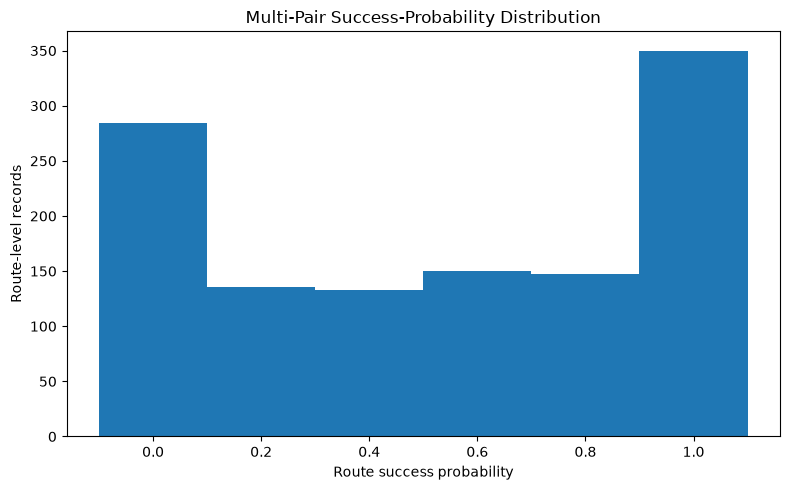

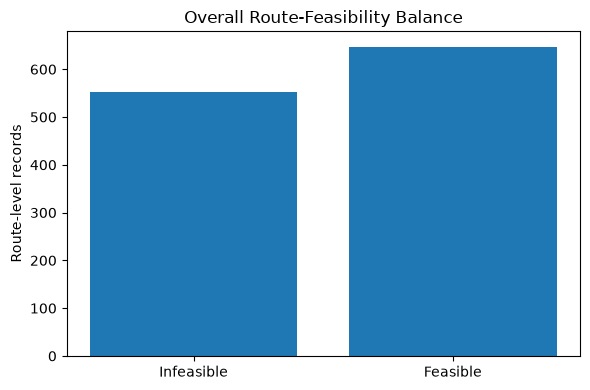

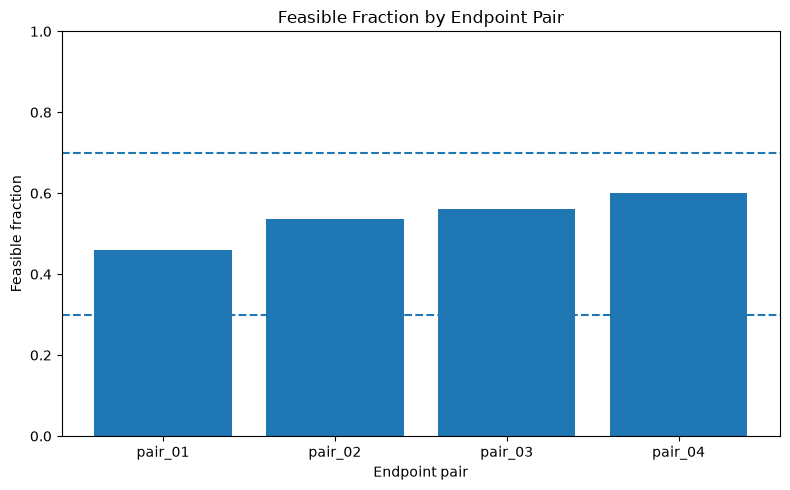

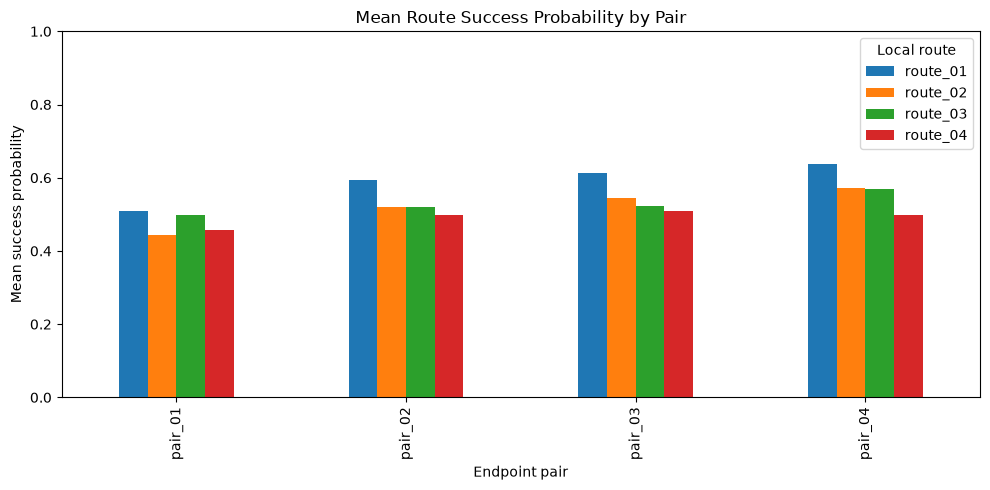


✓ TOP-QUALITY TRAINING DATASET PASSED
All integrity checks and required quality checks passed.
The dataset is ready for grouped classical and quantum kernel modelling.
Keep the unseen-topology test dataset untouched for final evaluation.

Audit JSON:
/content/drive/MyDrive/quantum_route_dataset/results/dataset_quality_audit.json

Quality-check CSV:
/content/drive/MyDrive/quantum_route_dataset/results/dataset_quality_checks.csv


In [ ]:

# ============================================================
# FINAL MULTI-PAIR DATASET VALIDATION AND AUDIT
# ============================================================

from __future__ import annotations

import json
import warnings
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


# ------------------------------------------------------------
# 1. Expected dimensions
# ------------------------------------------------------------

expected_rollout_rows = (
    N_SCENARIOS
    * N_ENDPOINT_PAIRS
    * N_CANDIDATE_ROUTES
    * ROLLOUTS_PER_ROUTE
)
expected_route_rows = (
    N_SCENARIOS
    * N_ENDPOINT_PAIRS
    * N_CANDIDATE_ROUTES
)
expected_best_route_rows = N_SCENARIOS * N_ENDPOINT_PAIRS
expected_route_definitions = N_ENDPOINT_PAIRS * N_CANDIDATE_ROUTES

assert expected_rollout_rows == EXPECTED_SIMULATIONS
assert expected_route_rows == EXPECTED_ROUTE_ROWS
assert expected_best_route_rows == EXPECTED_BEST_ROUTE_ROWS
assert expected_route_definitions == EXPECTED_ROUTE_DEFINITIONS


# ------------------------------------------------------------
# 2. Required objects and columns
# ------------------------------------------------------------

for name in [
    "rollout_df",
    "route_level_df",
    "best_route_df",
    "scenario_df",
    "candidate_route_records",
]:
    if name not in globals():
        raise NameError(
            f"{name} is unavailable. Run Cells 3–14 first."
        )

if rollout_df.empty or route_level_df.empty or best_route_df.empty:
    raise RuntimeError("A final dataset DataFrame is empty.")

required_columns = {
    "rollout_df": {
        "dataset_name", "dataset_version", "experiment_fingerprint",
        "topology_id", "scenario_id", "scenario_index", "split",
        "difficulty", "pair_id", "source", "destination", "route_id",
        "local_route_id", "route_number", "rollout_id",
        "reservation_approved", "path_match", "approved_path_string",
        "path_string", "end_to_end_success",
        "destination_requirement_met", "delivery_counter_consistent",
        "reservation_result_consistent", "wrong_remote_node_event_count",
        "simulation_error", "feasible_rollout", "failure_reason",
    },
    "route_level_df": {
        "dataset_name", "dataset_version", "experiment_fingerprint",
        "topology_id", "scenario_id", "scenario_index", "split",
        "difficulty", "pair_id", "source", "destination", "route_id",
        "local_route_id", "route_number", "rollout_count",
        "success_count", "success_probability", "success_standard_error",
        "success_probability_wilson_lower",
        "success_probability_wilson_upper",
        "approved_reservation_count", "path_match_rate",
        "simulation_error_count", "total_wrong_remote_node_events",
        "delivery_counter_consistency_rate",
        "reservation_result_consistency_rate", "feasible_label",
        "fidelity_margin_estimate", "deadline_margin_ms",
        "total_fibre_loss_db", "mean_setup_latency_ms",
        "mean_final_fidelity",
    },
    "best_route_df": {
        "dataset_name", "dataset_version", "experiment_fingerprint",
        "topology_id", "scenario_id", "scenario_index", "split",
        "difficulty", "pair_id", "source", "destination",
        "has_feasible_route", "selection_status", "feasible_route_count",
        "best_route_id", "best_local_route_id", "best_route_class",
        "best_route_label", "best_success_probability",
        "best_vs_second_success_margin", "primary_success_tie_count",
        "is_unique_primary_best", "fallback_route_id",
    },
}

for name, dataframe in [
    ("rollout_df", rollout_df),
    ("route_level_df", route_level_df),
    ("best_route_df", best_route_df),
]:
    missing = required_columns[name] - set(dataframe.columns)
    if missing:
        raise KeyError(
            f"{name} is missing columns:\n{sorted(missing)}"
        )


# ------------------------------------------------------------
# 3. Counts, keys, and provenance
# ------------------------------------------------------------

assert len(rollout_df) == expected_rollout_rows
assert len(route_level_df) == expected_route_rows
assert len(best_route_df) == expected_best_route_rows
assert len(candidate_route_records) == expected_route_definitions

rollout_key = ["scenario_id", "pair_id", "route_id", "rollout_id"]
route_key = ["scenario_id", "pair_id", "route_id"]
oracle_key = ["scenario_id", "pair_id"]

assert not rollout_df.duplicated(rollout_key, keep=False).any()
assert not route_level_df.duplicated(route_key, keep=False).any()
assert not best_route_df.duplicated(oracle_key, keep=False).any()


def single_value(
    dataframe: pd.DataFrame,
    column: str,
    expected: Any | None = None,
) -> Any:
    values = dataframe[column].dropna().unique()
    if len(values) != 1:
        raise RuntimeError(
            f"{column} must contain one value; found {values[:10]}."
        )
    value = values[0]
    if expected is not None and str(value) != str(expected):
        raise RuntimeError(
            f"{column}: expected {expected}, found {value}."
        )
    return value


dataset_name_value = single_value(
    rollout_df, "dataset_name", DATASET_NAME
)
dataset_version_value = single_value(
    rollout_df, "dataset_version", DATASET_VERSION
)
topology_id_value = single_value(
    rollout_df, "topology_id", TOPOLOGY_ID
)
fingerprint_value = single_value(
    rollout_df, "experiment_fingerprint"
)

for dataframe in [route_level_df, best_route_df]:
    single_value(dataframe, "dataset_name", dataset_name_value)
    single_value(dataframe, "dataset_version", dataset_version_value)
    single_value(dataframe, "topology_id", topology_id_value)
    single_value(
        dataframe,
        "experiment_fingerprint",
        fingerprint_value,
    )


# ------------------------------------------------------------
# 4. Coverage and split integrity
# ------------------------------------------------------------

assert rollout_df["scenario_id"].nunique() == N_SCENARIOS
assert rollout_df["pair_id"].nunique() == N_ENDPOINT_PAIRS
assert rollout_df["route_id"].nunique() == expected_route_definitions
assert route_level_df["scenario_id"].nunique() == N_SCENARIOS
assert route_level_df["pair_id"].nunique() == N_ENDPOINT_PAIRS
assert route_level_df["route_id"].nunique() == expected_route_definitions
assert best_route_df["scenario_id"].nunique() == N_SCENARIOS
assert best_route_df["pair_id"].nunique() == N_ENDPOINT_PAIRS

assert (
    rollout_df.groupby(route_key)["rollout_id"]
    .nunique()
    .eq(ROLLOUTS_PER_ROUTE)
    .all()
)

assert (
    route_level_df
    .groupby(["scenario_id", "pair_id"])["route_id"]
    .nunique()
    .eq(N_CANDIDATE_ROUTES)
    .all()
)

assert (
    route_level_df.groupby("scenario_id")["pair_id"]
    .nunique()
    .eq(N_ENDPOINT_PAIRS)
    .all()
)

assert (
    route_level_df.groupby("pair_id")["scenario_id"]
    .nunique()
    .eq(N_SCENARIOS)
    .all()
)

assert (
    route_level_df.groupby("scenario_id")["split"]
    .nunique()
    .eq(1)
    .all()
)

scenario_split_map = (
    route_level_df[["scenario_id", "split"]]
    .drop_duplicates()
)
train_scenarios = set(
    scenario_split_map.loc[
        scenario_split_map["split"].eq("train"),
        "scenario_id",
    ]
)
validation_scenarios = set(
    scenario_split_map.loc[
        scenario_split_map["split"].eq("validation"),
        "scenario_id",
    ]
)

assert train_scenarios.isdisjoint(validation_scenarios)
assert len(train_scenarios) + len(validation_scenarios) == N_SCENARIOS
assert validation_scenarios

difficulty_split_table = pd.crosstab(
    scenario_df["difficulty"],
    scenario_df["split"],
).reindex(
    ["easy", "moderate", "hard"],
    fill_value=0,
)


# ------------------------------------------------------------
# 5. Simulator, route, and telemetry integrity
# ------------------------------------------------------------

simulation_errors = rollout_df.loc[
    rollout_df["simulation_error"].eq(1)
].copy()
assert simulation_errors.empty

approved_rollouts = rollout_df.loc[
    rollout_df["reservation_approved"].eq(1)
].copy()
rejected_rollouts = rollout_df.loc[
    rollout_df["reservation_approved"].eq(0)
].copy()

approved_path_mismatches = approved_rollouts.loc[
    ~approved_rollouts["path_match"].eq(1)
].copy()
assert approved_path_mismatches.empty

approved_path_string_mismatches = approved_rollouts.loc[
    approved_rollouts["approved_path_string"].ne(
        approved_rollouts["path_string"]
    )
]
assert approved_path_string_mismatches.empty

wrong_remote_event_total = int(
    rollout_df["wrong_remote_node_event_count"].sum()
)
assert wrong_remote_event_total == 0
assert rollout_df["delivery_counter_consistent"].eq(1).all()
assert rollout_df["reservation_result_consistent"].eq(1).all()

successful_rollouts = rollout_df.loc[
    rollout_df["end_to_end_success"].eq(1)
]
assert successful_rollouts[
    "destination_requirement_met"
].eq(1).all()


# ------------------------------------------------------------
# 6. Route-level label integrity
# ------------------------------------------------------------

assert route_level_df["rollout_count"].eq(
    ROLLOUTS_PER_ROUTE
).all()

calculated_probability = (
    route_level_df["success_count"]
    / route_level_df["rollout_count"]
)
assert np.allclose(
    route_level_df["success_probability"],
    calculated_probability,
)

calculated_label = (
    route_level_df["success_probability"]
    .ge(FEASIBILITY_THRESHOLD)
    .astype(int)
)
assert route_level_df["feasible_label"].eq(calculated_label).all()

for column in [
    "success_probability",
    "success_probability_wilson_lower",
    "success_probability_wilson_upper",
]:
    assert route_level_df[column].between(0, 1).all()

assert (
    route_level_df["success_probability_wilson_lower"]
    <= route_level_df["success_probability_wilson_upper"]
).all()

invalid_path_match_rates = route_level_df.loc[
    route_level_df["approved_reservation_count"].gt(0)
    & ~np.isclose(
        route_level_df["path_match_rate"],
        1.0,
        equal_nan=False,
    )
]
assert invalid_path_match_rates.empty

all_rejected_rows = route_level_df[
    "approved_reservation_count"
].eq(0)
assert route_level_df.loc[
    all_rejected_rows,
    "path_match_rate",
].isna().all()

assert route_level_df["simulation_error_count"].eq(0).all()
assert route_level_df["total_wrong_remote_node_events"].eq(0).all()
assert route_level_df[
    "delivery_counter_consistency_rate"
].eq(1).all()
assert route_level_df[
    "reservation_result_consistency_rate"
].eq(1).all()


# ------------------------------------------------------------
# 7. Oracle-label integrity
# ------------------------------------------------------------

assert best_route_df["has_feasible_route"].isin([0, 1]).all()
assert best_route_df[
    "best_route_class"
].isin([-1, 0, 1, 2, 3]).all()

selected_oracles = best_route_df.loc[
    best_route_df["has_feasible_route"].eq(1)
].copy()
no_feasible_oracles = best_route_df.loc[
    best_route_df["has_feasible_route"].eq(0)
].copy()

assert selected_oracles["best_route_id"].ne(
    "NO_FEASIBLE_ROUTE"
).all()
assert no_feasible_oracles["best_route_id"].eq(
    "NO_FEASIBLE_ROUTE"
).all()
assert no_feasible_oracles["best_route_class"].eq(-1).all()

selected_check = selected_oracles[
    ["scenario_id", "pair_id", "best_route_id"]
].merge(
    route_level_df[
        ["scenario_id", "pair_id", "route_id", "feasible_label"]
    ],
    left_on=["scenario_id", "pair_id", "best_route_id"],
    right_on=["scenario_id", "pair_id", "route_id"],
    how="left",
    validate="one_to_one",
)
assert selected_check["feasible_label"].eq(1).all()

group_feasible_counts = (
    route_level_df
    .groupby(["scenario_id", "pair_id"])["feasible_label"]
    .sum()
    .rename("actual_feasible_count")
    .reset_index()
)
no_feasible_check = no_feasible_oracles.merge(
    group_feasible_counts,
    on=["scenario_id", "pair_id"],
    how="left",
    validate="one_to_one",
)
assert no_feasible_check["actual_feasible_count"].eq(0).all()


# ------------------------------------------------------------
# 8. Candidate model-feature audit
# ------------------------------------------------------------

AUDIT_MODEL_FEATURES = [
    "hop_count",
    "total_fibre_loss_db",
    "maximum_link_loss_db",
    "bottleneck_link_success_estimate",
    "effective_efficiency",
    "fidelity_margin_estimate",
    "deadline_margin_ms",
    "route_degraded_link_fraction",
    "route_contains_hotspot",
    "min_memory_requirement_margin",
    "mean_reservation_occupancy_pre",
    "coherence_time_s",
]

missing_features = set(AUDIT_MODEL_FEATURES) - set(
    route_level_df.columns
)
assert not missing_features, (
    f"Missing model features: {sorted(missing_features)}"
)

feature_values = route_level_df[
    AUDIT_MODEL_FEATURES
].apply(
    pd.to_numeric,
    errors="coerce",
)
assert feature_values.notna().all().all()
assert np.isfinite(feature_values.to_numpy()).all()

forbidden_model_features = {
    "scenario_id", "pair_id", "source", "destination",
    "route_id", "local_route_id", "topology_id",
    "split", "difficulty", "success_count",
    "success_probability", "reservation_acceptance_rate",
    "path_match_rate", "mean_pairs_created",
    "mean_final_fidelity", "mean_setup_latency_ms",
    "feasible_label", "failure_reason",
    "best_route_id", "best_route_class",
}

if "MODEL_FEATURES" in globals():
    leakage_features = set(MODEL_FEATURES) & forbidden_model_features
    assert not leakage_features, (
        "MODEL_FEATURES contains leakage/identifiers: "
        f"{sorted(leakage_features)}"
    )

constant_features = (
    feature_values
    .nunique(dropna=False)
    .loc[lambda values: values.le(1)]
    .index
    .tolist()
)

correlation_matrix = feature_values.corr()
high_correlation_pairs = []

for index, feature_1 in enumerate(AUDIT_MODEL_FEATURES):
    for feature_2 in AUDIT_MODEL_FEATURES[index + 1:]:
        correlation = float(
            correlation_matrix.loc[feature_1, feature_2]
        )
        if np.isfinite(correlation) and abs(correlation) >= 0.95:
            high_correlation_pairs.append(
                {
                    "feature_1": feature_1,
                    "feature_2": feature_2,
                    "correlation": correlation,
                }
            )

high_correlation_df = pd.DataFrame(high_correlation_pairs)


# ------------------------------------------------------------
# 9. Summary tables and simple-rule diagnostics
# ------------------------------------------------------------

def balance_table(
    grouping_column: str,
    ordered_index: list[str] | None = None,
) -> pd.DataFrame:
    table = pd.crosstab(
        route_level_df[grouping_column],
        route_level_df["feasible_label"],
    ).reindex(
        columns=[0, 1],
        fill_value=0,
    ).rename(
        columns={0: "infeasible", 1: "feasible"}
    )

    if ordered_index is not None:
        table = table.reindex(ordered_index, fill_value=0)

    total = table["infeasible"] + table["feasible"]
    table["feasible_fraction"] = table["feasible"] / total
    return table


error_rate = float(rollout_df["simulation_error"].mean())

class_balance = (
    route_level_df["feasible_label"]
    .value_counts()
    .reindex([0, 1], fill_value=0)
    .rename(index={0: "infeasible", 1: "feasible"})
)
feasible_fraction = float(
    route_level_df["feasible_label"].mean()
)
infeasible_fraction = 1.0 - feasible_fraction

class_balance_by_pair = balance_table("pair_id")
class_balance_by_difficulty = balance_table(
    "difficulty",
    ["easy", "moderate", "hard"],
)
class_balance_by_split = balance_table("split")
class_balance_by_local_route = balance_table("local_route_id")

failure_reason_summary = (
    rollout_df["failure_reason"]
    .value_counts(dropna=False)
)
success_probability_distribution = (
    route_level_df["success_probability"]
    .value_counts()
    .sort_index()
)
unique_probability_count = int(
    route_level_df["success_probability"].nunique()
)
intermediate_probability_count = int(
    route_level_df["success_probability"]
    .between(0, 1, inclusive="neither")
    .sum()
)
intermediate_probability_fraction = (
    intermediate_probability_count / len(route_level_df)
)

route_summary_by_pair = (
    route_level_df
    .groupby(["pair_id", "local_route_id"], as_index=False)
    .agg(
        source=("source", "first"),
        destination=("destination", "first"),
        mean_success_probability=("success_probability", "mean"),
        median_success_probability=("success_probability", "median"),
        feasible_rate=("feasible_label", "mean"),
        mean_fibre_loss_db=("total_fibre_loss_db", "mean"),
        mean_setup_latency_ms=("mean_setup_latency_ms", "mean"),
    )
)

fidelity_only_agreement = float(
    route_level_df["fidelity_margin_estimate"]
    .ge(0)
    .astype(int)
    .eq(route_level_df["feasible_label"])
    .mean()
)
deadline_only_agreement = float(
    route_level_df["deadline_margin_ms"]
    .ge(0)
    .astype(int)
    .eq(route_level_df["feasible_label"])
    .mean()
)
two_margin_agreement = float(
    (
        route_level_df["fidelity_margin_estimate"].ge(0)
        & route_level_df["deadline_margin_ms"].ge(0)
    )
    .astype(int)
    .eq(route_level_df["feasible_label"])
    .mean()
)


# ------------------------------------------------------------
# 10. Oracle diversity and uncertainty
# ------------------------------------------------------------

feasible_oracle_df = best_route_df.loc[
    best_route_df["has_feasible_route"].eq(1)
].copy()

no_feasible_route_fraction = float(
    best_route_df["has_feasible_route"].eq(0).mean()
)

best_local_route_distribution = (
    feasible_oracle_df["best_local_route_id"]
    .value_counts()
)

oracle_pair_rows = []

for pair_id, group in best_route_df.groupby("pair_id"):
    feasible_group = group.loc[
        group["has_feasible_route"].eq(1)
    ]

    if feasible_group.empty:
        distinct_routes = 0
        dominant_route = ""
        dominant_fraction = np.nan
    else:
        distribution = (
            feasible_group["best_local_route_id"]
            .value_counts()
        )
        distinct_routes = int(distribution.size)
        dominant_route = str(distribution.index[0])
        dominant_fraction = float(
            distribution.max() / len(feasible_group)
        )

    oracle_pair_rows.append(
        {
            "pair_id": str(pair_id),
            "scenario_pair_groups": int(len(group)),
            "groups_with_feasible_route": int(len(feasible_group)),
            "groups_without_feasible_route": int(
                group["has_feasible_route"].eq(0).sum()
            ),
            "distinct_best_local_routes": distinct_routes,
            "dominant_best_local_route": dominant_route,
            "dominant_best_route_fraction": dominant_fraction,
        }
    )

oracle_pair_quality_df = pd.DataFrame(oracle_pair_rows)

primary_tie_fraction = float(
    best_route_df["primary_success_tie_count"].gt(1).mean()
)
unique_primary_best_fraction = float(
    best_route_df["is_unique_primary_best"].eq(1).mean()
)

wilson_width = (
    route_level_df["success_probability_wilson_upper"]
    - route_level_df["success_probability_wilson_lower"]
)
mean_wilson_width = float(wilson_width.mean())
median_wilson_width = float(wilson_width.median())


# ------------------------------------------------------------
# 11. Quality checklist
# ------------------------------------------------------------

quality_checks = []


def add_check(
    name: str,
    passed: bool,
    observed: Any,
    criterion: str,
    severity: str = "required",
) -> None:
    quality_checks.append(
        {
            "check": name,
            "passed": bool(passed),
            "observed": observed,
            "criterion": criterion,
            "severity": severity,
        }
    )


add_check(
    "overall_class_balance",
    0.30 <= feasible_fraction <= 0.70,
    round(feasible_fraction, 4),
    "overall feasible fraction must be 0.30–0.70",
)
add_check(
    "pair_level_class_balance",
    class_balance_by_pair["feasible_fraction"]
    .between(0.20, 0.80)
    .all(),
    class_balance_by_pair["feasible_fraction"]
    .round(4)
    .to_dict(),
    "each endpoint pair should be 0.20–0.80 feasible",
)
add_check(
    "split_level_class_balance",
    class_balance_by_split["feasible_fraction"]
    .between(0.20, 0.80)
    .all(),
    class_balance_by_split["feasible_fraction"]
    .round(4)
    .to_dict(),
    "train and validation should each be 0.20–0.80 feasible",
)

moderate_counts = class_balance_by_difficulty.loc["moderate"]
add_check(
    "moderate_scenarios_have_both_classes",
    (
        moderate_counts["infeasible"] > 0
        and moderate_counts["feasible"] > 0
    ),
    {
        "infeasible": int(moderate_counts["infeasible"]),
        "feasible": int(moderate_counts["feasible"]),
    },
    "moderate scenarios must contain both labels",
)
add_check(
    "probability_resolution",
    unique_probability_count >= 4,
    unique_probability_count,
    "at least four success-probability levels",
)
add_check(
    "stochastic_boundary_coverage",
    intermediate_probability_fraction >= 0.10,
    round(intermediate_probability_fraction, 4),
    "at least 10% of rows should have 0 < probability < 1",
)
add_check(
    "fidelity_not_dominant",
    fidelity_only_agreement < 0.85,
    round(fidelity_only_agreement, 4),
    "fidelity-only agreement must be below 0.85",
)
add_check(
    "deadline_not_dominant",
    deadline_only_agreement < 0.85,
    round(deadline_only_agreement, 4),
    "deadline-only agreement must be below 0.85",
)
add_check(
    "combined_margin_not_trivial",
    two_margin_agreement < 0.90,
    round(two_margin_agreement, 4),
    "combined fidelity/deadline agreement must be below 0.90",
)

oracle_diversity_passed = (
    oracle_pair_quality_df["groups_with_feasible_route"].gt(0)
    & oracle_pair_quality_df["distinct_best_local_routes"].ge(2)
    & oracle_pair_quality_df[
        "dominant_best_route_fraction"
    ].le(0.80)
).all()

add_check(
    "oracle_route_diversity_by_pair",
    oracle_diversity_passed,
    oracle_pair_quality_df[
        [
            "pair_id",
            "distinct_best_local_routes",
            "dominant_best_route_fraction",
        ]
    ]
    .round(4)
    .to_dict(orient="records"),
    "every pair must use at least two best local routes "
    "and have no route above 80%",
)
add_check(
    "no_feasible_route_fraction",
    no_feasible_route_fraction <= 0.50,
    round(no_feasible_route_fraction, 4),
    "NO_FEASIBLE_ROUTE must be at most 50%",
)
add_check(
    "constant_candidate_features",
    len(constant_features) == 0,
    constant_features,
    "candidate model features must not be constant",
)
add_check(
    "primary_tie_rate",
    primary_tie_fraction <= 0.60,
    round(primary_tie_fraction, 4),
    "primary probability ties should be <= 60%",
    severity="advisory",
)
add_check(
    "high_input_correlation",
    len(high_correlation_pairs) == 0,
    high_correlation_pairs,
    "no candidate feature pair should have |r| >= 0.95",
    severity="advisory",
)

quality_check_df = pd.DataFrame(quality_checks)
required_checks = quality_check_df.loc[
    quality_check_df["severity"].eq("required")
]
dataset_quality_ready = bool(required_checks["passed"].all())

for failed in quality_check_df.loc[
    ~quality_check_df["passed"]
].itertuples():
    warnings.warn(
        f"{failed.check} failed. "
        f"Observed={failed.observed}. "
        f"Criterion={failed.criterion}.",
        RuntimeWarning,
    )


# ------------------------------------------------------------
# 12. Save audit outputs
# ------------------------------------------------------------

DATASET_AUDIT_JSON_PATH = (
    RESULTS_DIR / "dataset_quality_audit.json"
)
QUALITY_CHECK_CSV_PATH = (
    RESULTS_DIR / "dataset_quality_checks.csv"
)
CLASS_BALANCE_PAIR_CSV_PATH = (
    RESULTS_DIR / "class_balance_by_pair.csv"
)
CLASS_BALANCE_DIFFICULTY_CSV_PATH = (
    RESULTS_DIR / "class_balance_by_difficulty.csv"
)
CLASS_BALANCE_SPLIT_CSV_PATH = (
    RESULTS_DIR / "class_balance_by_split.csv"
)
ROUTE_SUMMARY_PAIR_CSV_PATH = (
    RESULTS_DIR / "route_summary_by_pair.csv"
)
ORACLE_PAIR_QUALITY_CSV_PATH = (
    RESULTS_DIR / "oracle_pair_quality.csv"
)
HIGH_CORRELATION_CSV_PATH = (
    RESULTS_DIR / "high_feature_correlations.csv"
)


def save_csv(
    dataframe: pd.DataFrame,
    destination: Path,
) -> None:
    if "atomic_write_csv" in globals():
        atomic_write_csv(dataframe, destination)
    else:
        dataframe.to_csv(destination, index=False)


save_csv(quality_check_df, QUALITY_CHECK_CSV_PATH)
save_csv(
    class_balance_by_pair.reset_index(),
    CLASS_BALANCE_PAIR_CSV_PATH,
)
save_csv(
    class_balance_by_difficulty.reset_index(),
    CLASS_BALANCE_DIFFICULTY_CSV_PATH,
)
save_csv(
    class_balance_by_split.reset_index(),
    CLASS_BALANCE_SPLIT_CSV_PATH,
)
save_csv(route_summary_by_pair, ROUTE_SUMMARY_PAIR_CSV_PATH)
save_csv(oracle_pair_quality_df, ORACLE_PAIR_QUALITY_CSV_PATH)
save_csv(high_correlation_df, HIGH_CORRELATION_CSV_PATH)

audit_payload = {
    "dataset_name": str(dataset_name_value),
    "dataset_version": str(dataset_version_value),
    "topology_id": str(topology_id_value),
    "experiment_fingerprint": str(fingerprint_value),
    "rollout_rows": int(len(rollout_df)),
    "route_level_rows": int(len(route_level_df)),
    "best_route_rows": int(len(best_route_df)),
    "scenario_count": int(N_SCENARIOS),
    "endpoint_pair_count": int(N_ENDPOINT_PAIRS),
    "route_definition_count": int(expected_route_definitions),
    "rollouts_per_route": int(ROLLOUTS_PER_ROUTE),
    "simulation_errors": int(len(simulation_errors)),
    "approved_path_mismatches": int(
        len(approved_path_mismatches)
    ),
    "wrong_remote_node_events": int(wrong_remote_event_total),
    "feasible_fraction": float(feasible_fraction),
    "intermediate_probability_fraction": float(
        intermediate_probability_fraction
    ),
    "fidelity_only_agreement": float(fidelity_only_agreement),
    "deadline_only_agreement": float(deadline_only_agreement),
    "two_margin_agreement": float(two_margin_agreement),
    "no_feasible_route_fraction": float(
        no_feasible_route_fraction
    ),
    "primary_tie_fraction": float(primary_tie_fraction),
    "mean_wilson_interval_width": float(mean_wilson_width),
    "median_wilson_interval_width": float(
        median_wilson_width
    ),
    "constant_candidate_features": constant_features,
    "high_correlation_pairs": high_correlation_pairs,
    "dataset_quality_ready": bool(dataset_quality_ready),
    "quality_checks": quality_check_df.to_dict(
        orient="records"
    ),
}

if "atomic_write_json" in globals():
    atomic_write_json(audit_payload, DATASET_AUDIT_JSON_PATH)
else:
    with DATASET_AUDIT_JSON_PATH.open(
        "w",
        encoding="utf-8",
    ) as file:
        json.dump(
            audit_payload,
            file,
            indent=2,
            default=str,
        )


# ------------------------------------------------------------
# 13. Reports
# ------------------------------------------------------------

print("=" * 96)
print("FINAL MULTI-PAIR DATASET INTEGRITY VALIDATION")
print("=" * 96)
print(f"Dataset name             : {dataset_name_value}")
print(f"Dataset version          : {dataset_version_value}")
print(f"Topology ID              : {topology_id_value}")
print(
    "Experiment fingerprint  : "
    f"{str(fingerprint_value)[:16]}"
)
print(
    f"Rollout rows             : "
    f"{len(rollout_df):,} / {expected_rollout_rows:,}"
)
print(
    f"Route-level rows         : "
    f"{len(route_level_df):,} / {expected_route_rows:,}"
)
print(
    f"Oracle-label rows        : "
    f"{len(best_route_df):,} / {expected_best_route_rows:,}"
)
print(f"Scenarios                : {N_SCENARIOS}")
print(f"Endpoint pairs           : {N_ENDPOINT_PAIRS}")
print(f"Route definitions        : {expected_route_definitions}")
print(f"Rollouts per route       : {ROLLOUTS_PER_ROUTE}")
print(f"Training scenarios       : {len(train_scenarios)}")
print(
    f"Validation scenarios     : {len(validation_scenarios)}"
)
print(
    f"Approved reservations    : {len(approved_rollouts):,}"
)
print(
    f"Rejected reservations    : {len(rejected_rollouts):,}"
)
print(
    f"Approved path mismatches : "
    f"{len(approved_path_mismatches)}"
)
print(f"Wrong-remote events      : {wrong_remote_event_total}")
print(f"Simulator errors         : {len(simulation_errors)}")
print(f"Simulation error rate    : {error_rate:.3%}")

print("\nDifficulty by split:")
print(difficulty_split_table.to_string())
print("\nFailure reasons:")
print(failure_reason_summary.to_string())
print("=" * 96)

print("\n" + "=" * 96)
print("DATASET QUALITY AND CALIBRATION DIAGNOSTICS")
print("=" * 96)
print(f"Feasible fraction          : {feasible_fraction:.4f}")
print(f"Infeasible fraction        : {infeasible_fraction:.4f}")
print(f"Probability levels         : {unique_probability_count}")
print(
    f"Intermediate rows          : "
    f"{intermediate_probability_count:,} "
    f"({intermediate_probability_fraction:.2%})"
)
print(
    f"Fidelity-only agreement    : "
    f"{fidelity_only_agreement:.4f}"
)
print(
    f"Deadline-only agreement    : "
    f"{deadline_only_agreement:.4f}"
)
print(f"Two-margin agreement       : {two_margin_agreement:.4f}")
print(
    f"No-feasible-route fraction : "
    f"{no_feasible_route_fraction:.4f}"
)
print(f"Primary tie fraction       : {primary_tie_fraction:.4f}")
print(
    f"Unique primary-best rate   : "
    f"{unique_primary_best_fraction:.4f}"
)
print(f"Mean Wilson width          : {mean_wilson_width:.4f}")
print(f"Median Wilson width        : {median_wilson_width:.4f}")
print(f"Constant input features    : {constant_features}")
print(
    f"High-correlation pairs     : "
    f"{len(high_correlation_pairs)}"
)

print("\nOverall class balance:")
print(class_balance.to_string())
print("\nClass balance by pair:")
print(class_balance_by_pair.to_string())
print("\nClass balance by difficulty:")
print(class_balance_by_difficulty.to_string())
print("\nClass balance by split:")
print(class_balance_by_split.to_string())
print("\nClass balance by local route:")
print(class_balance_by_local_route.to_string())
print("\nSuccess-probability distribution:")
print(success_probability_distribution.to_string())
print("\nFeasible oracle-best local routes:")
print(best_local_route_distribution.to_string())
print("\nOracle diversity by pair:")
print(oracle_pair_quality_df.to_string(index=False))
print("\nQuality checks:")
display(quality_check_df)
print("\nRoute performance by pair:")
display(route_summary_by_pair)

if not high_correlation_df.empty:
    print("\nCandidate feature correlations with |r| >= 0.95:")
    display(high_correlation_df)

print("=" * 96)


# ------------------------------------------------------------
# 14. Plots
# ------------------------------------------------------------

probability_step = 1.0 / ROLLOUTS_PER_ROUTE
histogram_edges = np.arange(
    -probability_step / 2,
    1.0 + probability_step,
    probability_step,
)

plt.figure(figsize=(8, 5))
plt.hist(
    route_level_df["success_probability"],
    bins=histogram_edges,
)
plt.xticks(
    np.arange(
        0,
        1.0 + probability_step,
        probability_step,
    )
)
plt.xlabel("Route success probability")
plt.ylabel("Route-level records")
plt.title("Multi-Pair Success-Probability Distribution")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.bar(
    ["Infeasible", "Feasible"],
    [
        int(class_balance["infeasible"]),
        int(class_balance["feasible"]),
    ],
)
plt.ylabel("Route-level records")
plt.title("Overall Route-Feasibility Balance")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(
    class_balance_by_pair.index.astype(str),
    class_balance_by_pair["feasible_fraction"],
)
plt.ylim(0, 1)
plt.axhline(0.30, linestyle="--")
plt.axhline(0.70, linestyle="--")
plt.xlabel("Endpoint pair")
plt.ylabel("Feasible fraction")
plt.title("Feasible Fraction by Endpoint Pair")
plt.tight_layout()
plt.show()

route_plot_table = route_summary_by_pair.pivot(
    index="pair_id",
    columns="local_route_id",
    values="mean_success_probability",
)
route_plot_table.plot(
    kind="bar",
    figsize=(10, 5),
)
plt.ylim(0, 1)
plt.xlabel("Endpoint pair")
plt.ylabel("Mean success probability")
plt.title("Mean Route Success Probability by Pair")
plt.legend(title="Local route")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 15. Final decision
# ------------------------------------------------------------

print("\n" + "=" * 96)

if dataset_quality_ready:
    print("✓ TOP-QUALITY TRAINING DATASET PASSED")
    print(
        "All integrity checks and required quality checks passed."
    )
    print(
        "The dataset is ready for grouped classical and "
        "quantum kernel modelling."
    )
    print(
        "Keep the unseen-topology test dataset untouched "
        "for final evaluation."
    )
else:
    print(
        "△ DATASET INTEGRITY PASSED, BUT QUALITY NEEDS REVIEW"
    )
    print(
        "At least one required quality check failed. "
        "Inspect quality_check_df before final model training."
    )

print(f"\nAudit JSON:\n{DATASET_AUDIT_JSON_PATH}")
print(f"\nQuality-check CSV:\n{QUALITY_CHECK_CSV_PATH}")
print("=" * 96)


## Create the leakage-safe model-ready feature dataset

**Purpose:** define the input schema shared by classical and quantum machine-learning models.

This section:

- constructs scenario and ranking group identifiers;
- defines the primary, compact, and extended feature sets;
- separates identifiers and post-simulation outcomes from legitimate pre-routing inputs;
- checks numeric types, missing values, infinite values, constants, and correlations;
- validates the binary and probability targets;
- saves the complete model-ready dataset and feature manifest.

**Fair-comparison rule:** classical and quantum models must use the same feature order, preprocessing fitted on training data only, grouped splits, and target labels.


In [ ]:
# ============================================================
# MODEL-READY FEATURE DEFINITION AND VALIDATION
#
# Purpose:
#   - define a leakage-free feature set
#   - use identical inputs for classical and quantum kernels
#   - create scenario-level grouping identifiers
#   - validate missing, infinite, and constant features
#   - save a clean model-ready route-feasibility dataset
#
# Main supervised task:
#   X -> feasible_label
#
# Secondary regression/probability task:
#   X -> success_probability
# ============================================================

from __future__ import annotations

import json
from pathlib import Path

import numpy as np
import pandas as pd


# ------------------------------------------------------------
# 1. Confirm that the route-level dataset exists
# ------------------------------------------------------------

if "route_level_df" not in globals():
    raise NameError(
        "route_level_df is unavailable. "
        "Run the preceding section before the preceding section."
    )

if route_level_df.empty:
    raise RuntimeError(
        "route_level_df is empty."
    )

route_level_df = route_level_df.copy()


# ------------------------------------------------------------
# 2. Create derived pre-routing features when needed
# ------------------------------------------------------------
#
# These features use only information available before
# executing the route. They do not contain simulation outcomes.

if (
    "effective_efficiency"
    not in route_level_df.columns
):

    route_level_df[
        "effective_efficiency"
    ] = (
        route_level_df[
            "memory_efficiency"
        ]
        * route_level_df[
            "detector_efficiency"
        ]
    )


if (
    "scenario_group_id"
    not in route_level_df.columns
):

    route_level_df[
        "scenario_group_id"
    ] = (
        route_level_df[
            "topology_id"
        ].astype(str)
        + "::"
        + route_level_df[
            "scenario_id"
        ].astype(str)
    )


if (
    "ranking_group_id"
    not in route_level_df.columns
):

    route_level_df[
        "ranking_group_id"
    ] = (
        route_level_df[
            "topology_id"
        ].astype(str)
        + "::"
        + route_level_df[
            "scenario_id"
        ].astype(str)
        + "::"
        + route_level_df[
            "pair_id"
        ].astype(str)
    )


# ------------------------------------------------------------
# 3. Core feature set for the primary paper comparison
# ------------------------------------------------------------
#
# Use this same feature set for:
#
#   - linear SVM
#   - RBF SVM
#   - polynomial-kernel SVM
#   - classical kernel ridge/logistic models
#   - quantum kernel SVM
#
# Keeping the same input variables is essential for a fair
# classical-versus-quantum kernel comparison.

CORE_MODEL_FEATURES = [
    # Route complexity
    "hop_count",

    # Optical quality
    "total_fibre_loss_db",
    "maximum_link_loss_db",
    "bottleneck_link_success_estimate",

    # Resource availability
    "min_memory_requirement_margin",
    "mean_reservation_occupancy_pre",

    # Requirement margins
    "fidelity_margin_estimate",
    "deadline_margin_ms",

    # Dynamic route exposure
    "route_degraded_link_fraction",
    "route_contains_hotspot",

    # Hardware condition
    "effective_efficiency",
    "coherence_time_s",
]


# ------------------------------------------------------------
# 4. Compact feature set for limited-qubit experiments
# ------------------------------------------------------------
#
# This eight-feature set is useful when the quantum feature map
# or simulator becomes expensive.
#
# It should be treated as a predefined secondary experiment,
# not selected after observing test-set performance.

COMPACT_QUANTUM_FEATURES = [
    "hop_count",
    "total_fibre_loss_db",
    "maximum_link_loss_db",
    "bottleneck_link_success_estimate",
    "min_memory_requirement_margin",
    "fidelity_margin_estimate",
    "deadline_margin_ms",
    "effective_efficiency",
]


# ------------------------------------------------------------
# 5. Optional extended feature set for ablation analysis
# ------------------------------------------------------------

EXTENDED_MODEL_FEATURES = [
    "hop_count",
    "swap_count",
    "total_distance_km",
    "maximum_link_distance_km",

    "total_fibre_loss_db",
    "maximum_link_loss_db",
    "mean_link_loss_db",
    "minimum_link_transmission_probability",
    "bottleneck_link_success_estimate",

    "memory_efficiency",
    "detector_efficiency",
    "effective_efficiency",
    "coherence_time_s",

    "estimated_final_fidelity",
    "fidelity_margin_estimate",
    "estimated_latency_ms",
    "deadline_margin_ms",

    "route_degraded_link_count",
    "route_degraded_link_fraction",

    "route_contains_hotspot",
    "hotspot_is_source",
    "hotspot_is_destination",
    "hotspot_is_intermediate",

    "min_memory_requirement_margin",
    "mean_reservation_occupancy_pre",
    "route_blocked_memories_total",
]


# ------------------------------------------------------------
# 6. Targets and grouping fields
# ------------------------------------------------------------

TARGET_CLASSIFICATION = (
    "feasible_label"
)

TARGET_PROBABILITY = (
    "success_probability"
)

# Used for grouped train/validation or grouped cross-validation.
#
# All endpoint pairs and candidate routes belonging to the same
# network scenario must remain in the same fold.
GROUP_COLUMN = (
    "scenario_group_id"
)

# Used for route-ranking evaluation.
#
# Each ranking group contains the four routes belonging to one
# scenario-endpoint pair.
RANKING_GROUP_COLUMN = (
    "ranking_group_id"
)

STRATIFICATION_COLUMNS = [
    "pair_id",
    "difficulty",
    "split",
]


# ------------------------------------------------------------
# 7. Non-feature identity columns
# ------------------------------------------------------------

IDENTITY_COLUMNS = [
    "dataset_name",
    "dataset_version",
    "experiment_fingerprint",
    "topology_id",
    "scenario_id",
    "scenario_index",
    "scenario_group_id",
    "pair_id",
    "source",
    "destination",
    "endpoint_pair_string",
    "ranking_group_id",
    "route_id",
    "local_route_id",
    "route_number",
    "path_string",
    "split",
    "difficulty",
]


# ------------------------------------------------------------
# 8. Explicit leakage and post-execution outcome columns
# ------------------------------------------------------------
#
# None of these may be supplied to either the classical or
# quantum kernel model.

OUTCOME_AND_LEAKAGE_COLUMNS = [
    "success_count",
    "success_probability",
    "success_standard_error",
    "success_probability_wilson_lower",
    "success_probability_wilson_upper",
    "feasibility_probability_margin",
    "feasible_label",

    "reservation_acceptance_rate",
    "path_match_rate",
    "end_to_end_success_rate",

    "total_pairs_created",
    "mean_pairs_created",
    "median_pairs_created",
    "standard_deviation_pairs_created",

    "mean_final_fidelity",
    "mean_maximum_final_fidelity",
    "maximum_observed_fidelity",
    "minimum_observed_fidelity",

    "mean_setup_latency_ms",
    "median_setup_latency_ms",
    "standard_deviation_setup_latency_ms",
    "minimum_setup_latency_ms",
    "maximum_setup_latency_ms",

    "mean_delivered_pair_rate_hz",
    "median_delivered_pair_rate_hz",

    "fidelity_requirement_rate",
    "deadline_requirement_rate",

    "approved_reservation_count",
    "successful_delivery_rollout_count",

    "simulation_error_count",
    "simulation_error_rate",

    "success_count",
    "reservation_rejected_count",
    "path_mismatch_count",
    "no_end_to_end_entanglement_count",
    "fidelity_not_met_count",
    "deadline_exceeded_count",
]


# ------------------------------------------------------------
# 9. Confirm required columns exist
# ------------------------------------------------------------

required_columns = set(
    CORE_MODEL_FEATURES
    + COMPACT_QUANTUM_FEATURES
    + [
        TARGET_CLASSIFICATION,
        TARGET_PROBABILITY,
        GROUP_COLUMN,
        RANKING_GROUP_COLUMN,
        "scenario_id",
        "pair_id",
        "route_id",
        "split",
        "difficulty",
    ]
)

missing_required_columns = (
    required_columns
    - set(route_level_df.columns)
)

if missing_required_columns:
    raise KeyError(
        "The route-level dataset is missing required "
        "feature or target columns:\n"
        f"{sorted(missing_required_columns)}"
    )


# ------------------------------------------------------------
# 10. Confirm feature sets contain no leakage
# ------------------------------------------------------------

core_leakage_overlap = (
    set(CORE_MODEL_FEATURES)
    & set(OUTCOME_AND_LEAKAGE_COLUMNS)
)

compact_leakage_overlap = (
    set(COMPACT_QUANTUM_FEATURES)
    & set(OUTCOME_AND_LEAKAGE_COLUMNS)
)

assert not core_leakage_overlap, (
    "The core feature set contains outcome leakage: "
    f"{sorted(core_leakage_overlap)}"
)

assert not compact_leakage_overlap, (
    "The compact feature set contains outcome leakage: "
    f"{sorted(compact_leakage_overlap)}"
)


# ------------------------------------------------------------
# 11. Validate numeric feature types
# ------------------------------------------------------------

for feature_name in set(
    CORE_MODEL_FEATURES
    + COMPACT_QUANTUM_FEATURES
    + EXTENDED_MODEL_FEATURES
):

    if feature_name not in route_level_df.columns:
        continue

    route_level_df[
        feature_name
    ] = pd.to_numeric(
        route_level_df[
            feature_name
        ],
        errors="coerce",
    )


# ------------------------------------------------------------
# 12. Check missing values
# ------------------------------------------------------------

core_missing_counts = (
    route_level_df[
        CORE_MODEL_FEATURES
    ]
    .isna()
    .sum()
)

compact_missing_counts = (
    route_level_df[
        COMPACT_QUANTUM_FEATURES
    ]
    .isna()
    .sum()
)

assert core_missing_counts.eq(
    0
).all(), (
    "Core model features contain missing values:\n"
    f"{core_missing_counts[
        core_missing_counts.gt(0)
    ].to_dict()}"
)

assert compact_missing_counts.eq(
    0
).all(), (
    "Compact quantum features contain missing values:\n"
    f"{compact_missing_counts[
        compact_missing_counts.gt(0)
    ].to_dict()}"
)


# ------------------------------------------------------------
# 13. Check infinite values
# ------------------------------------------------------------

core_numeric_array = (
    route_level_df[
        CORE_MODEL_FEATURES
    ]
    .to_numpy(
        dtype=float
    )
)

compact_numeric_array = (
    route_level_df[
        COMPACT_QUANTUM_FEATURES
    ]
    .to_numpy(
        dtype=float
    )
)

assert np.isfinite(
    core_numeric_array
).all(), (
    "Core model features contain infinite values."
)

assert np.isfinite(
    compact_numeric_array
).all(), (
    "Compact quantum features contain infinite values."
)


# ------------------------------------------------------------
# 14. Detect constant features
# ------------------------------------------------------------

core_unique_counts = (
    route_level_df[
        CORE_MODEL_FEATURES
    ]
    .nunique(
        dropna=False
    )
)

constant_core_features = (
    core_unique_counts.loc[
        core_unique_counts.le(1)
    ]
    .index
    .tolist()
)

assert not constant_core_features, (
    "The core feature set contains constant features: "
    f"{constant_core_features}"
)


compact_unique_counts = (
    route_level_df[
        COMPACT_QUANTUM_FEATURES
    ]
    .nunique(
        dropna=False
    )
)

constant_compact_features = (
    compact_unique_counts.loc[
        compact_unique_counts.le(1)
    ]
    .index
    .tolist()
)

assert not constant_compact_features, (
    "The compact feature set contains constant features: "
    f"{constant_compact_features}"
)


# ------------------------------------------------------------
# 15. Check feature correlation
# ------------------------------------------------------------
#
# Strong correlation is reported, not automatically removed.
# Feature removal should be decided using training data only.

core_correlation_matrix = (
    route_level_df[
        CORE_MODEL_FEATURES
    ]
    .corr()
)

high_correlation_records = []

for first_index, first_feature in enumerate(
    CORE_MODEL_FEATURES
):

    for second_feature in (
        CORE_MODEL_FEATURES[
            first_index + 1:
        ]
    ):

        correlation_value = float(
            core_correlation_matrix.loc[
                first_feature,
                second_feature,
            ]
        )

        if abs(
            correlation_value
        ) >= 0.90:

            high_correlation_records.append(
                {
                    "feature_1": (
                        first_feature
                    ),

                    "feature_2": (
                        second_feature
                    ),

                    "correlation": (
                        correlation_value
                    ),

                    "absolute_correlation": abs(
                        correlation_value
                    ),
                }
            )


high_feature_correlation_df = pd.DataFrame(
    high_correlation_records
)

if not high_feature_correlation_df.empty:

    high_feature_correlation_df = (
        high_feature_correlation_df
        .sort_values(
            "absolute_correlation",
            ascending=False,
        )
        .reset_index(
            drop=True
        )
    )


# ------------------------------------------------------------
# 16. Validate target values
# ------------------------------------------------------------

assert set(
    route_level_df[
        TARGET_CLASSIFICATION
    ]
    .dropna()
    .unique()
).issubset(
    {0, 1}
), (
    "The classification target must contain only 0 and 1."
)


assert route_level_df[
    TARGET_PROBABILITY
].between(
    0,
    1,
).all(), (
    "The probability target contains a value outside [0, 1]."
)


assert route_level_df[
    TARGET_CLASSIFICATION
].nunique() == 2, (
    "The classification target does not contain both classes."
)


# ------------------------------------------------------------
# 17. Validate scenario grouping and split integrity
# ------------------------------------------------------------

scenario_split_counts = (
    route_level_df
    .groupby(
        GROUP_COLUMN
    )[
        "split"
    ]
    .nunique()
)

assert scenario_split_counts.eq(
    1
).all(), (
    "At least one scenario group appears in more than "
    "one train/validation split."
)


train_group_ids = set(
    route_level_df.loc[
        route_level_df[
            "split"
        ].eq("train"),
        GROUP_COLUMN,
    ]
)

validation_group_ids = set(
    route_level_df.loc[
        route_level_df[
            "split"
        ].eq("validation"),
        GROUP_COLUMN,
    ]
)

assert train_group_ids.isdisjoint(
    validation_group_ids
), (
    "Scenario leakage exists between train and validation."
)


# ------------------------------------------------------------
# 18. Validate ranking groups
# ------------------------------------------------------------

routes_per_ranking_group = (
    route_level_df
    .groupby(
        RANKING_GROUP_COLUMN
    )[
        "route_id"
    ]
    .nunique()
)

assert routes_per_ranking_group.eq(
    N_CANDIDATE_ROUTES
).all(), (
    "At least one ranking group does not contain exactly "
    f"{N_CANDIDATE_ROUTES} routes."
)


# ------------------------------------------------------------
# 19. Build the model-ready dataset
# ------------------------------------------------------------

MODEL_READY_COLUMNS = (
    IDENTITY_COLUMNS
    + CORE_MODEL_FEATURES
    + [
        TARGET_CLASSIFICATION,
        TARGET_PROBABILITY,
        "rollout_count",
        "success_count",
        "success_probability_wilson_lower",
        "success_probability_wilson_upper",
    ]
)

# Remove duplicate column names while preserving order.
MODEL_READY_COLUMNS = list(
    dict.fromkeys(
        MODEL_READY_COLUMNS
    )
)

model_ready_df = (
    route_level_df[
        MODEL_READY_COLUMNS
    ]
    .copy()
    .sort_values(
        [
            "scenario_index",
            "pair_id",
            "route_number",
        ]
    )
    .reset_index(
        drop=True
    )
)


# ------------------------------------------------------------
# 20. Save model-ready files
# ------------------------------------------------------------

MODEL_READY_CSV_PATH = (
    PROCESSED_DIR
    / "model_ready_route_feasibility.csv"
)

MODEL_READY_PARQUET_PATH = (
    PROCESSED_DIR
    / "model_ready_route_feasibility.parquet"
)

FEATURE_MANIFEST_PATH = (
    MANIFEST_DIR
    / "model_feature_manifest.json"
)


if "atomic_write_csv" in globals():

    atomic_write_csv(
        model_ready_df,
        MODEL_READY_CSV_PATH,
    )

else:

    model_ready_df.to_csv(
        MODEL_READY_CSV_PATH,
        index=False,
    )


if "atomic_write_parquet" in globals():

    atomic_write_parquet(
        model_ready_df,
        MODEL_READY_PARQUET_PATH,
    )

else:

    model_ready_df.to_parquet(
        MODEL_READY_PARQUET_PATH,
        index=False,
    )


# ------------------------------------------------------------
# 21. Save the feature manifest
# ------------------------------------------------------------

feature_manifest = {
    "dataset_name": (
        DATASET_NAME
        if "DATASET_NAME" in globals()
        else ""
    ),

    "dataset_version": (
        DATASET_VERSION
        if "DATASET_VERSION" in globals()
        else ""
    ),

    "topology_id": (
        TOPOLOGY_ID
    ),

    "core_model_features": (
        CORE_MODEL_FEATURES
    ),

    "compact_quantum_features": (
        COMPACT_QUANTUM_FEATURES
    ),

    "extended_model_features": (
        [
            feature
            for feature in EXTENDED_MODEL_FEATURES
            if feature
            in route_level_df.columns
        ]
    ),

    "classification_target": (
        TARGET_CLASSIFICATION
    ),

    "probability_target": (
        TARGET_PROBABILITY
    ),

    "group_column": (
        GROUP_COLUMN
    ),

    "ranking_group_column": (
        RANKING_GROUP_COLUMN
    ),

    "stratification_columns": (
        STRATIFICATION_COLUMNS
    ),

    "identity_columns": (
        IDENTITY_COLUMNS
    ),

    "excluded_outcome_columns": (
        OUTCOME_AND_LEAKAGE_COLUMNS
    ),

    "scaling_policy": (
        "Fit StandardScaler or MinMaxScaler only on "
        "training folds; transform validation and test "
        "using the fitted training scaler."
    ),

    "fair_comparison_policy": (
        "Classical and quantum kernel models must receive "
        "the same feature columns, scaling, folds, and labels."
    ),

    "feature_selection_policy": (
        "Any feature selection or dimensionality reduction "
        "must be fitted using training data only."
    ),
}


if "atomic_write_json" in globals():

    atomic_write_json(
        feature_manifest,
        FEATURE_MANIFEST_PATH,
    )

else:

    with FEATURE_MANIFEST_PATH.open(
        "w",
        encoding="utf-8",
    ) as file:

        json.dump(
            feature_manifest,
            file,
            indent=2,
        )


# ------------------------------------------------------------
# 22. Summary statistics
# ------------------------------------------------------------

feature_summary_df = pd.DataFrame(
    {
        "feature": (
            CORE_MODEL_FEATURES
        ),

        "minimum": [
            float(
                route_level_df[
                    feature
                ].min()
            )
            for feature
            in CORE_MODEL_FEATURES
        ],

        "maximum": [
            float(
                route_level_df[
                    feature
                ].max()
            )
            for feature
            in CORE_MODEL_FEATURES
        ],

        "mean": [
            float(
                route_level_df[
                    feature
                ].mean()
            )
            for feature
            in CORE_MODEL_FEATURES
        ],

        "standard_deviation": [
            float(
                route_level_df[
                    feature
                ].std()
            )
            for feature
            in CORE_MODEL_FEATURES
        ],

        "unique_values": [
            int(
                route_level_df[
                    feature
                ].nunique()
            )
            for feature
            in CORE_MODEL_FEATURES
        ],
    }
)


class_balance = (
    route_level_df[
        TARGET_CLASSIFICATION
    ]
    .value_counts()
    .reindex(
        [0, 1],
        fill_value=0,
    )
)


# ------------------------------------------------------------
# 23. Final report
# ------------------------------------------------------------

print("=" * 96)
print("MODEL-READY FEATURE CONFIGURATION")
print("=" * 96)

print(
    f"Route-level samples      : "
    f"{len(model_ready_df):,}"
)

print(
    f"Core feature count       : "
    f"{len(CORE_MODEL_FEATURES)}"
)

print(
    f"Compact feature count    : "
    f"{len(COMPACT_QUANTUM_FEATURES)}"
)

print(
    f"Classification target    : "
    f"{TARGET_CLASSIFICATION}"
)

print(
    f"Probability target       : "
    f"{TARGET_PROBABILITY}"
)

print(
    f"Grouped split column     : "
    f"{GROUP_COLUMN}"
)

print(
    f"Ranking group column     : "
    f"{RANKING_GROUP_COLUMN}"
)

print("\nCore model features:")

for feature_index, feature_name in enumerate(
    CORE_MODEL_FEATURES,
    start=1,
):

    print(
        f"{feature_index:2d}. "
        f"{feature_name}"
    )


print("\nCompact quantum feature set:")

for feature_index, feature_name in enumerate(
    COMPACT_QUANTUM_FEATURES,
    start=1,
):

    print(
        f"{feature_index:2d}. "
        f"{feature_name}"
    )


print("\nClass balance:")

print(
    class_balance.to_string()
)


print(
    f"\nHigh-correlation pairs "
    f"(|r| >= 0.90): "
    f"{len(high_feature_correlation_df)}"
)


if not high_feature_correlation_df.empty:

    display(
        high_feature_correlation_df
    )


print(
    f"\nModel-ready CSV:\n"
    f"{MODEL_READY_CSV_PATH}"
)

print(
    f"\nModel-ready Parquet:\n"
    f"{MODEL_READY_PARQUET_PATH}"
)

print(
    f"\nFeature manifest:\n"
    f"{FEATURE_MANIFEST_PATH}"
)

print("=" * 96)


# ------------------------------------------------------------
# 24. Display feature statistics and model-ready sample
# ------------------------------------------------------------

display(
    feature_summary_df
)

display(
    model_ready_df[
        CORE_MODEL_FEATURES
        + [
            TARGET_CLASSIFICATION,
            TARGET_PROBABILITY,
            GROUP_COLUMN,
            RANKING_GROUP_COLUMN,
            "pair_id",
            "route_id",
            "split",
        ]
    ].head(20)
)


MODEL-READY FEATURE CONFIGURATION
Route-level samples      : 1,200
Core feature count       : 12
Compact feature count    : 8
Classification target    : feasible_label
Probability target       : success_probability
Grouped split column     : scenario_group_id
Ranking group column     : ranking_group_id

Core model features:
 1. hop_count
 2. total_fibre_loss_db
 3. maximum_link_loss_db
 4. bottleneck_link_success_estimate
 5. min_memory_requirement_margin
 6. mean_reservation_occupancy_pre
 7. fidelity_margin_estimate
 8. deadline_margin_ms
 9. route_degraded_link_fraction
10. route_contains_hotspot
11. effective_efficiency
12. coherence_time_s

Compact quantum feature set:
 1. hop_count
 2. total_fibre_loss_db
 3. maximum_link_loss_db
 4. bottleneck_link_success_estimate
 5. min_memory_requirement_margin
 6. fidelity_margin_estimate
 7. deadline_margin_ms
 8. effective_efficiency

Class balance:
feasible_label
0    553
1    647

High-correlation pairs (|r| >= 0.90): 1


,feature_1,feature_2,correlation,absolute_correlation
0,min_memory_requirement_margin,mean_reservation_occupancy_pre,-0.963582,0.963582



Model-ready CSV:
/content/drive/MyDrive/quantum_route_dataset/data/processed/model_ready_route_feasibility.csv

Model-ready Parquet:
/content/drive/MyDrive/quantum_route_dataset/data/processed/model_ready_route_feasibility.parquet

Feature manifest:
/content/drive/MyDrive/quantum_route_dataset/data/manifests/model_feature_manifest.json


,feature,minimum,maximum,mean,standard_deviation,unique_values
0,hop_count,2.000000,4.000000,3.312500,0.583204,3
1,total_fibre_loss_db,5.960000,26.338514,10.615131,3.000911,616
2,maximum_link_loss_db,2.210000,9.311596,4.189472,1.352213,144
3,bottleneck_link_success_estimate,0.016992,0.237104,0.105546,0.042755,433
4,min_memory_requirement_margin,-1.000000,6.000000,4.628333,1.864518,8
5,mean_reservation_occupancy_pre,0.000000,0.250000,0.045724,0.060307,19
6,fidelity_margin_estimate,-0.039766,0.303696,0.094393,0.063102,225
7,deadline_margin_ms,0.374516,24.345156,7.435202,5.609046,697
8,route_degraded_link_fraction,0.000000,1.000000,0.266667,0.321373,6
9,route_contains_hotspot,0.000000,1.000000,0.464167,0.498922,2


,hop_count,total_fibre_loss_db,maximum_link_loss_db,bottleneck_link_success_estimate,min_memory_requirement_margin,mean_reservation_occupancy_pre,fidelity_margin_estimate,deadline_margin_ms,route_degraded_link_fraction,route_contains_hotspot,effective_efficiency,coherence_time_s,feasible_label,success_probability,scenario_group_id,ranking_group_id,pair_id,route_id,split
0,3,26.338514,9.311596,0.016992,6,0.00000,0.075447,1.655911,1.000000,0,0.538538,0.139739,0,0.0,train_mesh_8node_multipair_01::scenario_001,train_mesh_8node_multipair_01::scenario_001::p...,pair_01,pair_01_route_01,train
1,4,23.025055,9.311596,0.016992,6,0.00000,0.000004,1.485911,0.500000,0,0.538538,0.139739,0,0.0,train_mesh_8node_multipair_01::scenario_001,train_mesh_8node_multipair_01::scenario_001::p...,pair_01,pair_01_route_02,train
2,4,8.520000,2.560000,0.080427,1,0.12500,0.000004,1.482329,0.000000,1,0.538538,0.139739,0,0.0,train_mesh_8node_multipair_01::scenario_001,train_mesh_8node_multipair_01::scenario_001::p...,pair_01,pair_01_route_03,train
3,4,16.591596,9.311596,0.016992,1,0.12500,0.000004,1.455911,0.250000,1,0.538538,0.139739,0,0.0,train_mesh_8node_multipair_01::scenario_001,train_mesh_8node_multipair_01::scenario_001::p...,pair_01,pair_01_route_04,train
4,3,6.310000,2.560000,0.080427,1,0.15625,0.075447,1.642329,0.000000,1,0.538538,0.139739,0,0.0,train_mesh_8node_multipair_01::scenario_001,train_mesh_8node_multipair_01::scenario_001::p...,pair_02,pair_02_route_01,train
5,3,14.743459,8.513459,0.020420,6,0.00000,0.075447,1.610255,0.333333,0,0.538538,0.139739,0,0.0,train_mesh_8node_multipair_01::scenario_001,train_mesh_8node_multipair_01::scenario_001::p...,pair_02,pair_02_route_02,train
6,3,8.310000,3.230000,0.068929,1,0.15625,0.075447,1.610255,0.000000,1,0.538538,0.139739,0,0.0,train_mesh_8node_multipair_01::scenario_001,train_mesh_8node_multipair_01::scenario_001::p...,pair_02,pair_02_route_03,train
7,4,15.163459,8.513459,0.020420,6,0.00000,0.000004,1.515791,0.250000,0,0.538538,0.139739,0,0.0,train_mesh_8node_multipair_01::scenario_001,train_mesh_8node_multipair_01::scenario_001::p...,pair_02,pair_02_route_04,train
8,2,17.825055,9.311596,0.016992,6,0.00000,0.159041,1.795911,1.000000,0,0.538538,0.139739,0,0.0,train_mesh_8node_multipair_01::scenario_001,train_mesh_8node_multipair_01::scenario_001::p...,pair_03,pair_03_route_01,train
9,3,14.511596,9.311596,0.016992,6,0.00000,0.075447,1.635911,0.333333,0,0.538538,0.139739,0,0.0,train_mesh_8node_multipair_01::scenario_001,train_mesh_8node_multipair_01::scenario_001::p...,pair_03,pair_03_route_02,train


## Freeze the training and validation artifacts

**Purpose:** finalize the generated dataset as a reproducible research artifact.

The freeze stage:

- verifies the final rollout, route-level, oracle, and model-ready row counts;
- confirms zero simulator errors, route mismatches, and wrong-destination events;
- verifies scenario-level train–validation separation;
- exports immutable training and validation subsets;
- records Python and package versions;
- generates SHA-256 hashes for all core files;
- saves the final dataset manifest and integrity inventory.

**Final outputs:** `model_ready_train.csv`, `model_ready_validation.csv`, their Parquet equivalents, manifests, and file hashes.


In [ ]:
# ============================================================
# DATASET FREEZE, REPRODUCIBILITY MANIFEST,
# AND FILE INTEGRITY HASHES
# ============================================================

from __future__ import annotations

import hashlib
import importlib.metadata
import json
import platform
import sys
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
import pandas as pd


# ------------------------------------------------------------
# 1. Confirm final datasets exist
# ------------------------------------------------------------

required_output_files = [
    BASE_CONFIG_PATH,
    ROUTE_MANIFEST_PATH,
    SCENARIO_MANIFEST_PATH,
    RAW_ROLLOUT_CSV,
    RAW_ROLLOUT_PARQUET,
    ROUTE_DATASET_CSV,
    ROUTE_DATASET_PARQUET,
    BEST_ROUTE_CSV,
    MODEL_READY_CSV_PATH,
    MODEL_READY_PARQUET_PATH,
    FEATURE_MANIFEST_PATH,
]

missing_output_files = [
    str(file_path)
    for file_path in required_output_files
    if not file_path.exists()
]

if missing_output_files:
    raise FileNotFoundError(
        "The following required dataset files are missing:\n"
        + "\n".join(missing_output_files)
    )


# ------------------------------------------------------------
# 2. File hashing utility
# ------------------------------------------------------------

def calculate_sha256(
    file_path: Path,
    chunk_size: int = 1024 * 1024,
) -> str:
    """
    Calculate the SHA-256 digest of one file.
    """

    sha256 = hashlib.sha256()

    with file_path.open("rb") as file:

        while True:

            chunk = file.read(
                chunk_size
            )

            if not chunk:
                break

            sha256.update(
                chunk
            )

    return sha256.hexdigest()


# ------------------------------------------------------------
# 3. Safe package-version utility
# ------------------------------------------------------------

def get_package_version(
    package_name: str,
) -> str:
    """
    Return the installed package version when available.
    """

    try:

        return importlib.metadata.version(
            package_name
        )

    except importlib.metadata.PackageNotFoundError:

        return "not_installed"


# ------------------------------------------------------------
# 4. Final dataset integrity assertions
# ------------------------------------------------------------

expected_rollout_rows = (
    N_SCENARIOS
    * N_ENDPOINT_PAIRS
    * N_CANDIDATE_ROUTES
    * ROLLOUTS_PER_ROUTE
)

expected_route_rows = (
    N_SCENARIOS
    * N_ENDPOINT_PAIRS
    * N_CANDIDATE_ROUTES
)

expected_best_route_rows = (
    N_SCENARIOS
    * N_ENDPOINT_PAIRS
)


assert len(
    rollout_df
) == expected_rollout_rows

assert len(
    route_level_df
) == expected_route_rows

assert len(
    best_route_df
) == expected_best_route_rows

assert len(
    model_ready_df
) == expected_route_rows

assert int(
    rollout_df[
        "simulation_error"
    ].sum()
) == 0

assert int(
    rollout_df[
        "wrong_remote_node_event_count"
    ].sum()
) == 0


approved_rollouts = rollout_df.loc[
    rollout_df[
        "reservation_approved"
    ].eq(1)
]

assert approved_rollouts[
    "path_match"
].eq(1).all()


# ------------------------------------------------------------
# 5. Verify scenario-level split separation
# ------------------------------------------------------------

train_scenario_ids = set(
    route_level_df.loc[
        route_level_df[
            "split"
        ].eq("train"),
        "scenario_group_id",
    ]
)

validation_scenario_ids = set(
    route_level_df.loc[
        route_level_df[
            "split"
        ].eq("validation"),
        "scenario_group_id",
    ]
)

assert train_scenario_ids.isdisjoint(
    validation_scenario_ids
), (
    "Train and validation scenarios overlap."
)


# ------------------------------------------------------------
# 6. Export immutable train and validation subsets
# ------------------------------------------------------------

TRAIN_DATASET_CSV_PATH = (
    PROCESSED_DIR
    / "model_ready_train.csv"
)

VALIDATION_DATASET_CSV_PATH = (
    PROCESSED_DIR
    / "model_ready_validation.csv"
)

TRAIN_DATASET_PARQUET_PATH = (
    PROCESSED_DIR
    / "model_ready_train.parquet"
)

VALIDATION_DATASET_PARQUET_PATH = (
    PROCESSED_DIR
    / "model_ready_validation.parquet"
)


model_ready_train_df = (
    model_ready_df.loc[
        model_ready_df[
            "split"
        ].eq("train")
    ]
    .copy()
    .reset_index(
        drop=True
    )
)

model_ready_validation_df = (
    model_ready_df.loc[
        model_ready_df[
            "split"
        ].eq("validation")
    ]
    .copy()
    .reset_index(
        drop=True
    )
)


if "atomic_write_csv" in globals():

    atomic_write_csv(
        model_ready_train_df,
        TRAIN_DATASET_CSV_PATH,
    )

    atomic_write_csv(
        model_ready_validation_df,
        VALIDATION_DATASET_CSV_PATH,
    )

else:

    model_ready_train_df.to_csv(
        TRAIN_DATASET_CSV_PATH,
        index=False,
    )

    model_ready_validation_df.to_csv(
        VALIDATION_DATASET_CSV_PATH,
        index=False,
    )


if "atomic_write_parquet" in globals():

    atomic_write_parquet(
        model_ready_train_df,
        TRAIN_DATASET_PARQUET_PATH,
    )

    atomic_write_parquet(
        model_ready_validation_df,
        VALIDATION_DATASET_PARQUET_PATH,
    )

else:

    model_ready_train_df.to_parquet(
        TRAIN_DATASET_PARQUET_PATH,
        index=False,
    )

    model_ready_validation_df.to_parquet(
        VALIDATION_DATASET_PARQUET_PATH,
        index=False,
    )


# ------------------------------------------------------------
# 7. Collect final files for hashing
# ------------------------------------------------------------

final_dataset_files = [
    BASE_CONFIG_PATH,
    ROUTE_MANIFEST_PATH,
    SCENARIO_MANIFEST_PATH,
    RAW_ROLLOUT_CSV,
    RAW_ROLLOUT_PARQUET,
    ROUTE_DATASET_CSV,
    ROUTE_DATASET_PARQUET,
    BEST_ROUTE_CSV,
    MODEL_READY_CSV_PATH,
    MODEL_READY_PARQUET_PATH,
    TRAIN_DATASET_CSV_PATH,
    TRAIN_DATASET_PARQUET_PATH,
    VALIDATION_DATASET_CSV_PATH,
    VALIDATION_DATASET_PARQUET_PATH,
    FEATURE_MANIFEST_PATH,
]


file_integrity_records = []

for file_path in final_dataset_files:

    file_integrity_records.append(
        {
            "file_name": (
                file_path.name
            ),

            "relative_path": str(
                file_path.relative_to(
                    PROJECT_ROOT
                )
            ),

            "size_bytes": int(
                file_path.stat().st_size
            ),

            "sha256": calculate_sha256(
                file_path
            ),
        }
    )


file_integrity_df = pd.DataFrame(
    file_integrity_records
)


FILE_INTEGRITY_CSV_PATH = (
    MANIFEST_DIR
    / "dataset_file_integrity.csv"
)

file_integrity_df.to_csv(
    FILE_INTEGRITY_CSV_PATH,
    index=False,
)


# ------------------------------------------------------------
# 8. Software environment
# ------------------------------------------------------------

software_environment = {
    "python": (
        sys.version
    ),

    "platform": (
        platform.platform()
    ),

    "sequence": get_package_version(
        "sequence-toolbox"
    ),

    "numpy": get_package_version(
        "numpy"
    ),

    "pandas": get_package_version(
        "pandas"
    ),

    "networkx": get_package_version(
        "networkx"
    ),

    "scipy": get_package_version(
        "scipy"
    ),

    "scikit_learn": get_package_version(
        "scikit-learn"
    ),

    "pyarrow": get_package_version(
        "pyarrow"
    ),
}


# ------------------------------------------------------------
# 9. Final frozen dataset manifest
# ------------------------------------------------------------

FINAL_DATASET_MANIFEST_PATH = (
    MANIFEST_DIR
    / "final_dataset_manifest.json"
)


final_dataset_manifest = {
    "dataset_name": (
        DATASET_NAME
    ),

    "dataset_version": (
        DATASET_VERSION
    ),

    "dataset_status": (
        "frozen_training_dataset"
    ),

    "created_at_utc": (
        datetime.now(
            timezone.utc
        ).isoformat()
    ),

    "topology_id": (
        TOPOLOGY_ID
    ),

    "experiment_fingerprint": (
        EXPERIMENT_FINGERPRINT
        if "EXPERIMENT_FINGERPRINT" in globals()
        else ""
    ),

    "master_seed": int(
        MASTER_SEED
    ),

    "scenario_count": int(
        N_SCENARIOS
    ),

    "endpoint_pair_count": int(
        N_ENDPOINT_PAIRS
    ),

    "candidate_routes_per_pair": int(
        N_CANDIDATE_ROUTES
    ),

    "route_definition_count": int(
        EXPECTED_ROUTE_DEFINITIONS
    ),

    "rollouts_per_route": int(
        ROLLOUTS_PER_ROUTE
    ),

    "rollout_row_count": int(
        len(rollout_df)
    ),

    "route_level_row_count": int(
        len(route_level_df)
    ),

    "oracle_label_row_count": int(
        len(best_route_df)
    ),

    "train_row_count": int(
        len(model_ready_train_df)
    ),

    "validation_row_count": int(
        len(model_ready_validation_df)
    ),

    "feasibility_threshold": float(
        FEASIBILITY_THRESHOLD
    ),

    "classification_target": (
        TARGET_CLASSIFICATION
    ),

    "probability_target": (
        TARGET_PROBABILITY
    ),

    "group_column": (
        GROUP_COLUMN
    ),

    "ranking_group_column": (
        RANKING_GROUP_COLUMN
    ),

    "core_model_features": (
        CORE_MODEL_FEATURES
    ),

    "compact_quantum_features": (
        COMPACT_QUANTUM_FEATURES
    ),

    "endpoint_pairs": (
        ENDPOINT_PAIRS
    ),

    "scenario_generation_version": (
        SCENARIO_GENERATION_VERSION
    ),

    "quantum_formalism": (
        KET_STATE_FORMALISM
    ),

    "entanglement_generation_protocol": (
        BARRET_KOK
    ),

    "bsm_component": (
        "SingleAtomBSM"
    ),

    "split_policy": (
        "Scenario-level grouped train-validation split. "
        "All endpoint pairs and candidate routes from one "
        "scenario remain in the same split."
    ),

    "feature_scaling_policy": (
        "Fit scaling only on training folds. Never fit "
        "scaling on validation or unseen test data."
    ),

    "test_policy": (
        "The final test dataset must be generated on an "
        "unseen topology and must remain untouched during "
        "model and hyperparameter development."
    ),

    "software_environment": (
        software_environment
    ),

    "file_integrity_manifest": str(
        FILE_INTEGRITY_CSV_PATH.relative_to(
            PROJECT_ROOT
        )
    ),
}


if "atomic_write_json" in globals():

    atomic_write_json(
        final_dataset_manifest,
        FINAL_DATASET_MANIFEST_PATH,
    )

else:

    with FINAL_DATASET_MANIFEST_PATH.open(
        "w",
        encoding="utf-8",
    ) as file:

        json.dump(
            final_dataset_manifest,
            file,
            indent=2,
        )


# ------------------------------------------------------------
# 10. Final freeze report
# ------------------------------------------------------------

print("=" * 96)
print("TRAINING DATASET FROZEN")
print("=" * 96)

print(
    f"Rollout rows              : "
    f"{len(rollout_df):,}"
)

print(
    f"Route-level rows          : "
    f"{len(route_level_df):,}"
)

print(
    f"Oracle-label rows         : "
    f"{len(best_route_df):,}"
)

print(
    f"Training rows             : "
    f"{len(model_ready_train_df):,}"
)

print(
    f"Validation rows           : "
    f"{len(model_ready_validation_df):,}"
)

print(
    f"Core feature count        : "
    f"{len(CORE_MODEL_FEATURES)}"
)

print(
    f"Simulation errors         : "
    f"{int(rollout_df['simulation_error'].sum())}"
)

print(
    f"Approved path mismatches  : "
    f"{int((approved_rollouts['path_match'] == 0).sum())}"
)

print(
    f"Wrong destination events  : "
    f"{int(rollout_df['wrong_remote_node_event_count'].sum())}"
)

print(
    f"\nFinal manifest:\n"
    f"{FINAL_DATASET_MANIFEST_PATH}"
)

print(
    f"\nFile-integrity manifest:\n"
    f"{FILE_INTEGRITY_CSV_PATH}"
)

print(
    f"\nTraining dataset:\n"
    f"{TRAIN_DATASET_CSV_PATH}"
)

print(
    f"\nValidation dataset:\n"
    f"{VALIDATION_DATASET_CSV_PATH}"
)

print("=" * 96)

display(
    file_integrity_df
)


TRAINING DATASET FROZEN
Rollout rows              : 6,000
Route-level rows          : 1,200
Oracle-label rows         : 300
Training rows             : 960
Validation rows           : 240
Core feature count        : 12
Simulation errors         : 0
Approved path mismatches  : 0
Wrong destination events  : 0

Final manifest:
/content/drive/MyDrive/quantum_route_dataset/data/manifests/final_dataset_manifest.json

File-integrity manifest:
/content/drive/MyDrive/quantum_route_dataset/data/manifests/dataset_file_integrity.csv

Training dataset:
/content/drive/MyDrive/quantum_route_dataset/data/processed/model_ready_train.csv

Validation dataset:
/content/drive/MyDrive/quantum_route_dataset/data/processed/model_ready_validation.csv


,file_name,relative_path,size_bytes,sha256
0,training_8node_mesh.json,configs/training_8node_mesh.json,6924,b20eaf1337b9e86dfcdfc6de31865ccb4623574202d86b...
1,candidate_routes.json,data/manifests/candidate_routes.json,12372,bcba5551a22b82cf1797660a254cfd09b040d230f1f46a...
2,training_scenarios.csv,data/manifests/training_scenarios.csv,15028,0787231bd4e5b0593b0270c6b4ad9e6c52e9b63b97c2fc...
3,route_rollouts.csv,data/raw/route_rollouts.csv,5727825,2a9e5d384cf5af5f1d0b0f6bfc2437c85b99b2ca15735b...
4,route_rollouts.parquet,data/raw/route_rollouts.parquet,320506,c03f13500078f59b077ae9394c45802b0ae038c9eea436...
5,route_level_dataset.csv,data/processed/route_level_dataset.csv,1461313,b3907d05055d9f057a578cf24f37185d3270ea549ab523...
6,route_level_dataset.parquet,data/processed/route_level_dataset.parquet,244778,e335fc5ed0e3d31a07763d53b7716b0c1f74f666380100...
7,best_route_per_scenario_pair.csv,data/processed/best_route_per_scenario_pair.csv,134817,6c503d84753bb6f45ea34bc3f9f19149dfeb53e1aa5290...
8,model_ready_route_feasibility.csv,data/processed/model_ready_route_feasibility.csv,635829,3bff91a564a6e2e8d5e725acfd1b76bae7c1d2e4e466ef...
9,model_ready_route_feasibility.parquet,data/processed/model_ready_route_feasibility.p...,56515,d1c9fe18c458943a6ea61da6fc764332e6cf98f034b4e9...


## Generated artifacts and modelling handoff

The notebook is complete when the final freeze report confirms:

- 6,000 rollout records;
- 1,200 route-level records;
- 300 oracle route labels;
- 960 training records;
- 240 validation records;
- zero simulator errors;
- zero approved-path mismatches;
- zero wrong-destination events.

For modelling:

- fit preprocessing and candidate models using `model_ready_train.csv`;
- select the final configuration using `model_ready_validation.csv`;
- evaluate the locked configuration once using the separately generated `model_ready_external_test.csv`;
- never fit preprocessing, select features, or tune hyperparameters using the external-test data.

The raw rollout and aggregated route-level files remain valuable for audit, ablation, probability modelling, and route-ranking analysis, but the `model_ready_*` files are the intended inputs for the primary ML and quantum-ML comparison.
